# Table of Contents
<a id="table-of-contents"></a>
* [1. Introduction](#1)
* [2. Data Description](#2)
* [3. World Vaccination](#3)
    * [3.1. General Overview](#3.1)
    * [3.2. Vaccine](#3.2)
    * [3.3. Daily Vaccination](#3.3)
    * [3.4. Vaccination Progress](#3.4)
* [4. Countries with High Fully Vaccinated People](#4)
    * [4.1. Vaccination Amount](#4.1)
    * [4.2. Percentage of Total Population](#4.1)
* [5. China & India](#5)
* [References](#ref)

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from matplotlib import ticker
import seaborn as sns
import textwrap

warnings.filterwarnings('ignore')

data = pd.read_csv('../input/covid19-world-vaccination-progress-version-80/country_vaccinations.csv')
data['date'] = pd.to_datetime(data['date'])
countries = list(data['country'].unique())
vaccines_name = list(data['vaccines'].unique())

data_ld = pd.DataFrame()
for country in countries:
    temp = data[data['country']==country].reset_index(drop=True)
    temp = temp.iloc[-1, :]
    data_ld = data_ld.append(temp, ignore_index=True)
data_ld = data_ld[data_ld['country'] != 'United Kingdom']

[back to top](#table-of-contents)
<a id="1"></a>
# 1. Introduction

**Coronavirus disease 2019 (COVID-19)** is a contagious disease caused by SARS-CoV-2. The first case was identified in Wuhan, China, in December 2019. Symptoms of COVID-19 are variable with most common symptoms are fever, dry cough and tiredness. On average it takes 5–6 days from when someone is infected with the virus for symptoms to show, and up to 14 days. Most people infected with the COVID-19 virus can recover without requiring special treatment.  Older people, and those with underlying medical problems like cardiovascular disease, diabetes, chronic respiratory disease, and cancer are more likely to develop serious illness.

A **COVID‑19 vaccine** is a vaccine intended to provide acquired immunity against (SARS‑CoV‑2), the virus causing coronavirus disease 2019 (COVID‑19). Several different types of potential vaccines for COVID-19 are in development, including:

* RNA and DNA vaccines, a cutting-edge approach that uses genetically engineered RNA or DNA to generate a protein that itself safely prompts an immune response.
* Inactivated or weakened virus vaccines, which use a form of the virus that has been inactivated or weakened so it doesn’t cause disease, but still generates an immune response.
* Viral vector vaccines, which use a safe virus that cannot cause disease but serves as a platform to produce coronavirus proteins to generate an immune response.
* Protein-based vaccines, which use harmless fragments of proteins or protein shells that mimic the COVID-19 virus to safely generate an immune response.

As of March 2021, 12 vaccines were authorized by at least one national regulatory authority for public use: 
* two RNA vaccines (the Pfizer–BioNTech vaccine and the Moderna vaccine)
* four conventional inactivated vaccines (BBIBP-CorV, CoronaVac, Covaxin, and CoviVac)
* four viral vector vaccines (Sputnik V, the Oxford–AstraZeneca vaccine, Convidicea, and the Johnson & Johnson vaccine)
* two protein subunit vaccines (EpiVacCorona and RBD-Dimer)

In total, as of March 2021, 308 vaccine candidates were in various stages of development, with 73 in clinical research, including 24 in Phase I trials, 33 in Phase I–II trials, and 16 in Phase III development.

The purpose of this notebook is to provide analysis on the progress of COVID-19 Vaccination in the world.

[back to top](#table-of-contents)
<a id="3"></a>
# 2. Data Description

Data are taken from [COVID-19 World Vaccination Progress (version 80)](https://www.kaggle.com/gpreda/covid-world-vaccination-progress) created by [Gabriel Preda](https://www.kaggle.com/gpreda). 

Below are the first 5 rows of the data:

In [1]:
data.head(16)

NameError: name 'data' is not defined

The data contains the following information:

* **Country** - this is the country for which the vaccination information is provided;
* **Country ISO Code** - ISO code for the country;
* **Date** - date for the data entry; for some of the dates we have only the daily vaccinations, for others, only the (cumulative) total;
* **Total number of vaccinations** - this is the absolute number of total immunizations in the country;
* **Total number of people vaccinated** - a person, depending on the immunization scheme, will receive one or more (typically 2) vaccines; at a certain moment, the number of vaccination might be larger than the number of people;
* **Total number of people fully vaccinated** - this is the number of people that received the entire set of immunization according to the immunization scheme (typically 2); at a certain moment in time, there might be a certain number of people that received one vaccine and another number (smaller) of people that received all vaccines in the scheme;
* **Daily vaccinations (raw)** - for a certain data entry, the number of vaccination for that date/country;
* **Daily vaccinations** - for a certain data entry, the number of vaccination for that date/country;
* **Total vaccinations per hundred** - ratio (in percent) between vaccination number and total population up to the date in the country;
* **Total number of people vaccinated per hundred** - ratio (in percent) between population immunized and total population up to the date in the country;
* **Total number of people fully vaccinated per hundred** - ratio (in percent) between population fully immunized and total population up to the date in the country;
* **Number of vaccinations per day** - number of daily vaccination for that day and country;
* **Daily vaccinations per million** - ratio (in ppm) between vaccination number and total population for the current date in the country;
* **Vaccines used in the country** - total number of vaccines used in the country (up to date);
* **Source name** - source of the information (national authority, international organization, local organization etc.);
* **Source website** - website of the source of information;

[back to top](#table-of-contents)
<a id="3"></a>
# 3. World Vaccination

<a id="3.1"></a>
## 3.1. General

Vaccination has started by several countries in the world since December 2020. Below are the quick overview in March 2021:

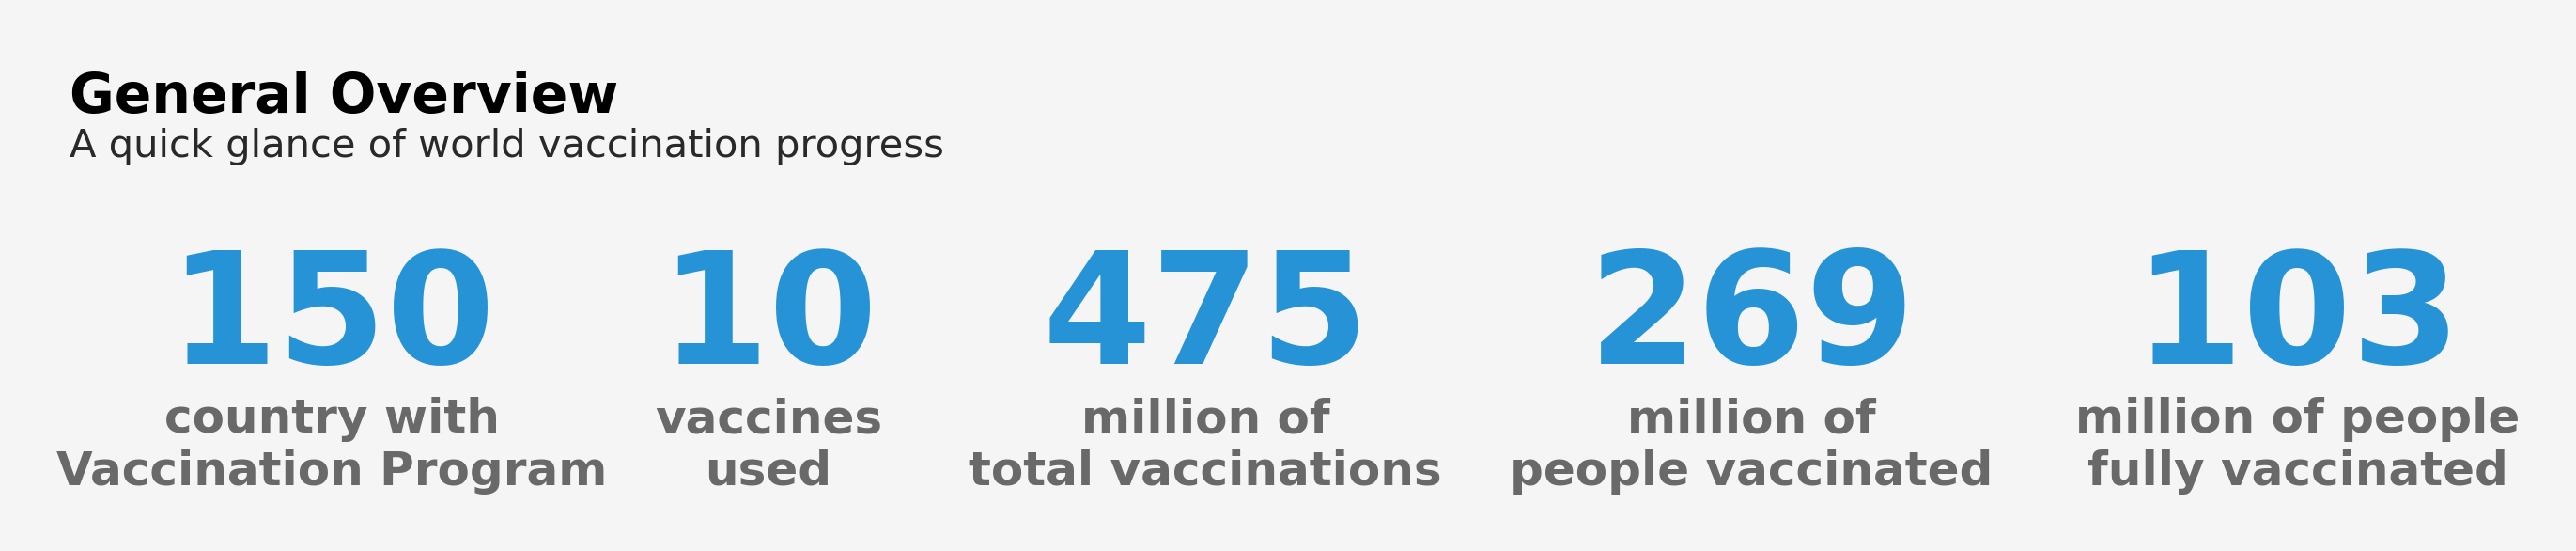

In [3]:
plt.rcParams['figure.dpi'] = 600

fig = plt.figure(figsize=(5, 0.8), facecolor='#f6f5f5')
gs = fig.add_gridspec(1, 1)
gs.update(wspace=0, hspace=0)

background_color = "#f6f5f5"

ax0 = fig.add_subplot(gs[0, 0])
ax0.set_facecolor(background_color)
for s in ["top","right", 'left', 'bottom']:
    ax0.spines[s].set_visible(False)
ax0.set_xticks([])
ax0.set_yticks([])
ax0.grid(which='major', axis='y', zorder=0, color='#EEEEEE')
ax0.text(-0.12, 0.8, 'General Overview', color='black', fontsize=7, ha='left', weight='bold', va='bottom')
ax0.text(-0.12, 0.79, 'A quick glance of world vaccination progress', color='#292929', fontsize=5, ha='left', va='top')
ax0.text(0, 0, '150', color='#2693d7', fontsize=20, ha='center', weight='bold', va='bottom')
ax0.text(0, 0, 'country with\nVaccination Program', color='dimgray', fontsize=6, ha='center', va='top', weight='bold')
ax0.text(0.2, 0, '10', color='#2693d7', fontsize=20, ha='center', weight='bold', va='bottom')
ax0.text(0.2, 0, 'vaccines\nused', color='dimgray', fontsize=6, ha='center', va='top', weight='bold')
ax0.text(0.4, 0, '475', color='#2693d7', fontsize=20, ha='center', weight='bold', va='bottom')
ax0.text(0.4, 0, 'million of\ntotal vaccinations', color='dimgray', fontsize=6, ha='center', va='top', weight='bold')
ax0.text(0.65, 0, '269', color='#2693d7', fontsize=20, ha='center', weight='bold', va='bottom')
ax0.text(0.65, 0, 'million of\npeople vaccinated', color='dimgray', fontsize=6, ha='center', va='top', weight='bold')
ax0.text(0.9, 0, '103', color='#2693d7', fontsize=20, ha='center', weight='bold', va='bottom')
ax0.text(0.9, 0, 'million of people\nfully vaccinated', color='dimgray', fontsize=6, ha='center', va='top', weight='bold')
plt.show()

There are `150` of 195 countries in the world that have immunized their citizens. Total vaccinations have reached `475.3 million` with total of `269 million` people have been vaccinated. At a certain moment, the number of vaccination might be larger than the number of people depending on the immunization scheme (1 or more vaccines - typically 2). Fully vaccinated people have reached `103.5 million`, compared to world population of `7.9 billion`, it is relatively low or only `1.3%` from total world population.

[back to top](#table-of-contents)
<a id="3.2"></a>
## 3.2. Vaccine

In general, there are 2 vaccine schemes:
* **Single Vaccine:** There is only 1 vaccine that is used in a country.
* **Multiple Vaccines:** More than 1 vaccine is used in a country to immunized its citizens.

There are `10` types of vaccine being used. Many countries use multiple vaccines with total of `19` vaccines combination. 

<a id="3.2.1"></a>
### 3.2.1 Single Vaccine
Some countries decided to use only a single vaccine to vaccinated their citizens. Below are number of countries that used a specific type of vaccine: 

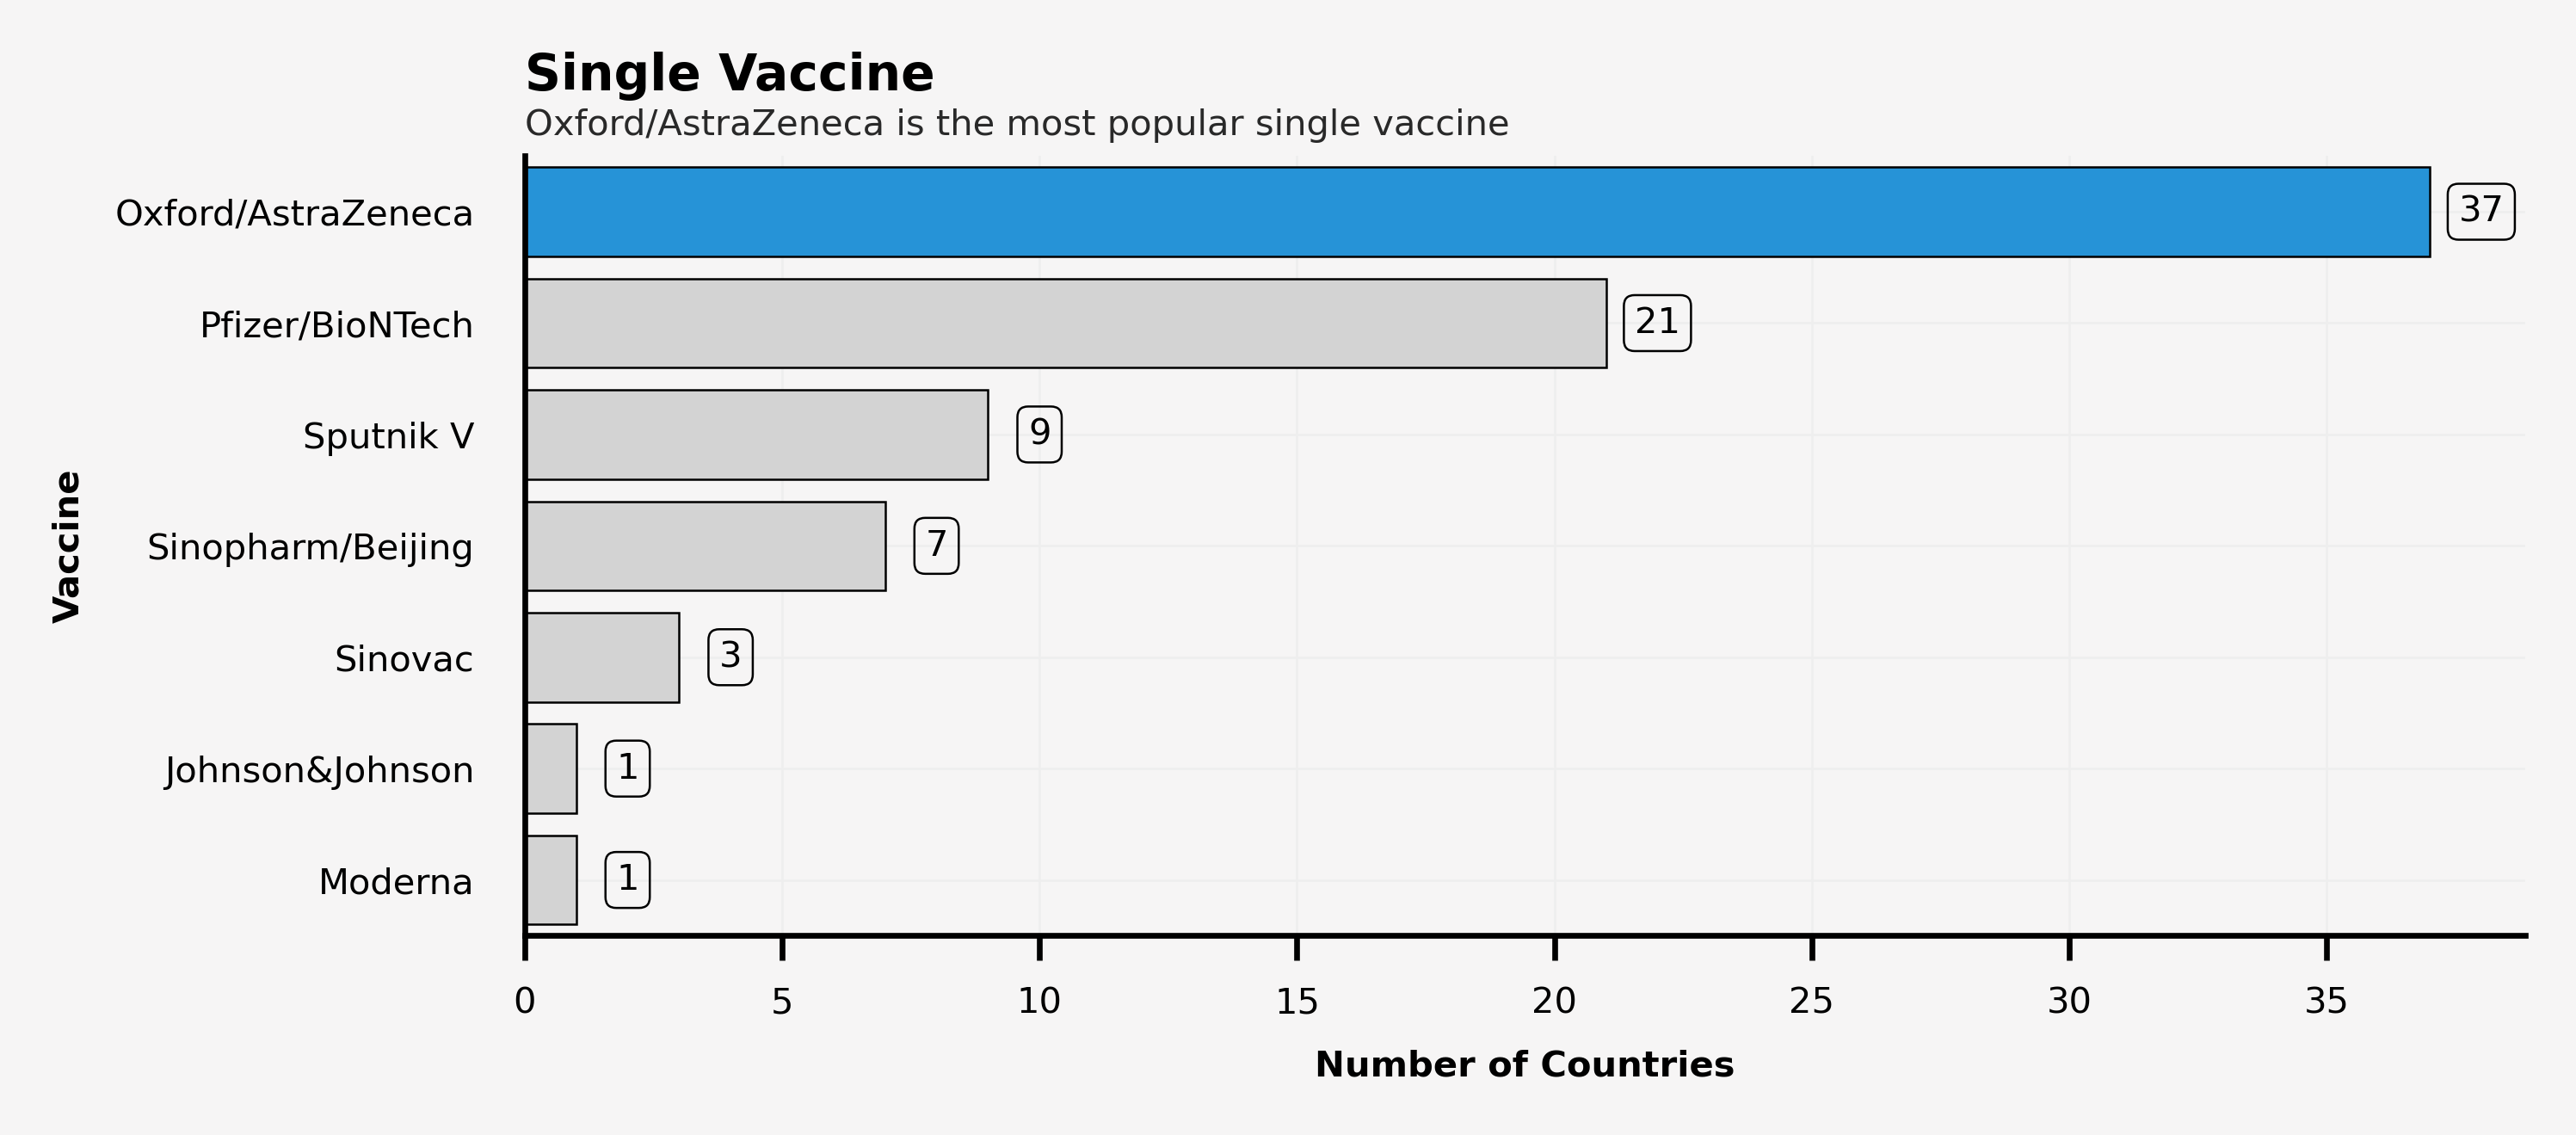

In [4]:
single_vaccine = data_ld['vaccines'].value_counts()
single_vaccine = single_vaccine[['Oxford/AstraZeneca', 
                                 'Pfizer/BioNTech', 
                                 'Sputnik V', 
                                 'Sinopharm/Beijing',
                                 'Sinovac', 
                                 'Johnson&Johnson', 
                                 'Moderna']]

background_color = "#f6f5f5"
color_map = ["lightgray" for _ in range(7)]
color_map[0] = "#2693d7"
sns.set_palette(sns.color_palette(color_map))

plt.rcParams['figure.dpi'] = 600
fig = plt.figure(figsize=(5, 2), facecolor='#f6f5f5')
gs = fig.add_gridspec(1, 1)
gs.update(wspace=0, hspace=0)
ax0 = fig.add_subplot(gs[0, 0])
ax0.set_facecolor(background_color)
for s in ["right", "top"]:
    ax0.spines[s].set_visible(False)
ax0.tick_params(axis = "y", which = "both", left = False)

ax0.text(0, -1, 'Single Vaccine', color='black', fontsize=7, ha='left', va='bottom', weight='bold')
ax0.text(0, -0.93, 'Oxford/AstraZeneca is the most popular single vaccine', color='#292929', fontsize=5, ha='left', va='top')
ax0_sns = sns.barplot(ax=ax0, y=single_vaccine.index, x=single_vaccine, zorder=2, orient='h', 
                      linewidth=0.3, edgecolor='black', saturation=1)
ax0_sns.set_xlabel("Number of Countries",fontsize=5, weight='bold')
ax0_sns.set_ylabel("Vaccine",fontsize=5, weight='bold')
ax0.grid(which='major', axis='x', zorder=0, color='#EEEEEE', lw=0.3)
ax0.grid(which='major', axis='y', zorder=0, color='#EEEEEE', lw=0.3)
ax0_sns.tick_params(labelsize=5)

for p in ax0.patches:
    value = f'{p.get_width():,.0f}'
    x = p.get_x() + p.get_width() + 1
    y = p.get_y() + p.get_height() / 2 
    ax0.text(x, y, value, ha='center', va='center', fontsize=5, 
            bbox=dict(facecolor='none', edgecolor='black', boxstyle='round', linewidth=0.3))

plt.show()

Top 3 single vaccine that is used in a country:
* `Oxford/AstraZeneca` vaccine is the most popular vaccine among single and multiple vaccines that are used by a country, single use has been adapted by `37` countries. Despite its popularity, in March 2021 some of European countries including Germany, France, Spain, Italy Ireland and Sweden suspense the use of `Oxford-AstraZeneca` vaccine over blood clot concerns. 
* `Pfizer/BioNTech` is the second most popular single vaccine that is used by `21` countries. `Pfizer/BioNTech` is an mRNA based COVID-19 vaccine. The German company BioNTech is the developer of the vaccine, and partnered for support with clinical trials, logistics and manufacturing with American company Pfizer as well as Chinese company Fosun for China.
* In third place, there is `Sputnik V` vaccine that is used by `9` countries. `Sputnik V` is an adenovirus viral vector vaccine and is developed by the Gamaleya Research Institute of Epidemiology and Microbiology.

<a id="3.2.2"></a>
### 3.2.2 Multiple Vaccines

Countries that use multiple vaccines have the advantage to continue vaccinated their citizens using if there is a problem with one of the vaccine. As this happen with `Oxford/AstraZeneca` that has been suspended by some countries due to blood clot concerns. Below are number of countries that used a specific combination of multiple vaccines: 

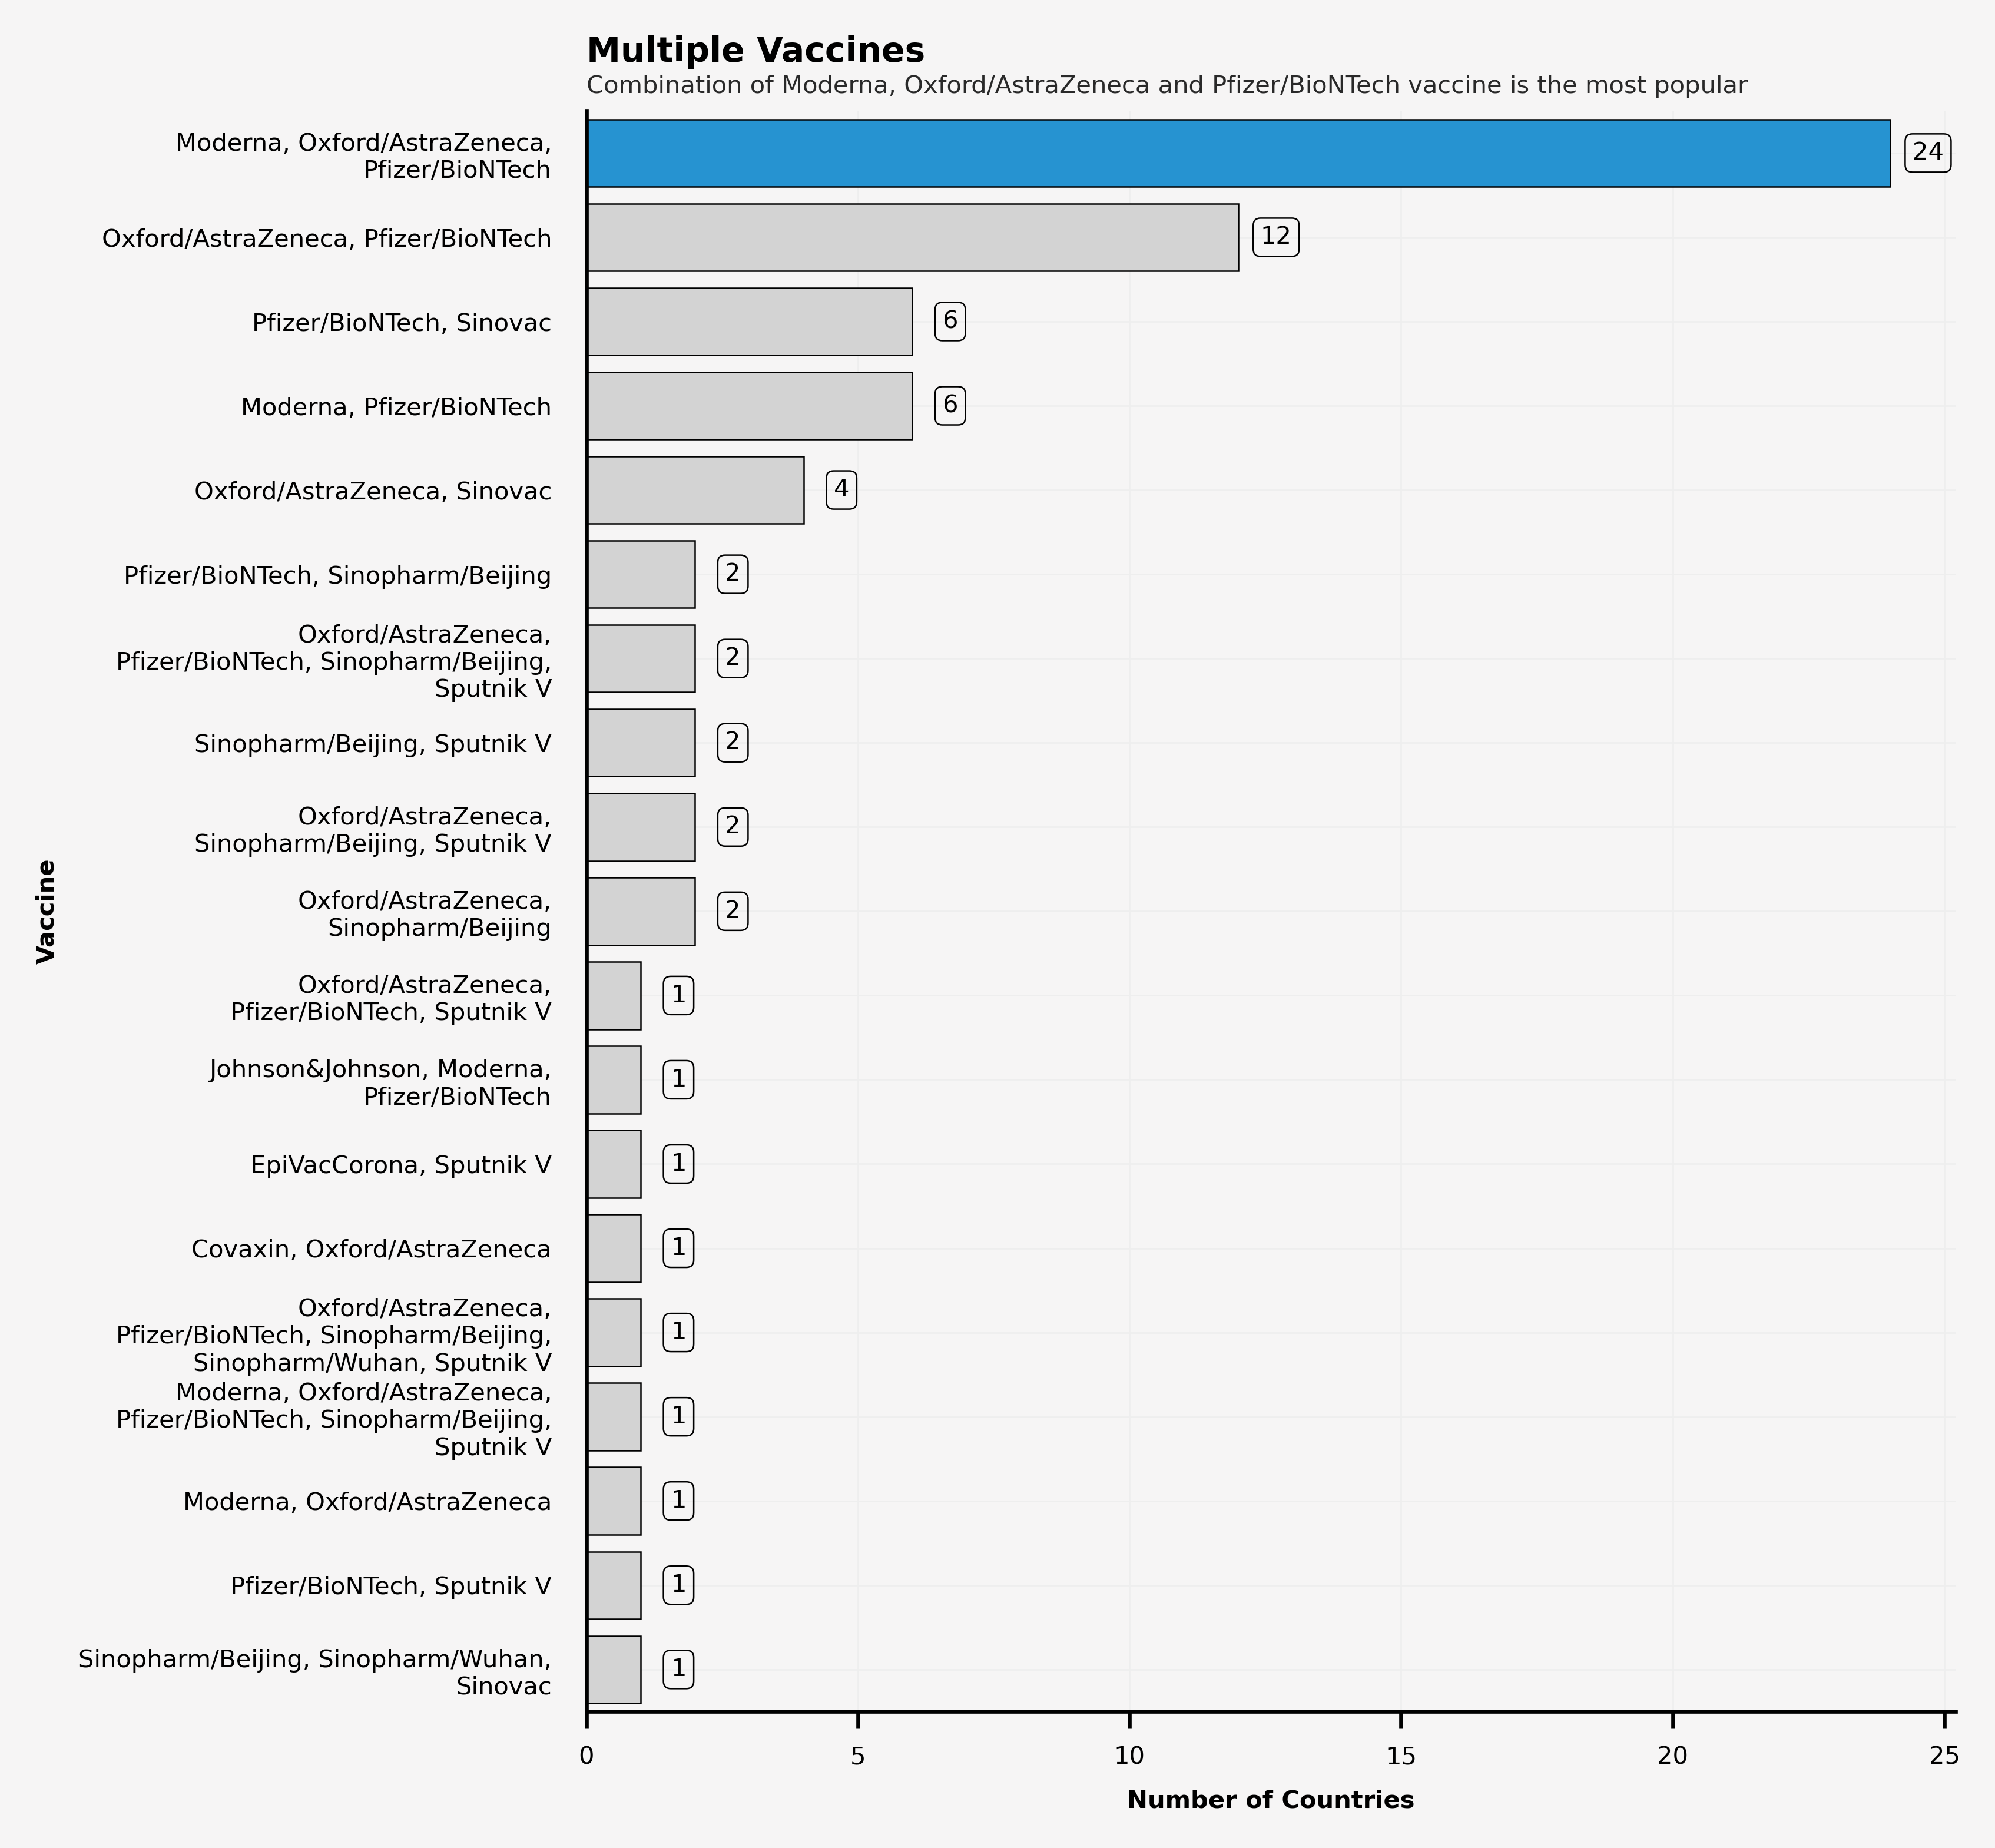

In [5]:
comb_vaccine = data_ld['vaccines'].value_counts()
comb_vaccine = comb_vaccine.drop(['Oxford/AstraZeneca', 
                                 'Pfizer/BioNTech', 
                                 'Sputnik V', 
                                 'Sinopharm/Beijing',
                                 'Sinovac', 
                                 'Johnson&Johnson', 
                                 'Moderna'])

background_color = "#f6f5f5"
color_map = ["lightgray" for _ in range(19)]
color_map[0] = "#2693d1"
sns.set_palette(sns.color_palette(color_map))

plt.rcParams['figure.dpi'] = 600
fig = plt.figure(figsize=(5, 6), facecolor='#f6f5f5')
gs = fig.add_gridspec(1, 1)
gs.update(wspace=0, hspace=0)
ax0 = fig.add_subplot(gs[0, 0])
ax0.set_facecolor(background_color)
for s in ["right", "top"]:
    ax0.spines[s].set_visible(False)
ax0.tick_params(axis = "y", which = "both", left = False)

ax0.text(0, -1, 'Multiple Vaccines', color='black', fontsize=7, ha='left', va='bottom', weight='bold')
ax0.text(0, -0.93, 'Combination of Moderna, Oxford/AstraZeneca and Pfizer/BioNTech vaccine is the most popular', 
         color='#292929', fontsize=5, ha='left', va='top')
ax0_sns = sns.barplot(ax=ax0, y=comb_vaccine.index, x=comb_vaccine, zorder=2, orient='h', 
                      linewidth=0.3, edgecolor='black', saturation=1)
ax0_sns.set_xlabel("Number of Countries",fontsize=5, weight='bold')
ax0_sns.set_ylabel("Vaccine",fontsize=5, weight='bold')
ax0.grid(which='major', axis='x', zorder=0, color='#EEEEEE', lw=0.3)
ax0.grid(which='major', axis='y', zorder=0, color='#EEEEEE', lw=0.3)
ax0_sns.tick_params(labelsize=5)
ax0.set_yticklabels([textwrap.fill(e, 35) for e in comb_vaccine.index])

for p in ax0.patches:
    value = f'{p.get_width():,.0f}'
    x = p.get_x() + p.get_width() + 0.7
    y = p.get_y() + p.get_height() / 2 
    ax0.text(x, y, value, ha='center', va='center', fontsize=5, 
            bbox=dict(facecolor='none', edgecolor='black', boxstyle='round', linewidth=0.3))

plt.show()

Top 3 combination of multiple vaccines in a country are:
* `Moderna, Oxford/AstraZeneca, Pfizer/BioNTech` is the most popular mutliple vaccines combination with total of `24` countries using this combination. Most of countries that use this vaccine combaination are European countries (i.e. Germany, France, Spain, Italy, etc).
* `Oxford/AstraZeneca, Pfizer/BioNTech` in the second place with `12` countries use this combination. This combination is used in a more diverse continents, countries included in this group are Australia, England, Saudi Arabia, South Korea and etc.
* `Pfizer/BioNTech, Sinovac` is the third vaccine combination that used by `6` countries. They are Chile, Columbia, Hong Kong, Malaysia, Northen Cyprus and Uruguay

[back to top](#table-of-contents)
<a id="3.3"></a>
## 3.3. Daily Vaccinations

Daily vaccinations will be viewed based on:
* Daily trends
* Daily distribution

<a id="3.3.1"></a>
### 3.3.1 Trend
Daily vaccination and cumulative daily vaccination have a strong uptrend as can be seen in the charts below:

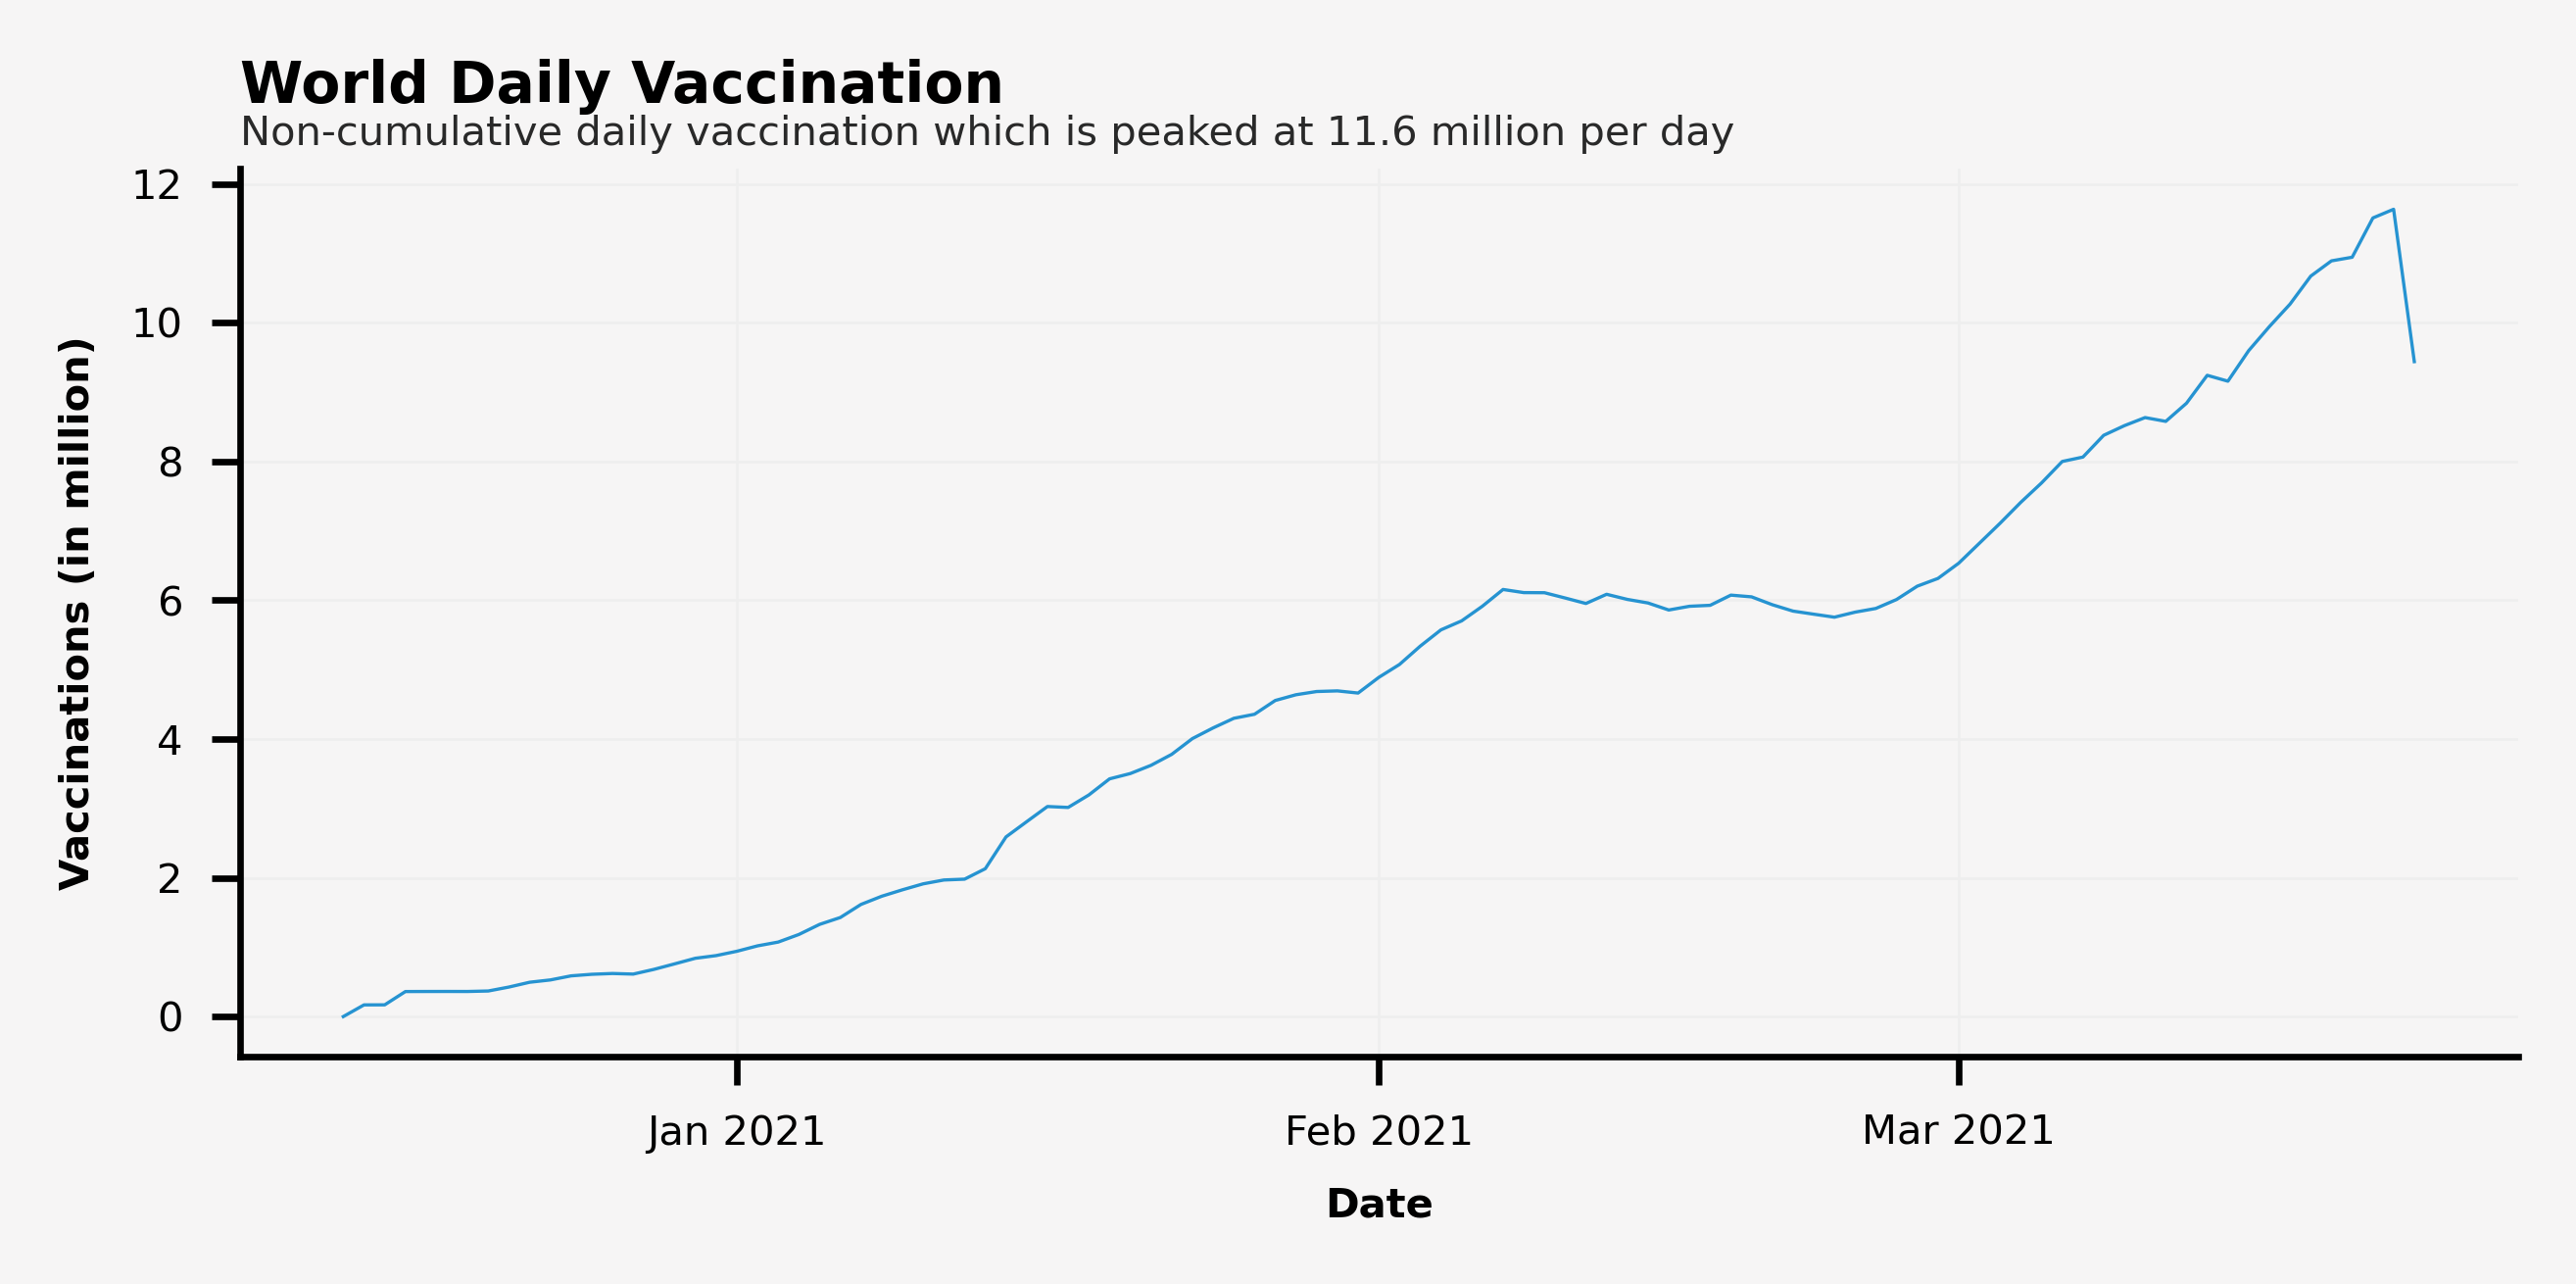

In [6]:
daily_vaccination = data.groupby('date')['daily_vaccinations'].sum()
daily_vaccination = daily_vaccination / 1000000

background_color = "#f6f5f5"

years = mdates.YearLocator()
months = mdates.MonthLocator()
years_fmt = mdates.DateFormatter('%b %Y')

plt.rcParams['figure.dpi'] = 600
fig = plt.figure(figsize=(5, 2), facecolor='#f6f5f5')
gs = fig.add_gridspec(1, 1)
gs.update(wspace=0, hspace=0)
ax0 = fig.add_subplot(gs[0, 0])
ax0.set_facecolor(background_color)
for s in ["right", "top"]:
    ax0.spines[s].set_visible(False)
    
# format the ticks
ax0.xaxis.set_major_locator(months)
ax0.xaxis.set_major_formatter(years_fmt)

ax0.text(pd.Timestamp('2020-12-8'), 13, 'World Daily Vaccination', color='black', fontsize=7, ha='left', va='bottom', weight='bold')
ax0.text(pd.Timestamp('2020-12-8'), 13, 'Non-cumulative daily vaccination which is peaked at 11.6 million per day', 
         color='#292929', fontsize=5, ha='left', va='top')
ax0_sns = sns.lineplot(ax=ax0, x=daily_vaccination.index, y=daily_vaccination, zorder=2, linewidth=0.4)
ax0_sns.set_xlabel("Date",fontsize=5, weight='bold')
ax0_sns.set_ylabel("Vaccinations (in million)",fontsize=5, weight='bold')
ax0.grid(which='major', axis='x', zorder=0, color='#EEEEEE', lw=0.3)
ax0.grid(which='major', axis='y', zorder=0, color='#EEEEEE', lw=0.3)
ax0_sns.tick_params(labelsize=5)

plt.show()

Daily vaccinations trend overview:
* Daily vaccination has increased significantly starting from `0.16 million` per day in December 14, 2020 to `9.4 million` vaccination in March 23, 2021. Daily vaccination peaked in March 22, 2021 with `11.6 million` vaccination per day with an average of `4.7 million` per day
* There was a significant daily drop of `2.2 million` in the last entry date, this may due to un-updated data.
* Daily vaccination had somehow stuck at `4-6 million` per day in February 2021 then a rapid increased start to happen in March 2021, reaching the peaked at 11.6 million per day.

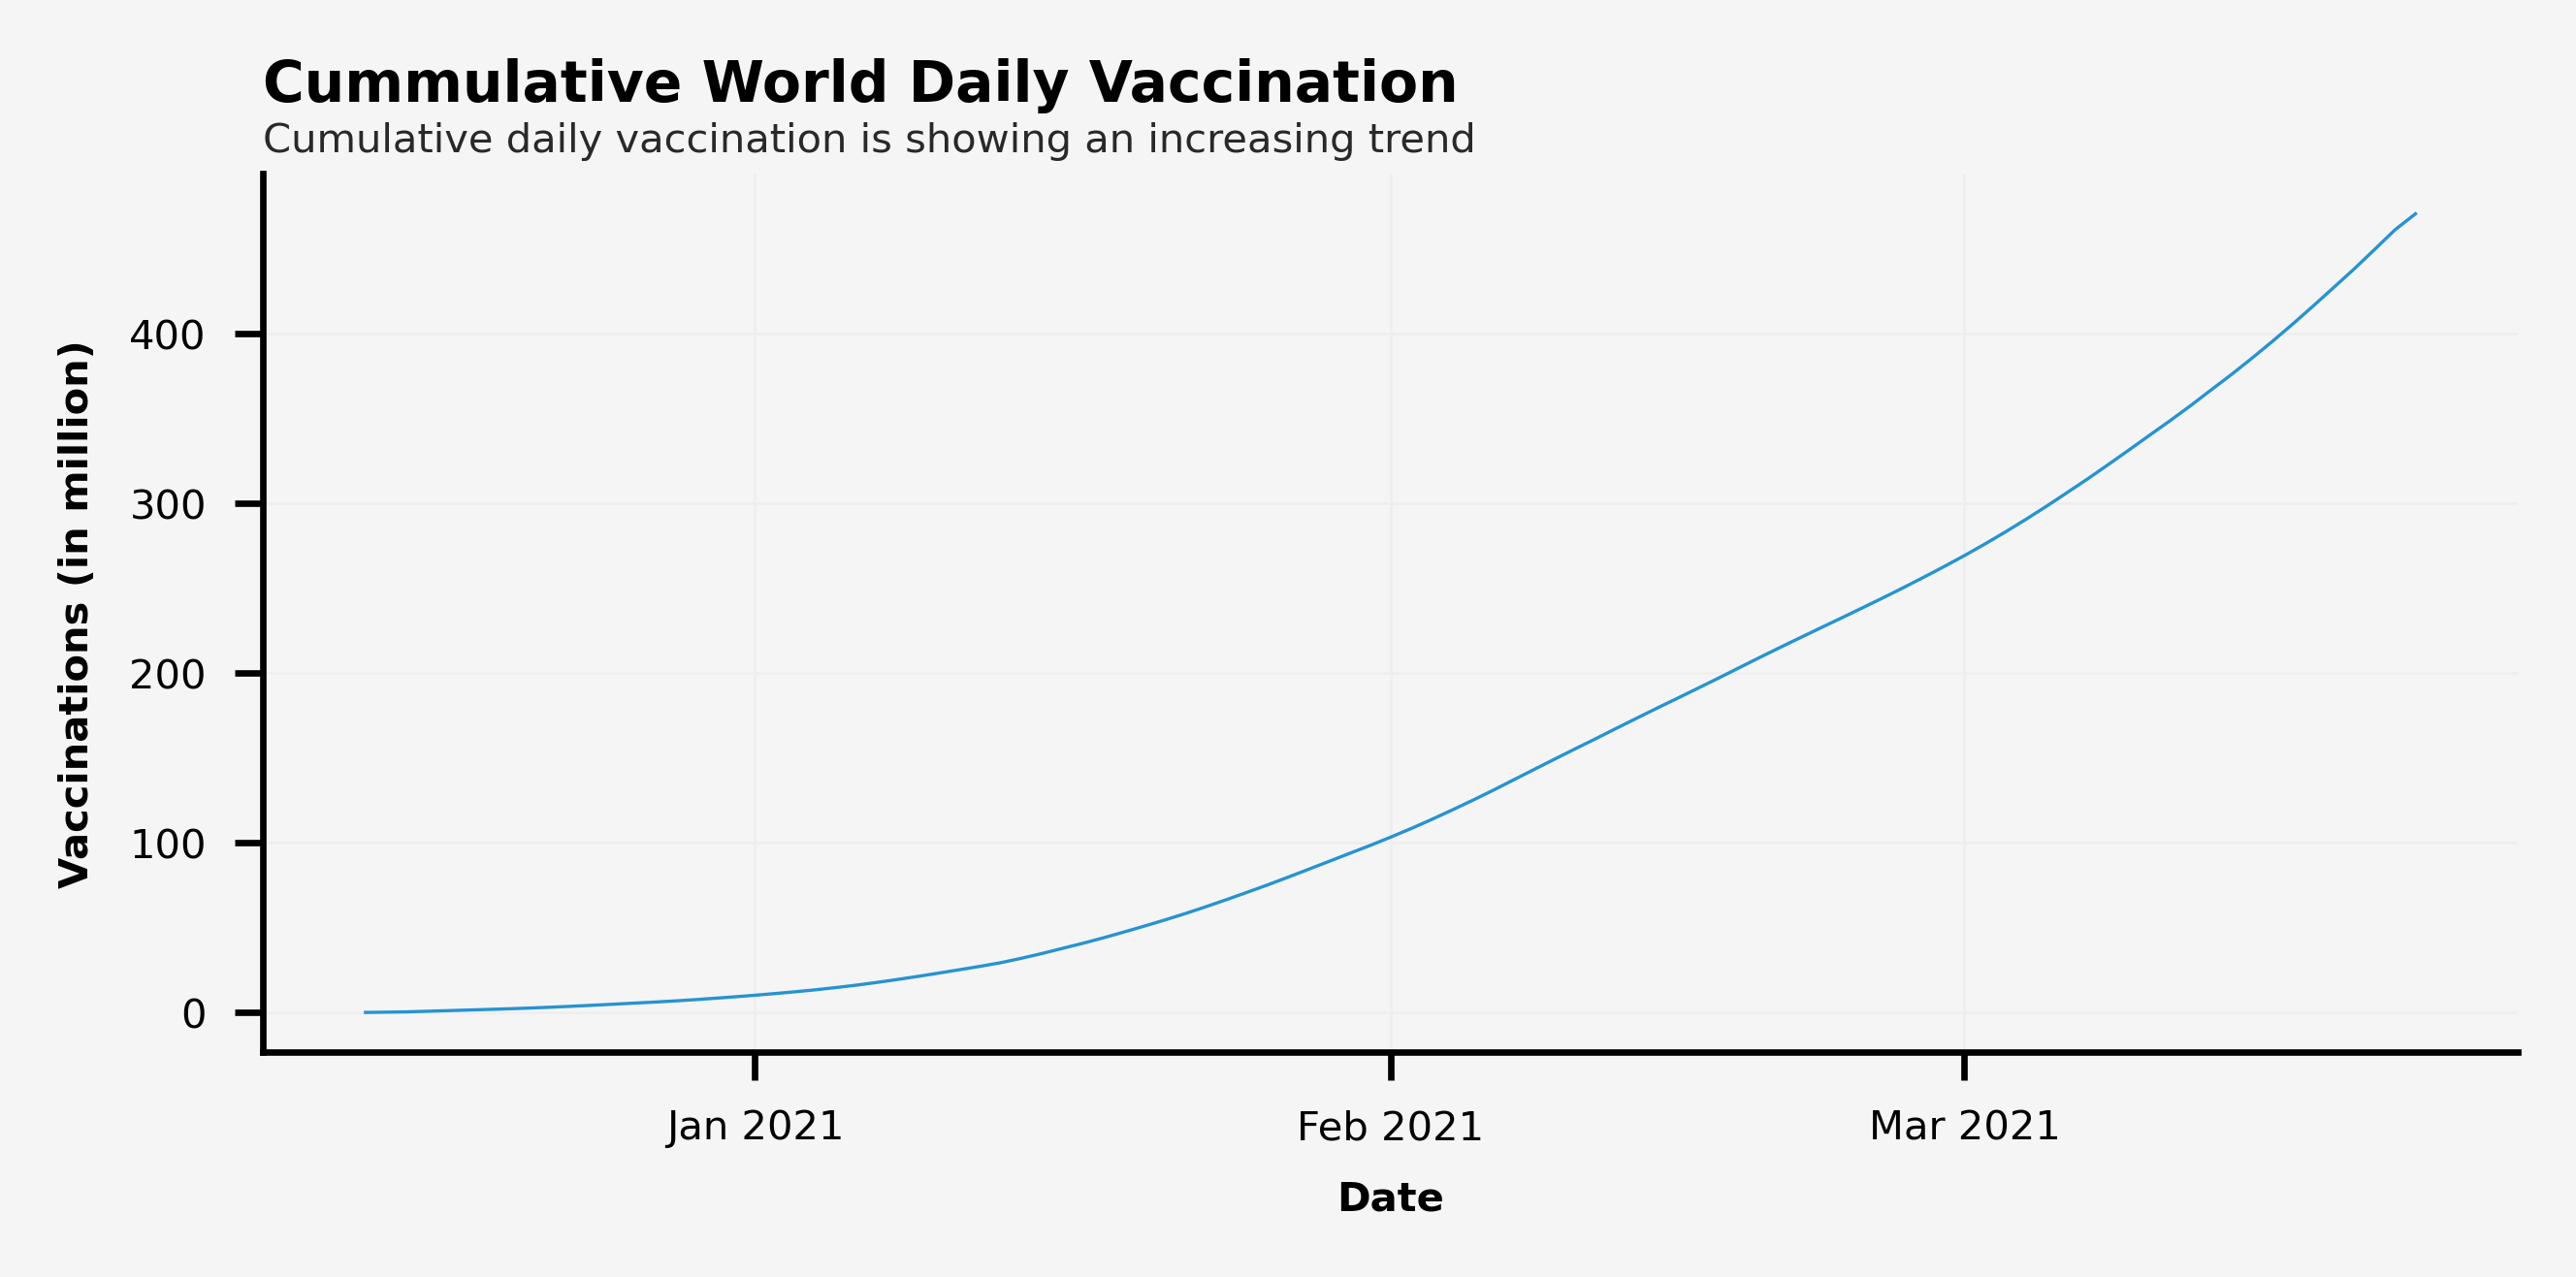

In [7]:
daily_vaccination = data.groupby('date')['daily_vaccinations'].sum()
daily_vaccination = daily_vaccination / 1000000

background_color = "#f6f5f5"

years = mdates.YearLocator()
months = mdates.MonthLocator()
years_fmt = mdates.DateFormatter('%b %Y')

plt.rcParams['figure.dpi'] = 600
fig = plt.figure(figsize=(5, 2), facecolor='#f6f5f5')
gs = fig.add_gridspec(1, 1)
gs.update(wspace=0, hspace=0)
ax0 = fig.add_subplot(gs[0, 0])
ax0.set_facecolor(background_color)
for s in ["right", "top"]:
    ax0.spines[s].set_visible(False)
    
ax0.xaxis.set_major_locator(months)
ax0.xaxis.set_major_formatter(years_fmt)

ax0.text(pd.Timestamp('2020-12-8'), 530, 'Cummulative World Daily Vaccination', color='black', fontsize=7, ha='left', va='bottom', weight='bold')
ax0.text(pd.Timestamp('2020-12-8'), 525, 'Cumulative daily vaccination is showing an increasing trend', 
         color='#292929', fontsize=5, ha='left', va='top')
ax0_sns = sns.lineplot(ax=ax0, x=daily_vaccination.index, y=daily_vaccination.cumsum(), zorder=2, color='#2693d1', linewidth=0.4)
ax0_sns.set_xlabel("Date",fontsize=5, weight='bold')
ax0_sns.set_ylabel("Vaccinations (in million)",fontsize=5, weight='bold')
ax0.grid(which='major', axis='x', zorder=0, color='#EEEEEE', lw=0.3)
ax0.grid(which='major', axis='y', zorder=0, color='#EEEEEE', lw=0.3)
ax0_sns.tick_params(labelsize=5)
plt.show()

Cumulative daily vaccinations trend overview:
* Daily cumulative trend is still showing an increasing trend inline with day by day increased in daily vaccination. 
* Assuming daily vaccination can be maintain at `12 million` per day, `2 vaccines` are needed for fully vaccinated and there is a `365 days/year`; roughly speaking, it will need around `3 years`to immunized the next `7.6 billion` people.

**Calculation Notes:** 

Please be mind that the calculation only serve for rough calculation and not for high accuracy:
* People still need to be vaccine: 7,854 million - 269 million = 7,585 million.
* People that need the second vaccine: 269 million -103 million = 166 million which will need 13.8 days to be fully vaccinated as there is 12 million vaccination per day.
* Effectively there will be 6 million poeple to be fully vaccinated in per day (12 million / 2 vaccine).
* Years needed to vaccinated a 7.6 billion people: 7,585 million / 6 million will result to 1,264.2 days which is 3.4 years + 13.8 days of poeple that need the second vaccine.

<a id="3.3.2"></a>
### 3.3.2 Distribution
Lower daily vaccinations are still dominating while a higher daily vaccinations show an increasing trend while there is no specific weekday that show a higher daily vaccination as shown on below charts:

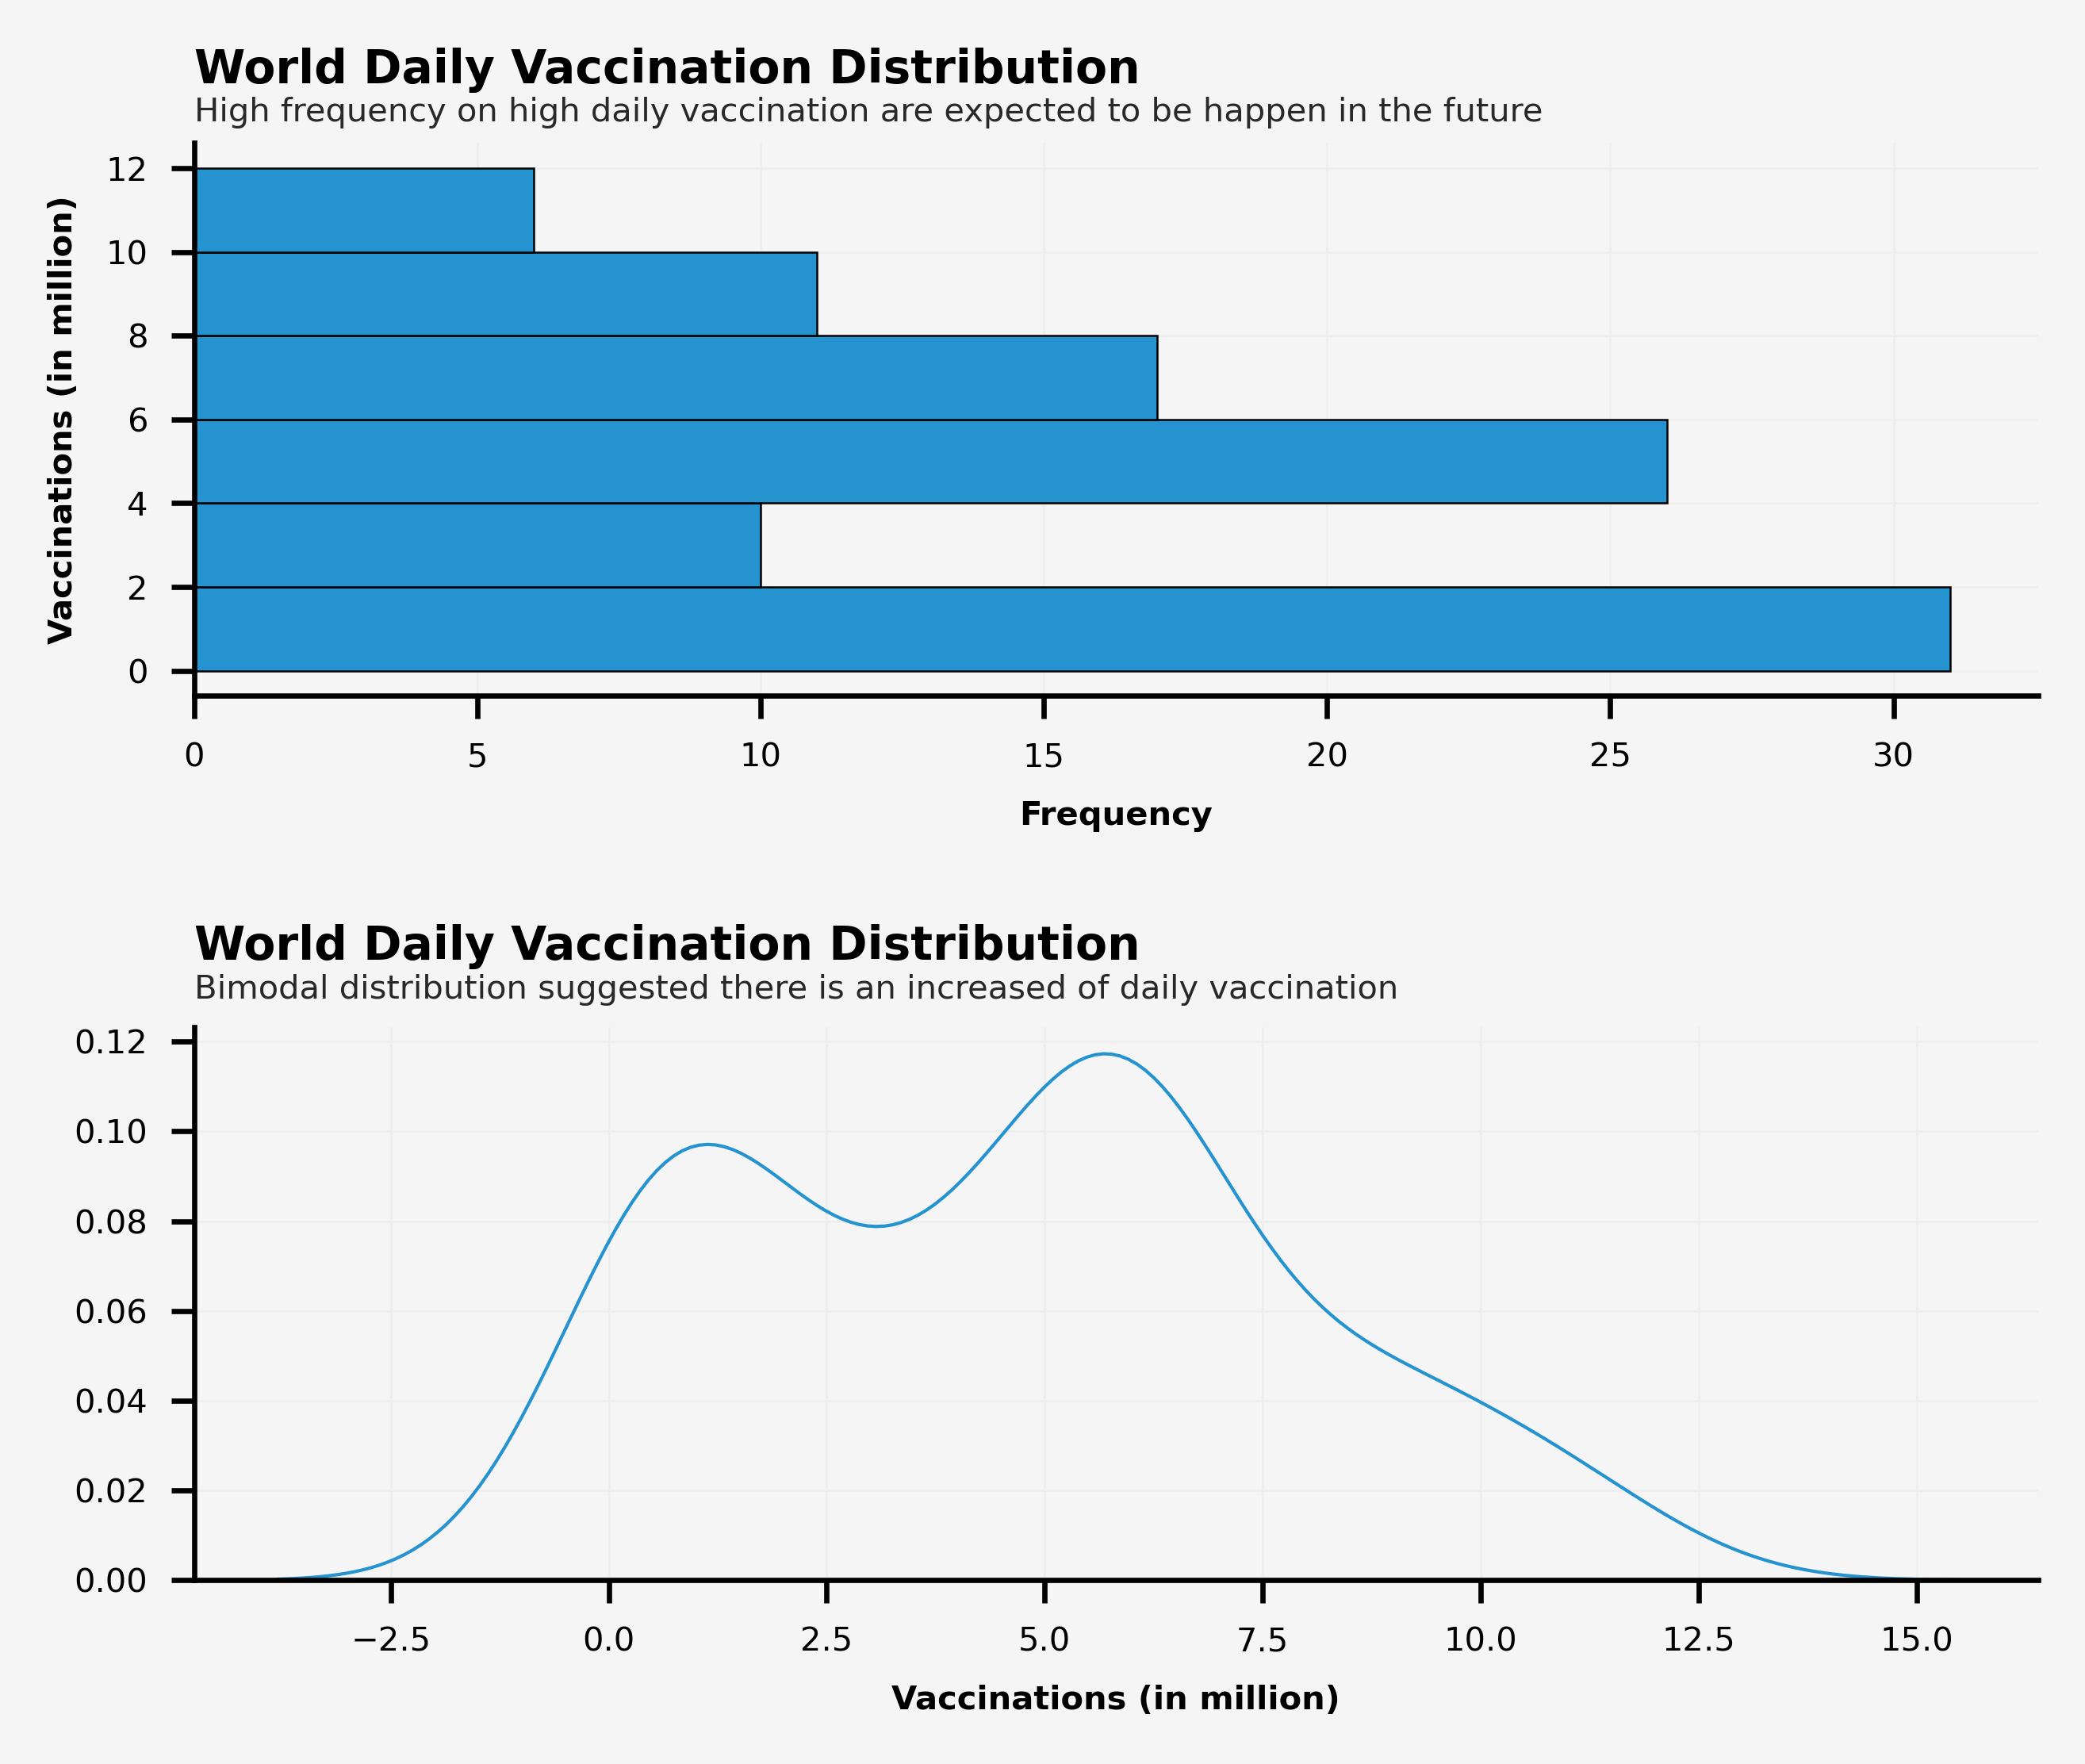

In [8]:
daily_vaccination = data.groupby('date')['daily_vaccinations'].sum()
daily_vaccination = daily_vaccination / 1000000

background_color = "#f6f5f5"

plt.rcParams['figure.dpi'] = 600
fig = plt.figure(figsize=(5, 4), facecolor='#f6f5f5')
gs = fig.add_gridspec(2, 1)
gs.update(wspace=0, hspace=0.6)
ax0 = fig.add_subplot(gs[0, 0])
ax0.set_facecolor(background_color)
for s in ["right", "top"]:
    ax0.spines[s].set_visible(False)

ax0.text(0, 13.8, 'World Daily Vaccination Distribution', color='black', fontsize=7, ha='left', va='bottom', weight='bold')
ax0.text(0, 13.7, 'High frequency on high daily vaccination are expected to be happen in the future', color='#292929', fontsize=5, ha='left', va='top')
ax0_sns = sns.histplot(ax=ax0, y=daily_vaccination, zorder=2, binwidth=2, linewidth=0.3, edgecolor='black', alpha=1)
ax0_sns.set_xlabel("Frequency",fontsize=5, weight='bold')
ax0_sns.set_ylabel("Vaccinations (in million)",fontsize=5, weight='bold')
ax0.grid(which='major', axis='x', zorder=0, color='#EEEEEE', lw=0.3)
ax0.grid(which='major', axis='y', zorder=0, color='#EEEEEE', lw=0.3)
ax0_sns.tick_params(labelsize=5)

ax0 = fig.add_subplot(gs[1, 0])
ax0.set_facecolor(background_color)
for s in ["right", "top"]:
    ax0.spines[s].set_visible(False)

ax0_sns = sns.kdeplot(ax=ax0, x=daily_vaccination, zorder=2, linewidth=0.5, alpha=1)
x0, x1 = ax0.get_xlim()
y0, y1 = ax0.get_ylim() 
ax0.text(x0, y1+0.013, 'World Daily Vaccination Distribution', color='black', fontsize=7, ha='left', va='bottom', weight='bold')
ax0.text(x0, y1+0.012, 'Bimodal distribution suggested there is an increased of daily vaccination', color='#292929', fontsize=5, ha='left', va='top')

ax0_sns.set_xlabel("Vaccinations (in million)",fontsize=5, weight='bold')
ax0_sns.set_ylabel("",fontsize=5, weight='bold')
ax0.grid(which='major', axis='x', zorder=0, color='#EEEEEE', lw=0.3)
ax0.grid(which='major', axis='y', zorder=0, color='#EEEEEE', lw=0.3)
ax0_sns.tick_params(labelsize=5)

plt.show()

Daily vaccinations distributions overview:
* In the early stage of vaccination, daily vaccination reached a range of `0-2 million` vaccination per day and due to a rapid increased in daily vaccination, resulted to a lowest frequency on range of `2-4 million`.
* Stuck daily vaccination at `4-6 million` per day in February 2021 is reflected by high frequency in that range.
* Two scenarios are expected to be happen in the future as daily vaccination in the growing phase:
    * Higher frequency for daily vaccination in range `10-12 million` if daily vaccination can not pass this range.
    * Higher range with higher range if daily vaccination passed `10-12 million` range.

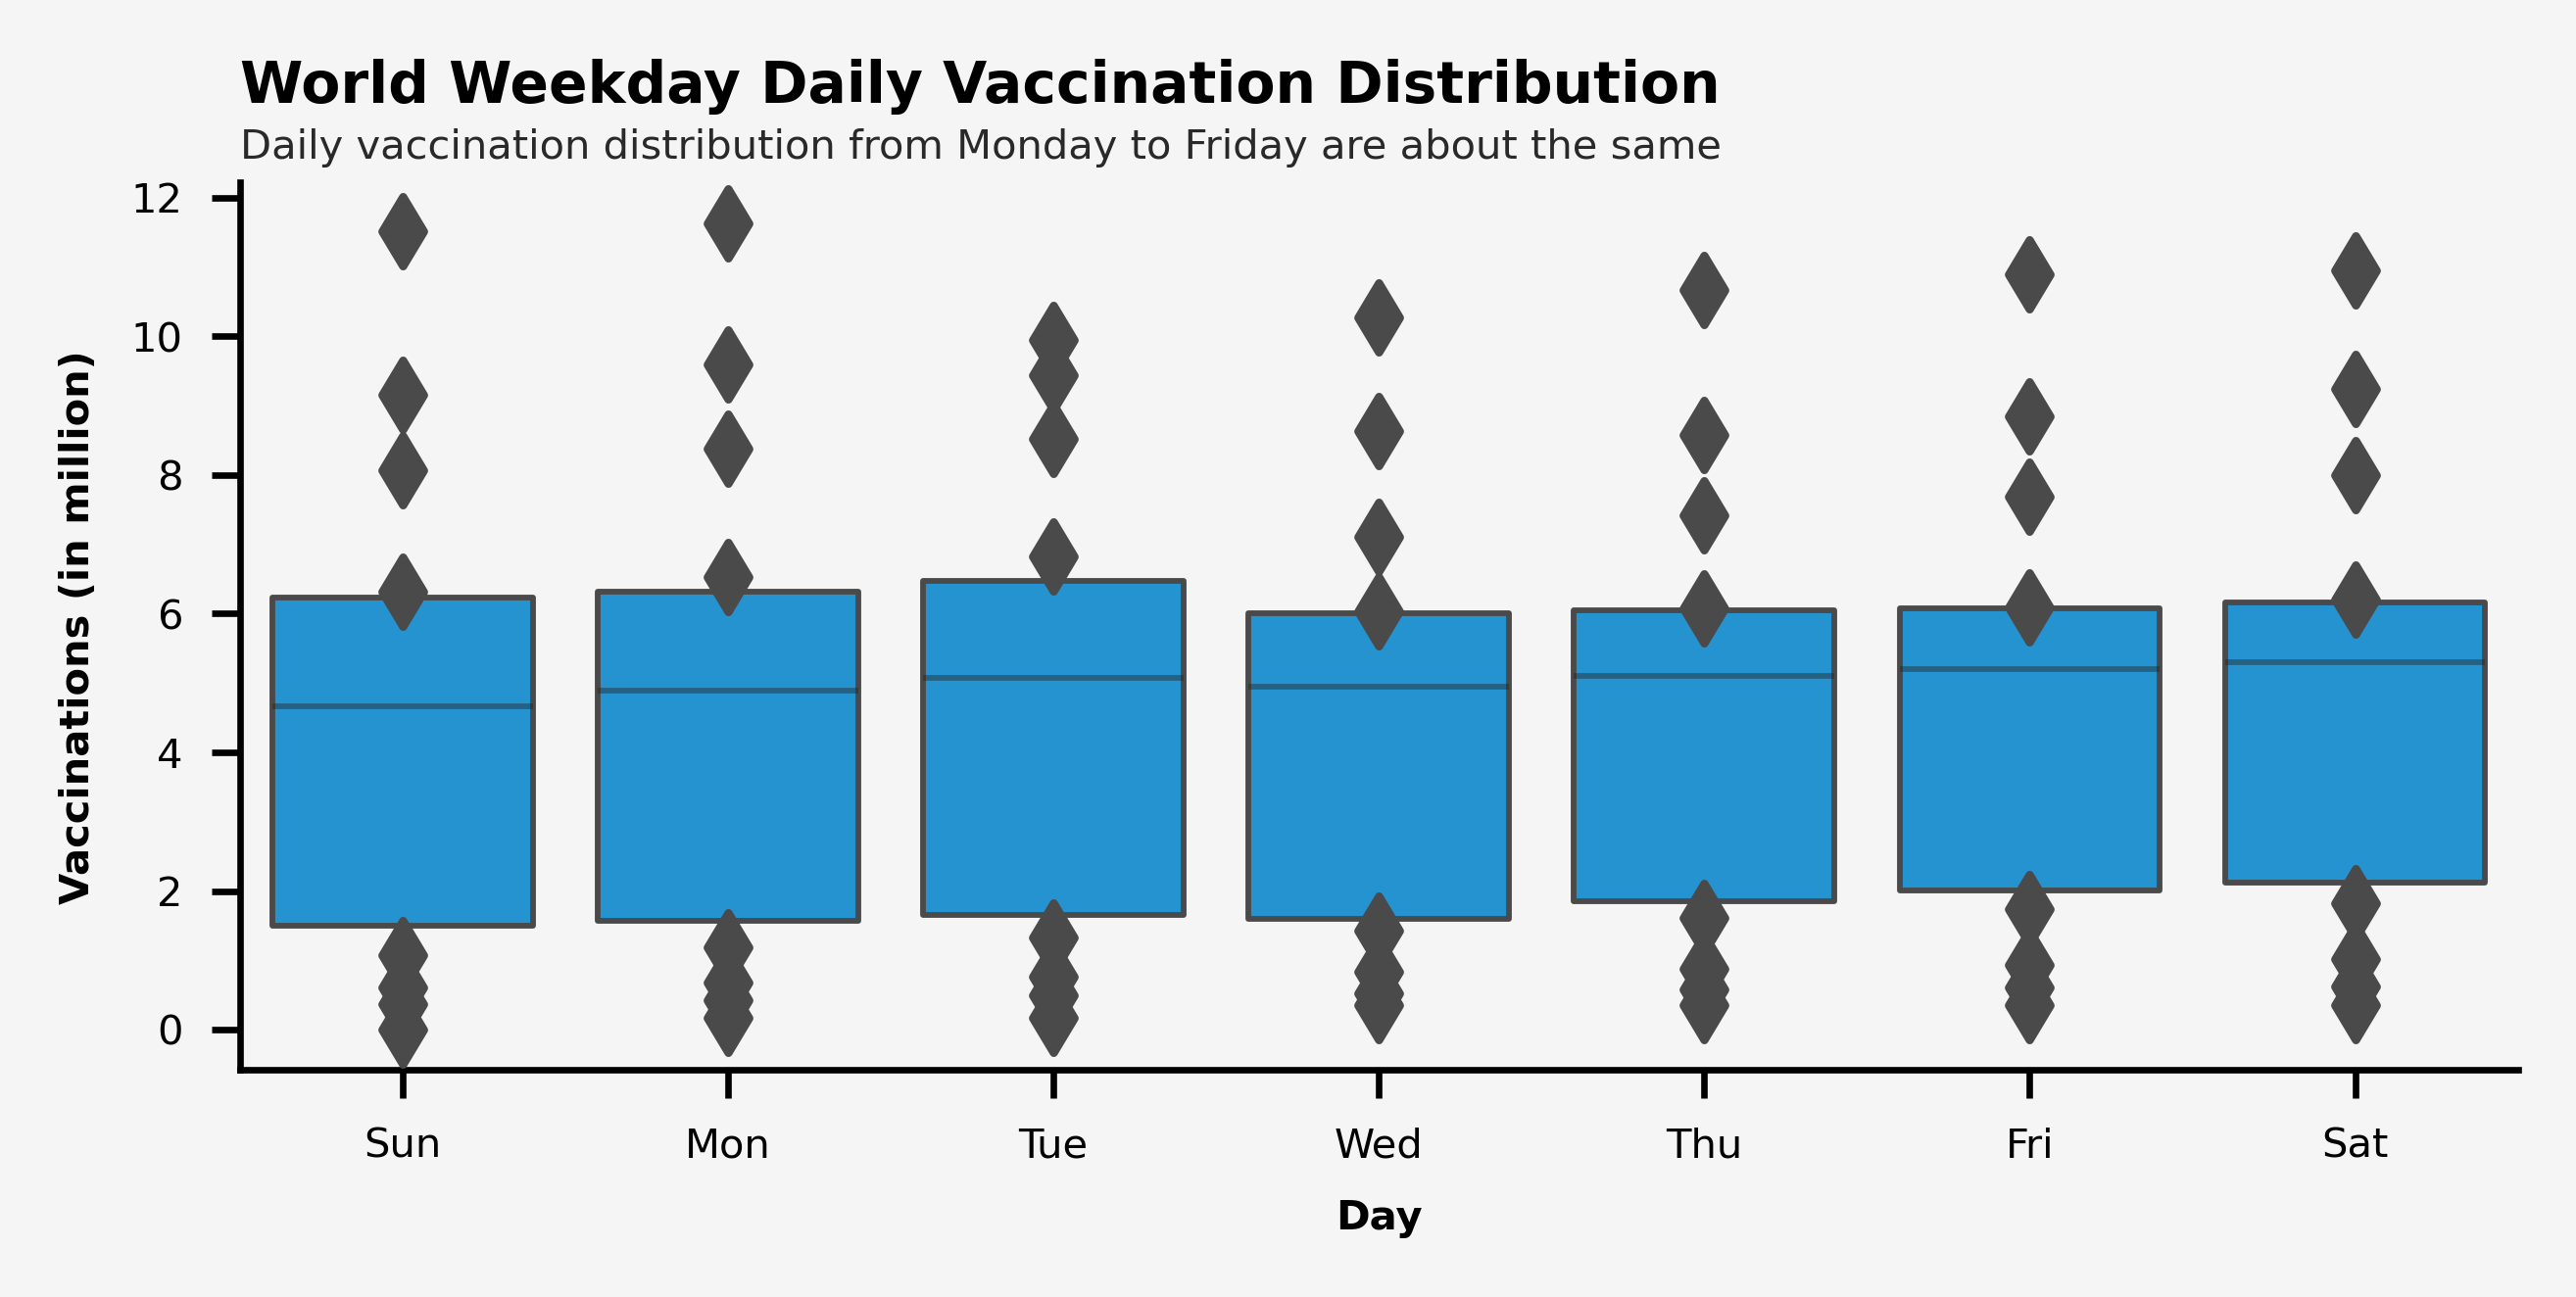

In [9]:
daily_vaccination = data.groupby('date')['daily_vaccinations'].sum()
daily_vaccination = daily_vaccination / 1000000
daily_vaccination = pd.DataFrame(daily_vaccination).reset_index(drop=False)
daily_vaccination['weekday'] = daily_vaccination['date'].dt.dayofweek
weekday = {0: 'Mon', 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri', 5:'Sat', 6:'Sun'}
daily_vaccination['weekday'] = daily_vaccination['weekday'].map(weekday)

background_color = "#f6f5f5"

color_map = ["#2693d1" for _ in range(7)]
sns.set_palette(sns.color_palette(color_map))

plt.rcParams['figure.dpi'] = 600
fig = plt.figure(figsize=(5, 2), facecolor='#f6f5f5')
gs = fig.add_gridspec(1, 1)
gs.update(wspace=0, hspace=0)
ax0 = fig.add_subplot(gs[0, 0])
ax0.set_facecolor(background_color)
for s in ["right", "top"]:
    ax0.spines[s].set_visible(False)

ax0.text(-0.5, 13.2, 'World Weekday Daily Vaccination Distribution', color='black', fontsize=7, ha='left', va='bottom', weight='bold')
ax0.text(-0.5, 13, 'Daily vaccination distribution from Monday to Friday are about the same', 
         color='#292929', fontsize=5, ha='left', va='top')
ax0_sns = sns.boxenplot(ax=ax0, x=daily_vaccination['weekday'], y=daily_vaccination['daily_vaccinations'], 
                        zorder=3, linewidth=0.7, saturation=1)
ax0_sns.set_xlabel("Day",fontsize=5, weight='bold')
ax0_sns.set_ylabel("Vaccinations (in million)",fontsize=5, weight='bold')
ax0_sns.tick_params(labelsize=5)

plt.show()

Weekday daily vaccinations distributions overview:

* Daily vaccinations distribution from `Sunday` to `Saturday` are about the same, there is no a specific day that has a significant higher daily vaccinations compared to the other days.
* `Sunday` and `Monday` have the most high outlier compared to others day while `Tuesday` has the lower high outlier.

[back to top](#table-of-contents)
<a id="3.4"></a>
## 3.4. Vaccination Progress

Even though the `absolute` amount prove to be important in calculating `total vaccination`, `people vaccinated` and `people fully vaccinated` in a country but `percentage of total population` figure is a more relevant context as it incorporated total population in a country.

Higher `absolute` amount doesn't mean a better progress as it will be harder for a big country that has population to fulfill the immunization program in terms of fund and vaccine distributions.

<a id="3.4.1"></a>
## 3.4.1 Total Vaccination

Some countries have reached above 100% `total vacination per total population` as total vaccination is the absolute number of total immunization and depending on the immunization scheme (1 or more vaccines - typically 2), the number of vaccination might be larger than the number of people.

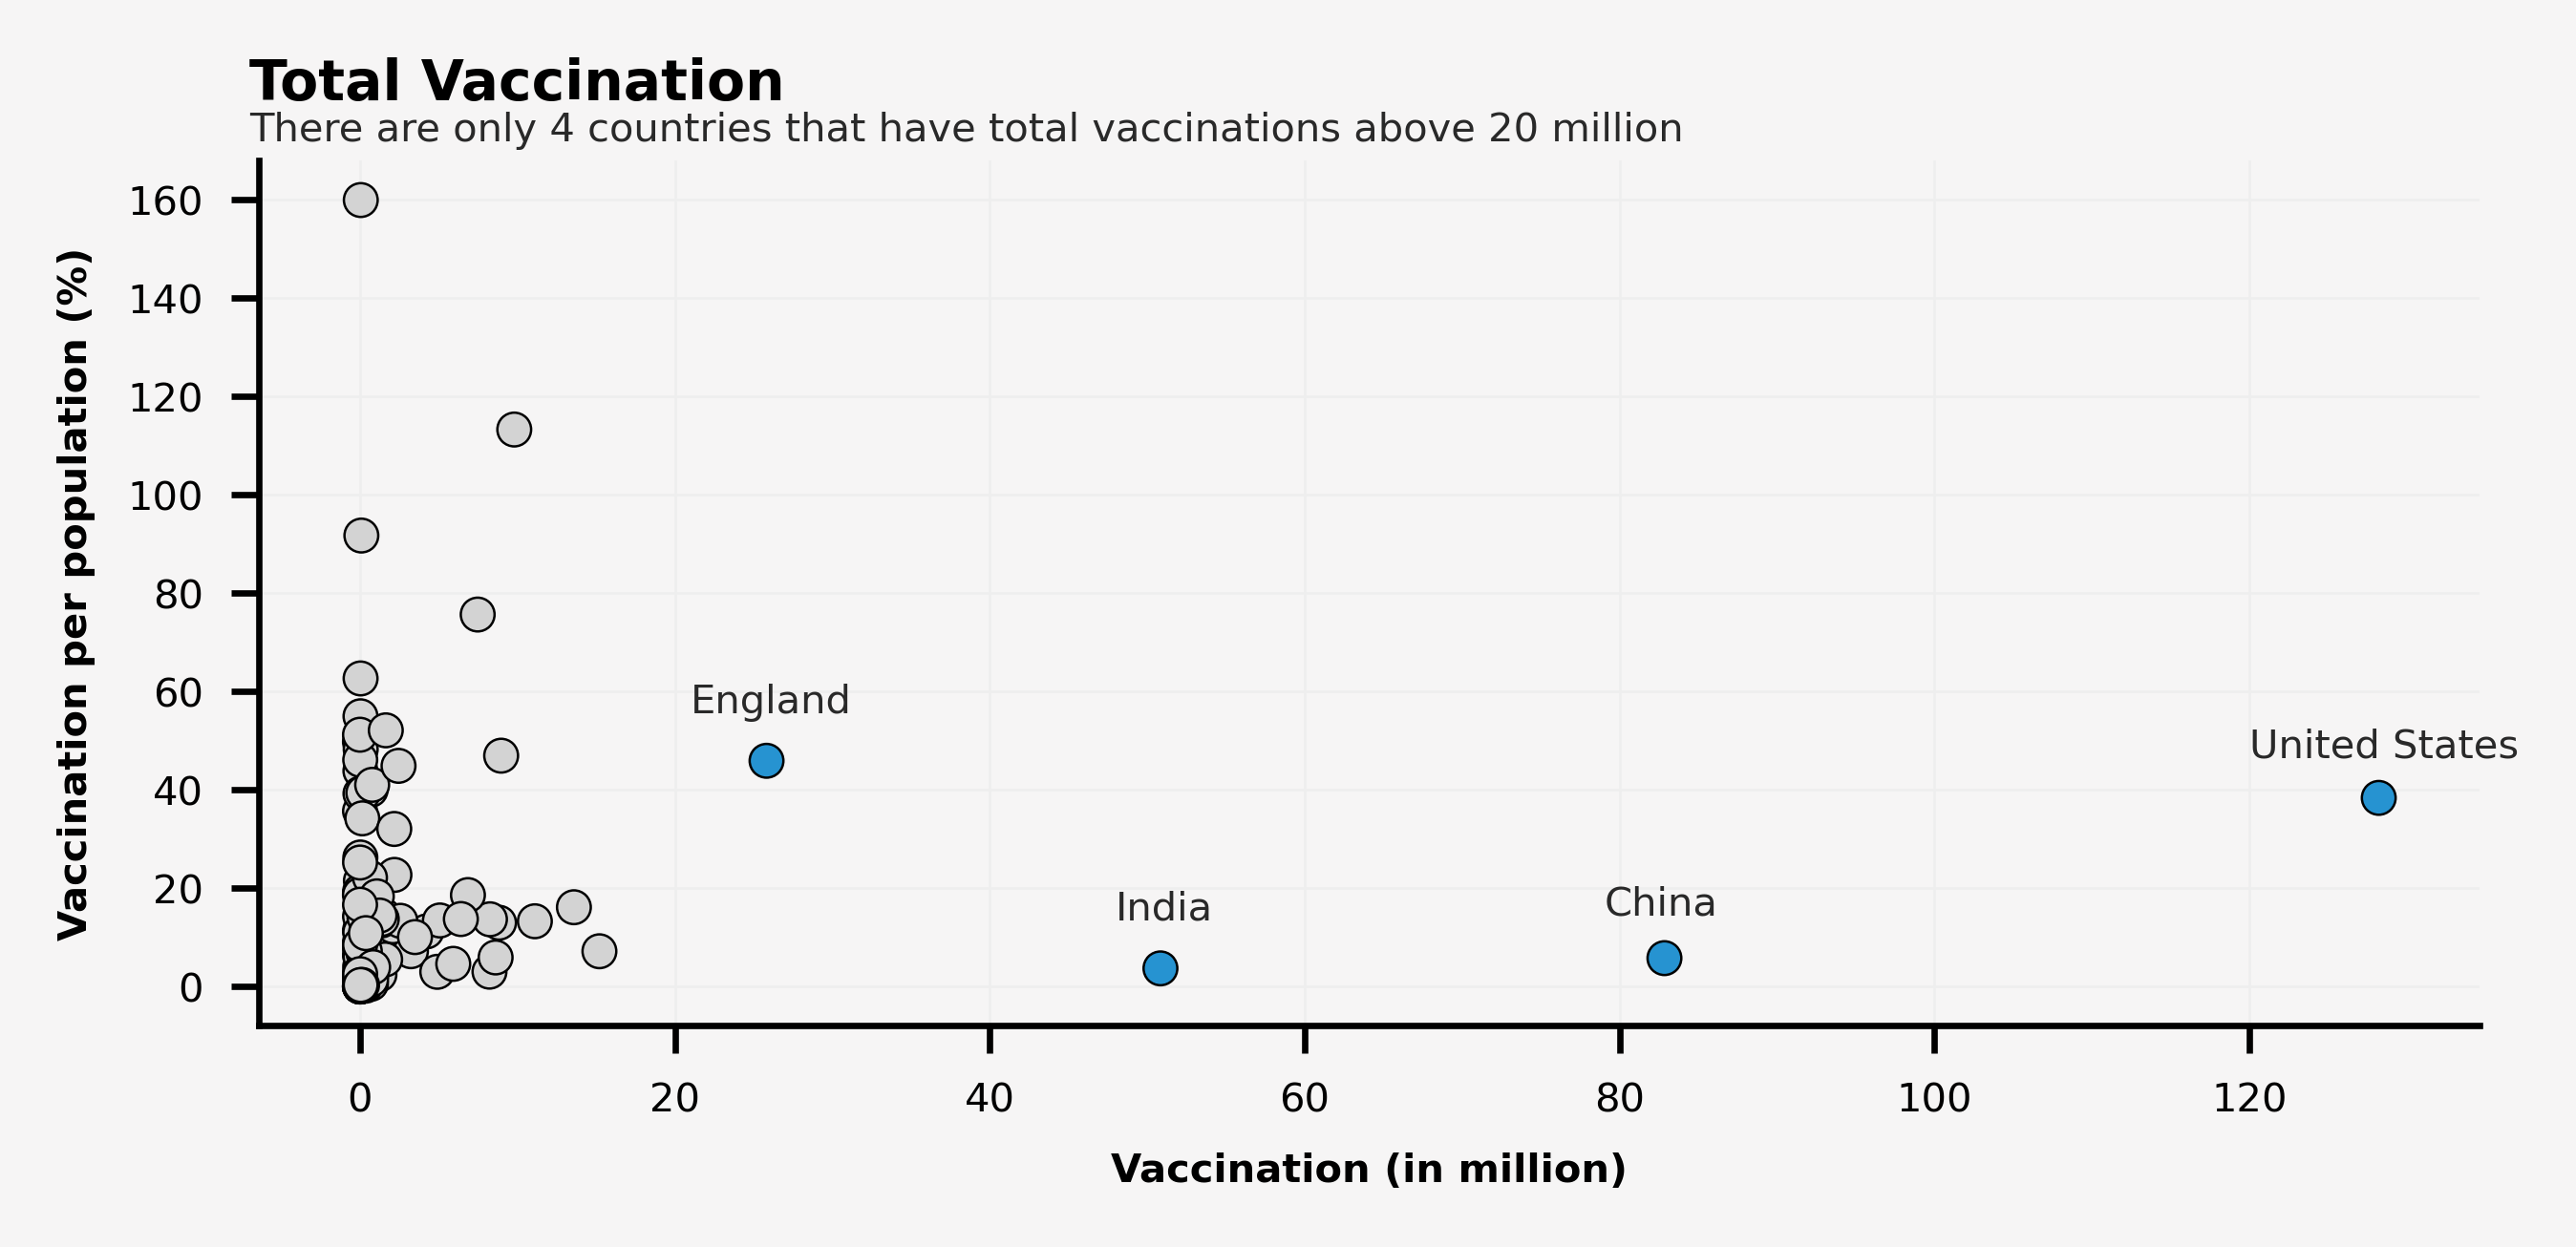

In [10]:
background_color = "#f6f5f5"

color_map = ["lightgray" for _ in range(2)]
color_map[1] = "#2693d1"
sns.set_palette(sns.color_palette(color_map))
value_list = ['United States', 'England', 'India', 'China']
boolean_series = data_ld.country.isin(value_list)
data_ld['color'] = boolean_series

plt.rcParams['figure.dpi'] = 600
fig = plt.figure(figsize=(5, 2), facecolor='#f6f5f5')
gs = fig.add_gridspec(1, 1)
gs.update(wspace=0, hspace=0)
ax0 = fig.add_subplot(gs[0, 0])
ax0.set_facecolor(background_color)
for s in ["right", "top"]:
    ax0.spines[s].set_visible(False)

ax0.text(-7, 178, 'Total Vaccination', color='black', fontsize=7, ha='left', va='bottom', weight='bold')
ax0.text(-7, 178, 'There are only 4 countries that have total vaccinations above 20 million', color='#292929', fontsize=5, ha='left', va='top')
ax0.text(120, 45, 'United States', color='#292929', fontsize=5, ha='left', va='bottom')
ax0.text(79, 13, 'China', color='#292929', fontsize=5, ha='left', va='bottom')
ax0.text(48, 12, 'India', color='#292929', fontsize=5, ha='left', va='bottom')
ax0.text(21, 54, 'England', color='#292929', fontsize=5, ha='left', va='bottom')
ax0_sns = sns.scatterplot(ax=ax0, y=data_ld['total_vaccinations_per_hundred'], x=data_ld['total_vaccinations']/1000000, 
                          zorder=2, linewidth=0.3, edgecolor='black',  hue=data_ld['color'], legend=False, size=1)
ax0_sns.set_xlabel("Vaccination (in million)",fontsize=5, weight='bold')
ax0_sns.set_ylabel("Vaccination per population (%)",fontsize=5, weight='bold')
ax0.grid(which='major', axis='x', zorder=0, color='#EEEEEE', lw=0.3)
ax0.grid(which='major', axis='y', zorder=0, color='#EEEEEE', lw=0.3)
ax0_sns.tick_params(labelsize=5)

plt.show()

There are 4 countries that have total vaccination above 20 million, they are `United States`, `China`, `India` and `England`. Even though their total vaccination have reached above 20 million, there is no country reached 50% mark; vaccinated people and fully vaccinated people will even be lower. 

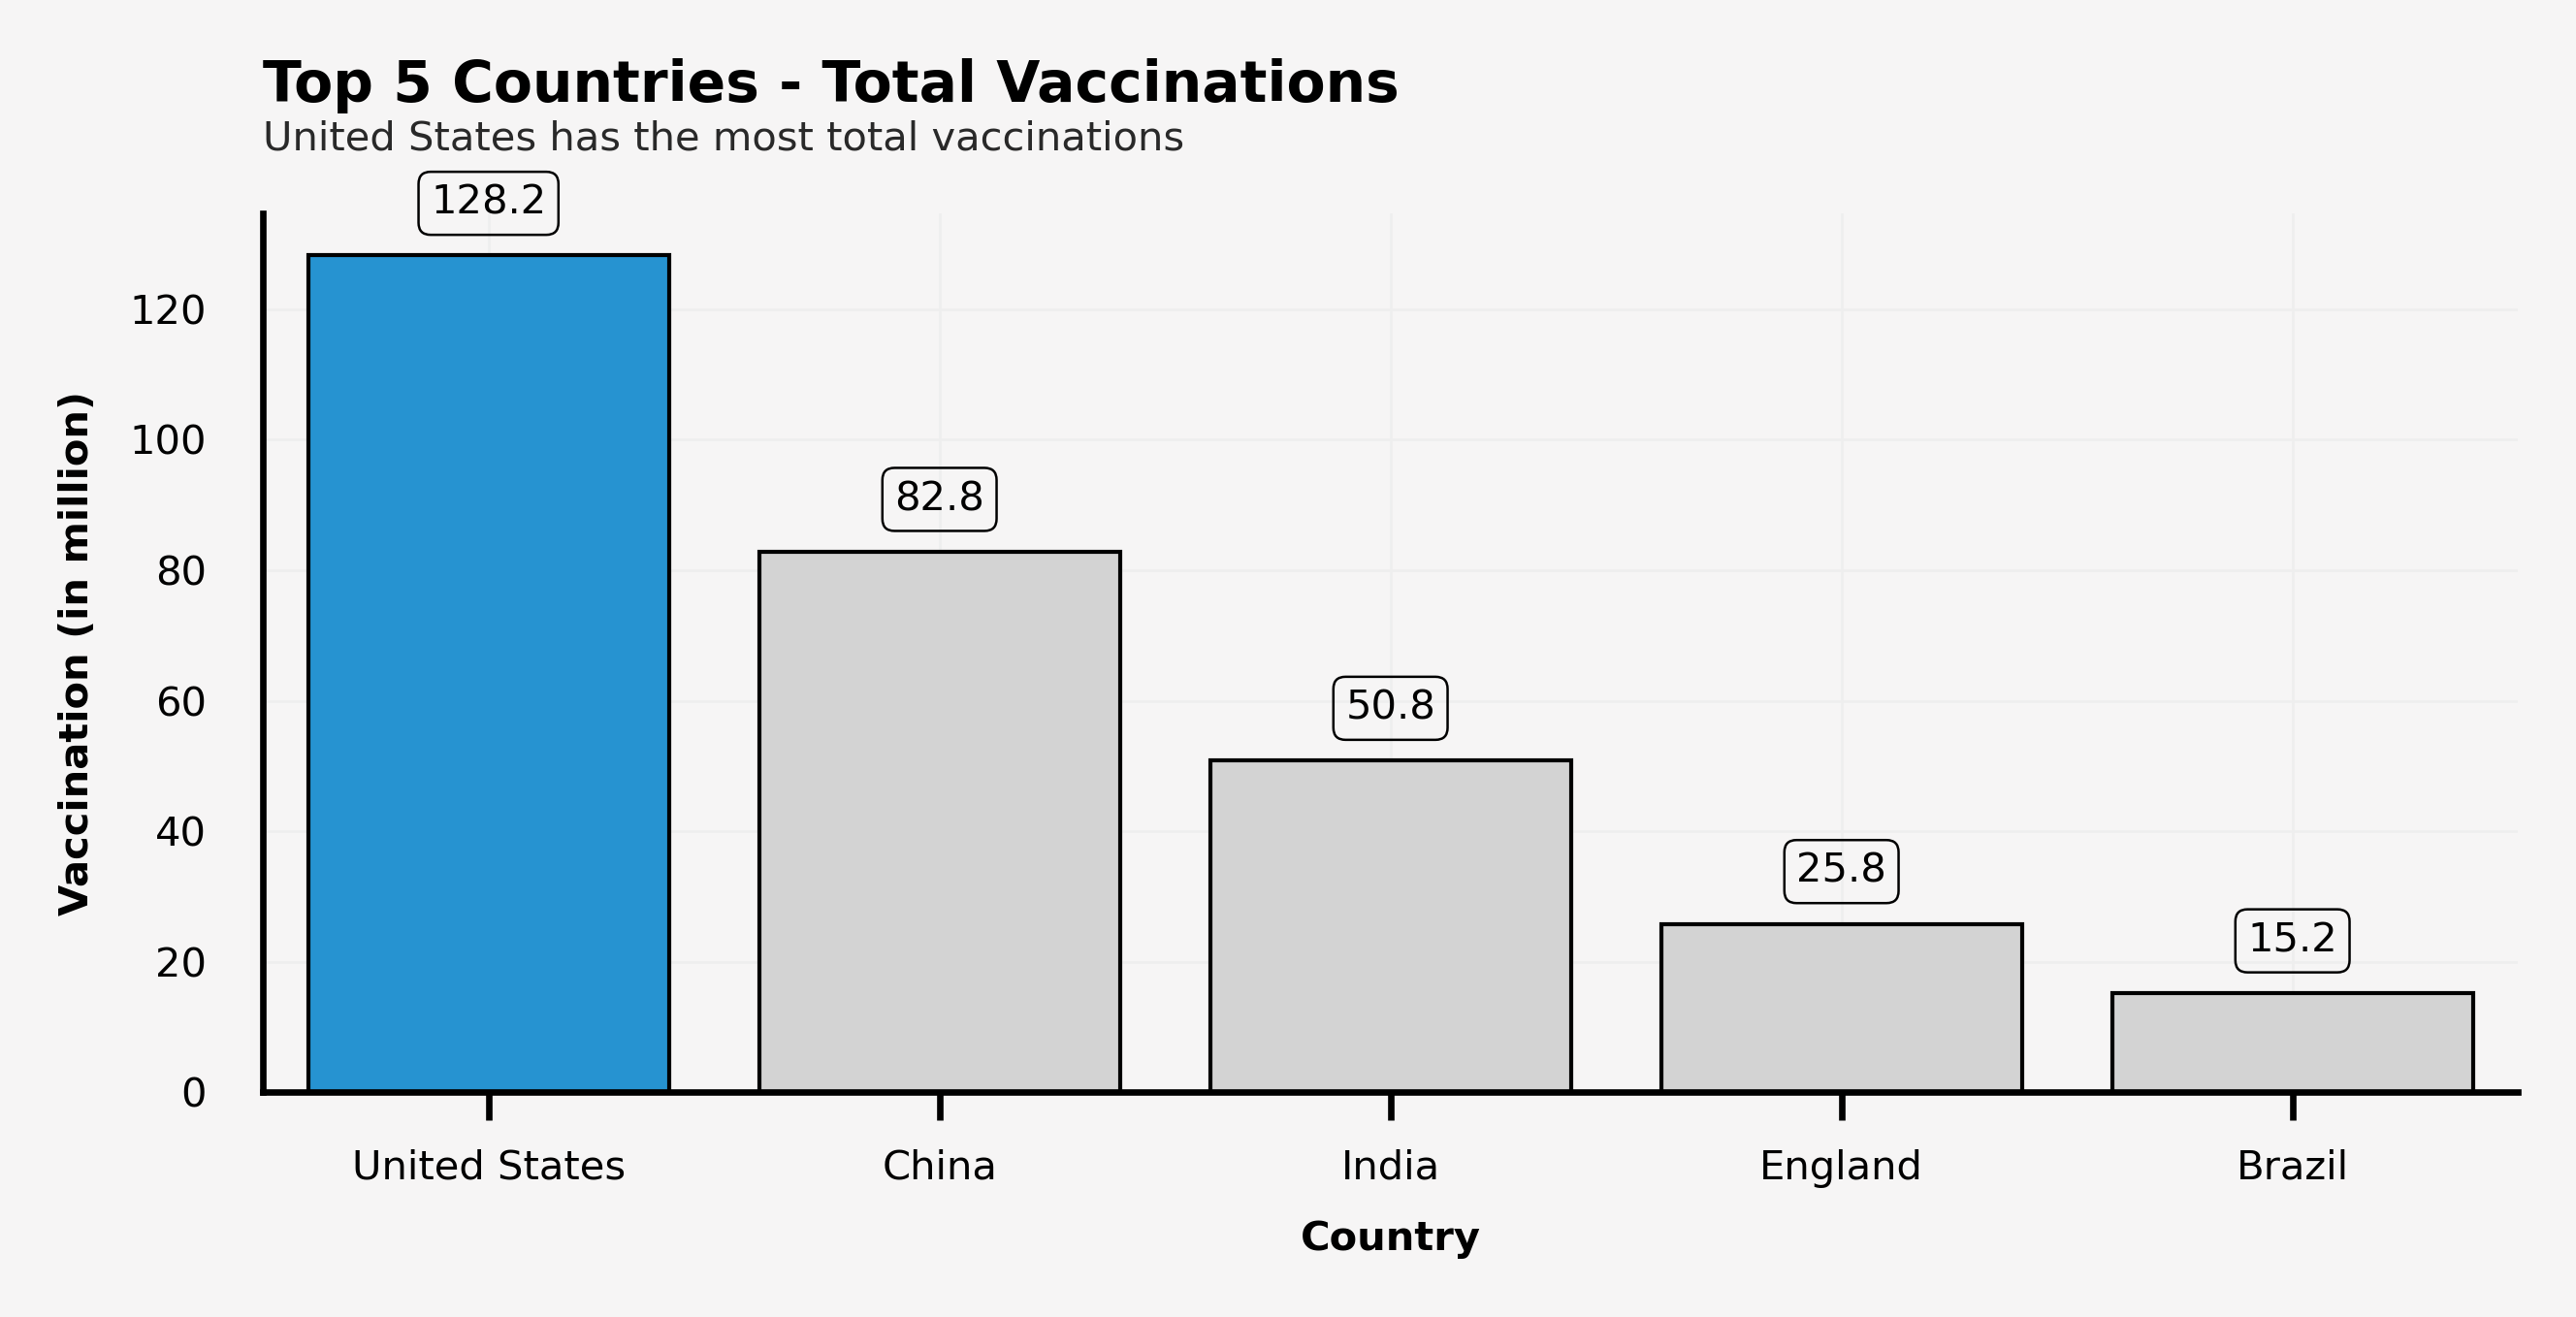

In [11]:
top5_countries_total_vaccination = data_ld.sort_values('total_vaccinations', ascending=False)
top5_countries_total_vaccination = top5_countries_total_vaccination[:5]
top5_countries_total_vaccination

background_color = "#f6f5f5"
color_map = ["lightgray" for _ in range(5)]
color_map[0] = "#2693d1"
sns.set_palette(sns.color_palette(color_map))

plt.rcParams['figure.dpi'] = 600
fig = plt.figure(figsize=(5, 2), facecolor='#f6f5f5')
gs = fig.add_gridspec(1, 1)
gs.update(wspace=0, hspace=0)
ax0 = fig.add_subplot(gs[0, 0])
ax0.set_facecolor(background_color)
for s in ["right", "top"]:
    ax0.spines[s].set_visible(False)
ax0.tick_params(axis = "y", which = "both", left = False)

ax0.text(-0.5, 150, 'Top 5 Countries - Total Vaccinations', color='black', fontsize=7, ha='left', va='bottom', weight='bold')
ax0.text(-0.5, 149, 'United States has the most total vaccinations', 
         color='#292929', fontsize=5, ha='left', va='top')
ax0_sns = sns.barplot(ax=ax0, x=top5_countries_total_vaccination['country'], 
                      y=top5_countries_total_vaccination['total_vaccinations']/1000000, zorder=2, 
                      linewidth=0.5, edgecolor='black', saturation=1)
ax0_sns.set_xlabel("Country",fontsize=5, weight='bold')
ax0_sns.set_ylabel("Vaccination (in million)",fontsize=5, weight='bold')
ax0.grid(which='major', axis='x', zorder=0, color='#EEEEEE', lw=0.3)
ax0.grid(which='major', axis='y', zorder=0, color='#EEEEEE', lw=0.3)
ax0_sns.tick_params(labelsize=5)

for p in ax0.patches:
    value = f'{p.get_height():,.1f}'
    x = p.get_x() + p.get_width() / 2
    y = p.get_y() + p.get_height() + 8
    ax0.text(x, y, value, ha='center', va='center', fontsize=5, 
            bbox=dict(facecolor='none', edgecolor='black', boxstyle='round', linewidth=0.3))

plt.show()

`United States` is the leader in total vaccinations, followed by `China` in the second place and `India` in the third place. `England` and `Brazil` are in fourth and fifth place, respectively.

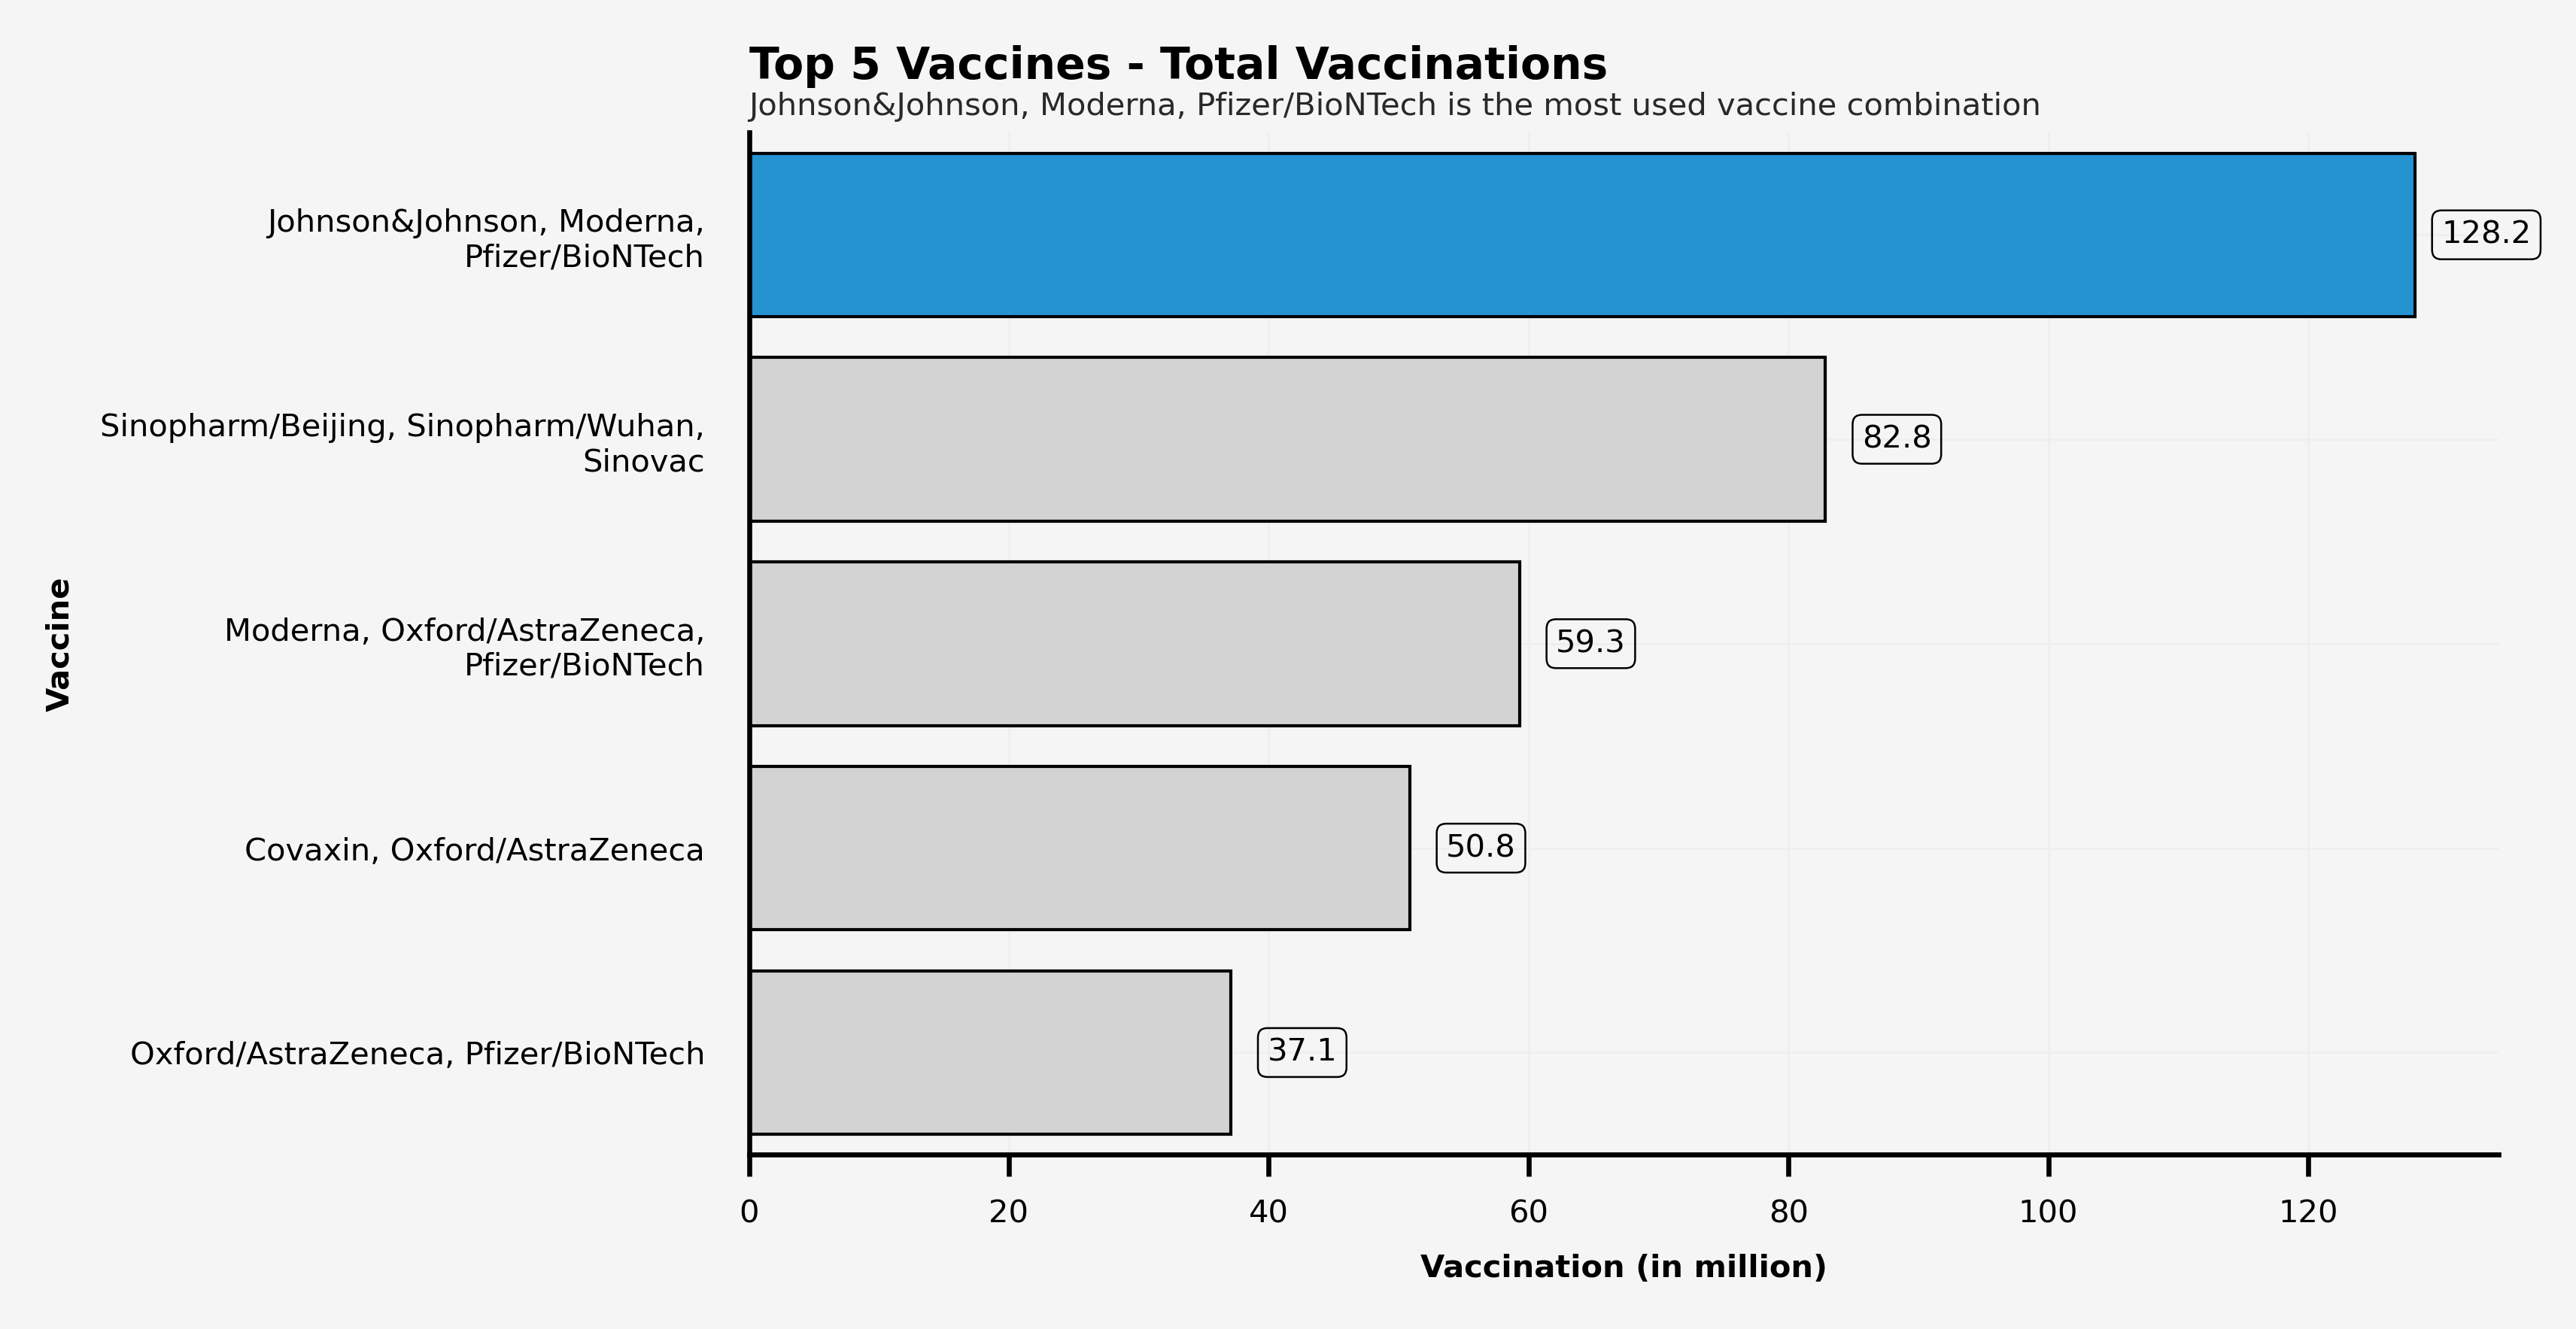

In [12]:
comb_vaccine = data_ld.groupby('vaccines')['total_vaccinations'].sum().sort_values(ascending=False)
comb_vaccine = comb_vaccine/1000000
comb_vaccine = comb_vaccine[:5]

background_color = "#f6f5f5"
color_map = ["lightgray" for _ in range(26)]
color_map[0] = "#2693d1"
sns.set_palette(sns.color_palette(color_map))

plt.rcParams['figure.dpi'] = 600
fig = plt.figure(figsize=(5, 3), facecolor='#f6f5f5')
gs = fig.add_gridspec(1, 1)
gs.update(wspace=0, hspace=0)
ax0 = fig.add_subplot(gs[0, 0])
ax0.set_facecolor(background_color)
for s in ["right", "top"]:
    ax0.spines[s].set_visible(False)
ax0.tick_params(axis = "y", which = "both", left = False)

ax0.text(0, -0.72, 'Top 5 Vaccines - Total Vaccinations', color='black', fontsize=7, ha='left', va='bottom', weight='bold')
ax0.text(0, -0.7, 'Johnson&Johnson, Moderna, Pfizer/BioNTech is the most used vaccine combination', 
         color='#292929', fontsize=5, ha='left', va='top')
ax0_sns = sns.barplot(ax=ax0, y=comb_vaccine.index, x=comb_vaccine, zorder=2, orient='h', 
                      linewidth=0.5, edgecolor='black', saturation=1)
ax0_sns.set_xlabel("Vaccination (in million)",fontsize=5, weight='bold')
ax0_sns.set_ylabel("Vaccine",fontsize=5, weight='bold')
ax0.grid(which='major', axis='x', zorder=0, color='#EEEEEE', lw=0.3)
ax0.grid(which='major', axis='y', zorder=0, color='#EEEEEE', lw=0.3)
ax0_sns.tick_params(labelsize=5)
ax0.set_yticklabels([textwrap.fill(e, 35) for e in comb_vaccine.index])

for p in ax0.patches:
    value = f'{p.get_width():,.1f}'
    x = p.get_x() + p.get_width() + 5.5
    y = p.get_y() + p.get_height() / 2 
    ax0.text(x, y, value, ha='center', va='center', fontsize=5, 
            bbox=dict(facecolor='none', edgecolor='black', boxstyle='round', linewidth=0.3))

plt.show()

`Johnson&Johnson, Moderna, Pfizer/BioNTech` leading the vaccine usage in the world, as this is the multiple vaccines combination used by `United States` as the leader of total vaccination. The second highest usage of vaccines is  `Sinopharm/Beijing, Sinopharm/Wuhan, Sinovac`, this is the multiple vaccines combination used only by `China` and `China` is the second highest country in term of total vaccination. In the third place, there is `Moderna, Oxford/AstraZeneca, Pfizer/BioNTech`, this multiple vaccines combination is used by `24` countries mainly from `Europe`. Though `India` in the third place in terms of total vaccinations, but its multiple vaccines combination, `Covaxin, Oxford/AstraZeneca`, is still behind `Moderna, Oxford/AstraZeneca, Pfizer/BioNTech`.

<a id="3.4.2"></a>
## 3.4.2 Vaccinated People

Consistent with total vaccination, top 3 countries with vaccinated people above 20 million are United States, India and England and number of vaccinated people is consistently lower compared to total vaccination. Unfortunately, there is no information on vaccinated people in China so it was taken out from the analysis.

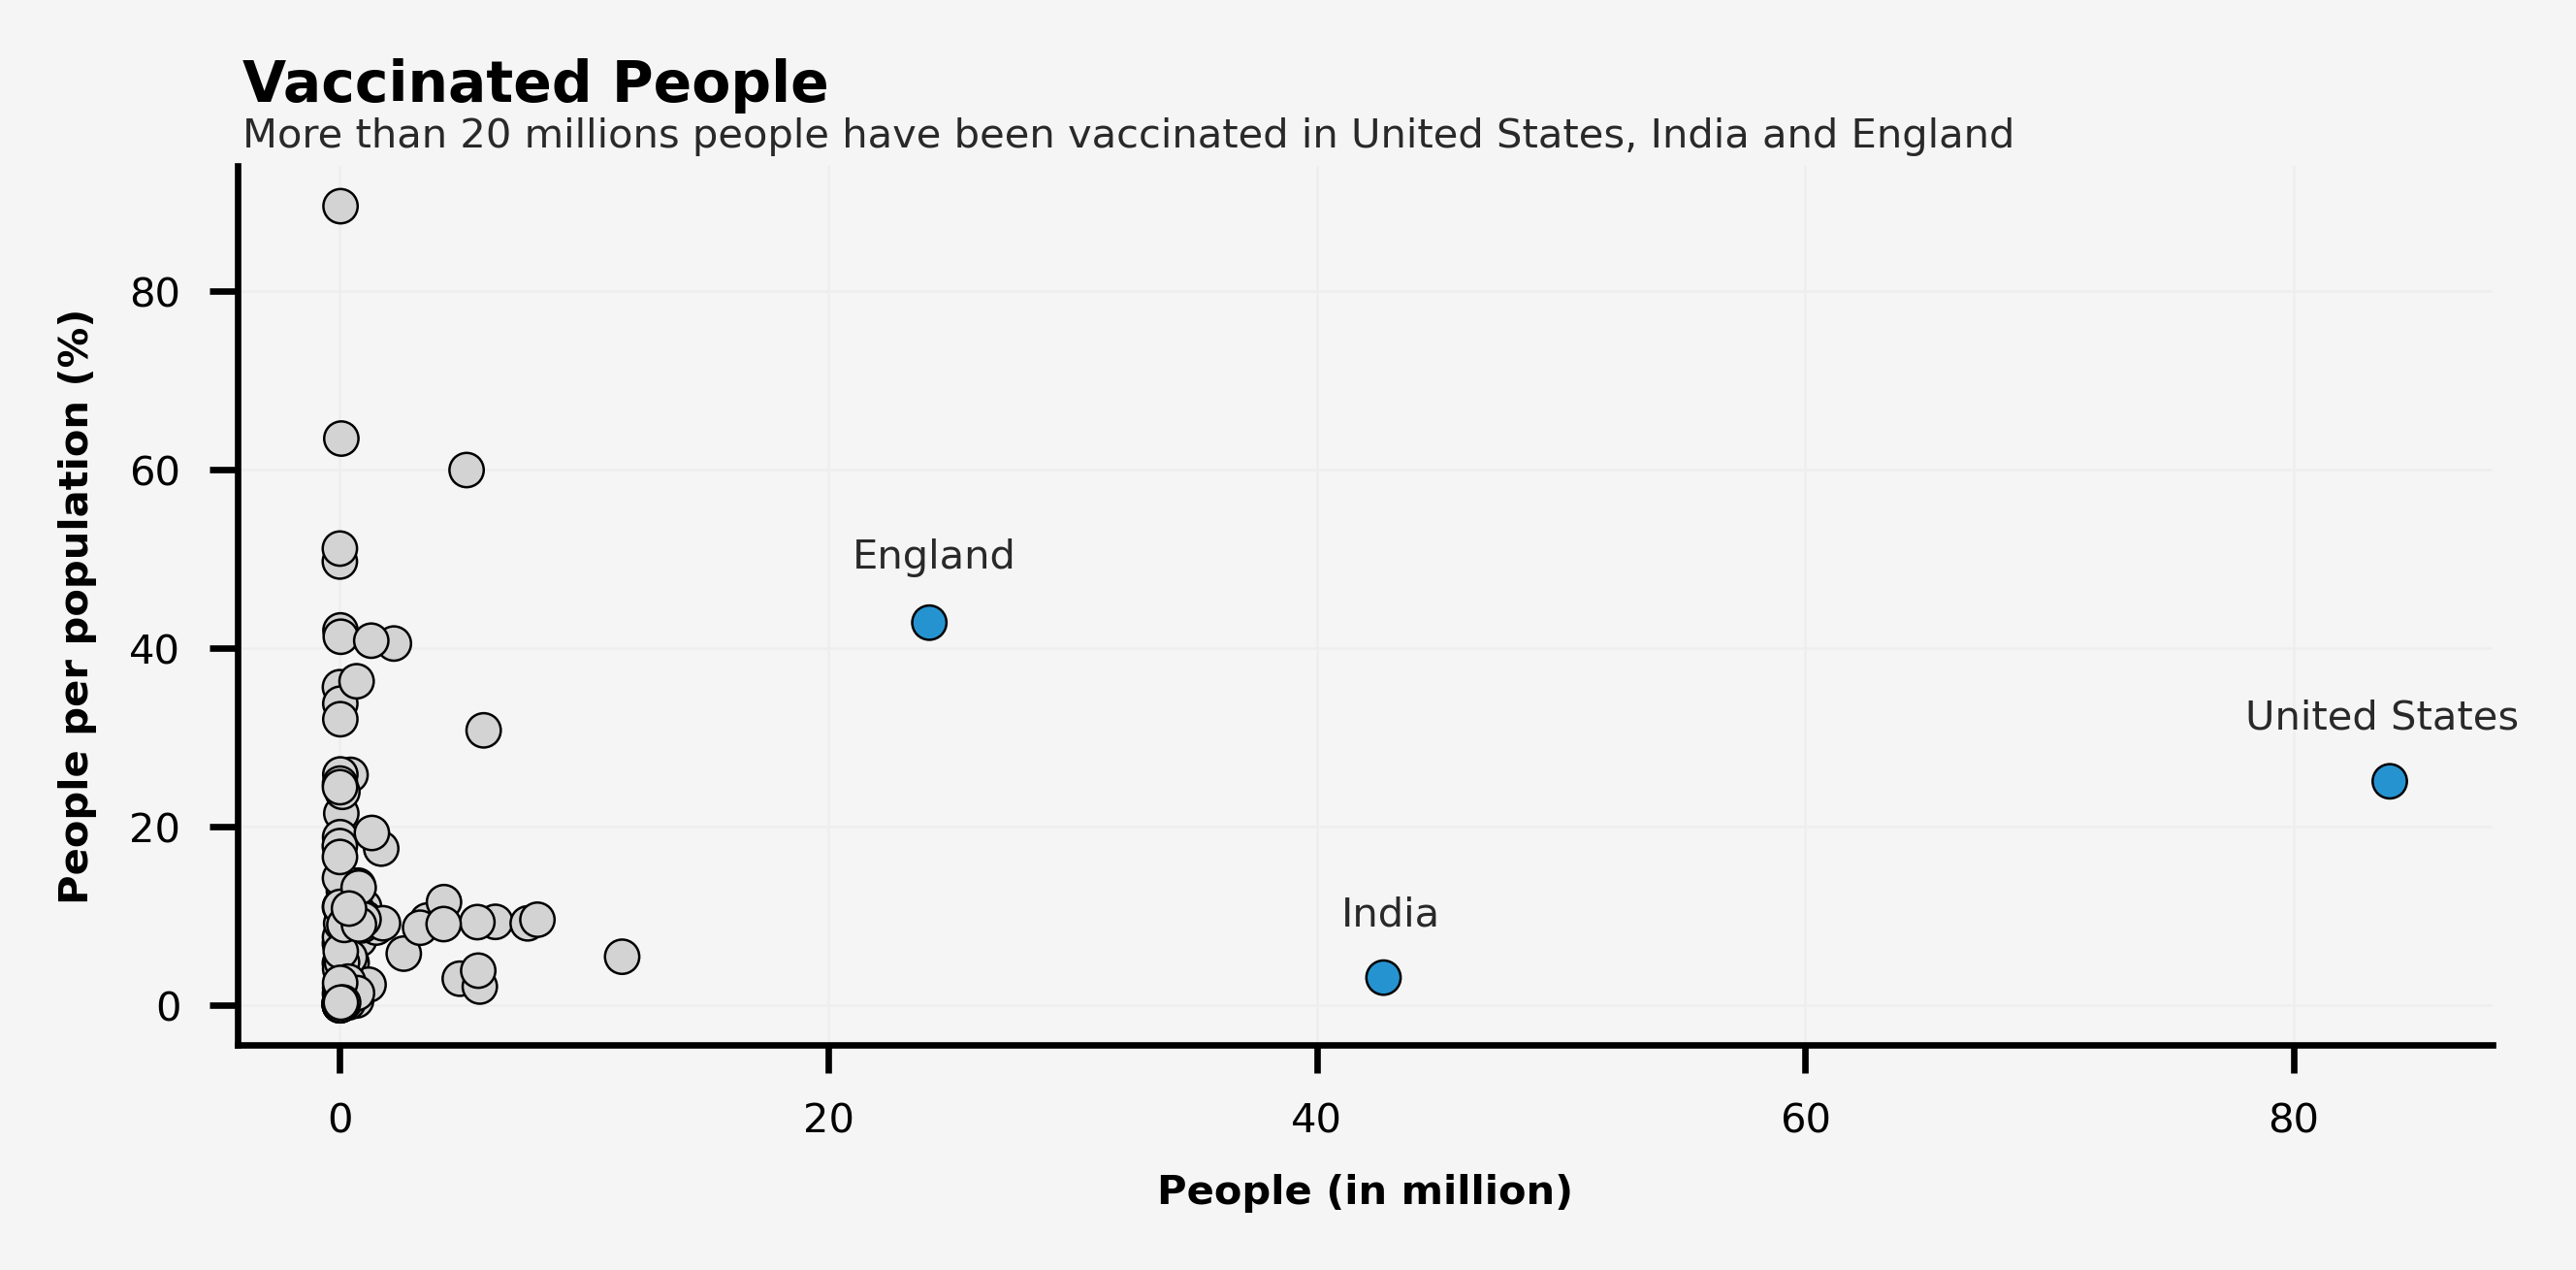

In [13]:
background_color = "#f6f5f5"

color_map = ["lightgray" for _ in range(2)]
color_map[1] = "#2693d1"
sns.set_palette(sns.color_palette(color_map))
value_list = ['United States', 'England', 'India']
boolean_series = data_ld.country.isin(value_list)
data_ld['color'] = boolean_series

plt.rcParams['figure.dpi'] = 600
fig = plt.figure(figsize=(5, 2), facecolor='#f6f5f5')
gs = fig.add_gridspec(1, 1)
gs.update(wspace=0, hspace=0)
ax0 = fig.add_subplot(gs[0, 0])
ax0.set_facecolor(background_color)
for s in ["right", "top"]:
    ax0.spines[s].set_visible(False)

ax0.text(-4, 100, 'Vaccinated People', color='black', fontsize=7, ha='left', va='bottom', weight='bold')
ax0.text(-4, 99.6, 'More than 20 millions people have been vaccinated in United States, India and England', color='#292929', fontsize=5, ha='left', va='top')
ax0.text(78, 30, 'United States', color='#292929', fontsize=5, ha='left', va='bottom')
ax0.text(41, 8, 'India', color='#292929', fontsize=5, ha='left', va='bottom')
ax0.text(21, 48, 'England', color='#292929', fontsize=5, ha='left', va='bottom')
ax0_sns = sns.scatterplot(ax=ax0, y=data_ld['people_vaccinated_per_hundred'], x=data_ld['people_vaccinated']/1000000, 
                          zorder=2, linewidth=0.3, edgecolor='black', hue=data_ld['color'], legend=False, size=1)
ax0_sns.set_xlabel("People (in million)",fontsize=5, weight='bold')
ax0_sns.set_ylabel("People per population (%)",fontsize=5, weight='bold')
ax0.grid(which='major', axis='x', zorder=0, color='#EEEEEE', lw=0.3)
ax0.grid(which='major', axis='y', zorder=0, color='#EEEEEE', lw=0.3)
ax0_sns.tick_params(labelsize=5)

plt.show()

Vaccinated people per total population is lower than total vaccination per total population, especially can be seen on United States; total vaccinated at `38.4%` drop into `25.1%`. This drop may due to more people have been fully vaccinated, considering 2 vaccines will be needed to be fully vaccinated. In general United State has vaccinated `25.1%` of its citizens.

Opposite with United States, total vaccinated people per total population in India and England are not far from vaccinated people per total population. There are 2 possible scenarios:
* This may due to many people get their first shoot leading to lower fully vaccinated (considering 2 vaccines needed). 
* The country use more single shot vaccine, if this the case, fully vacinated will not get far from the vaccinated people per total population.

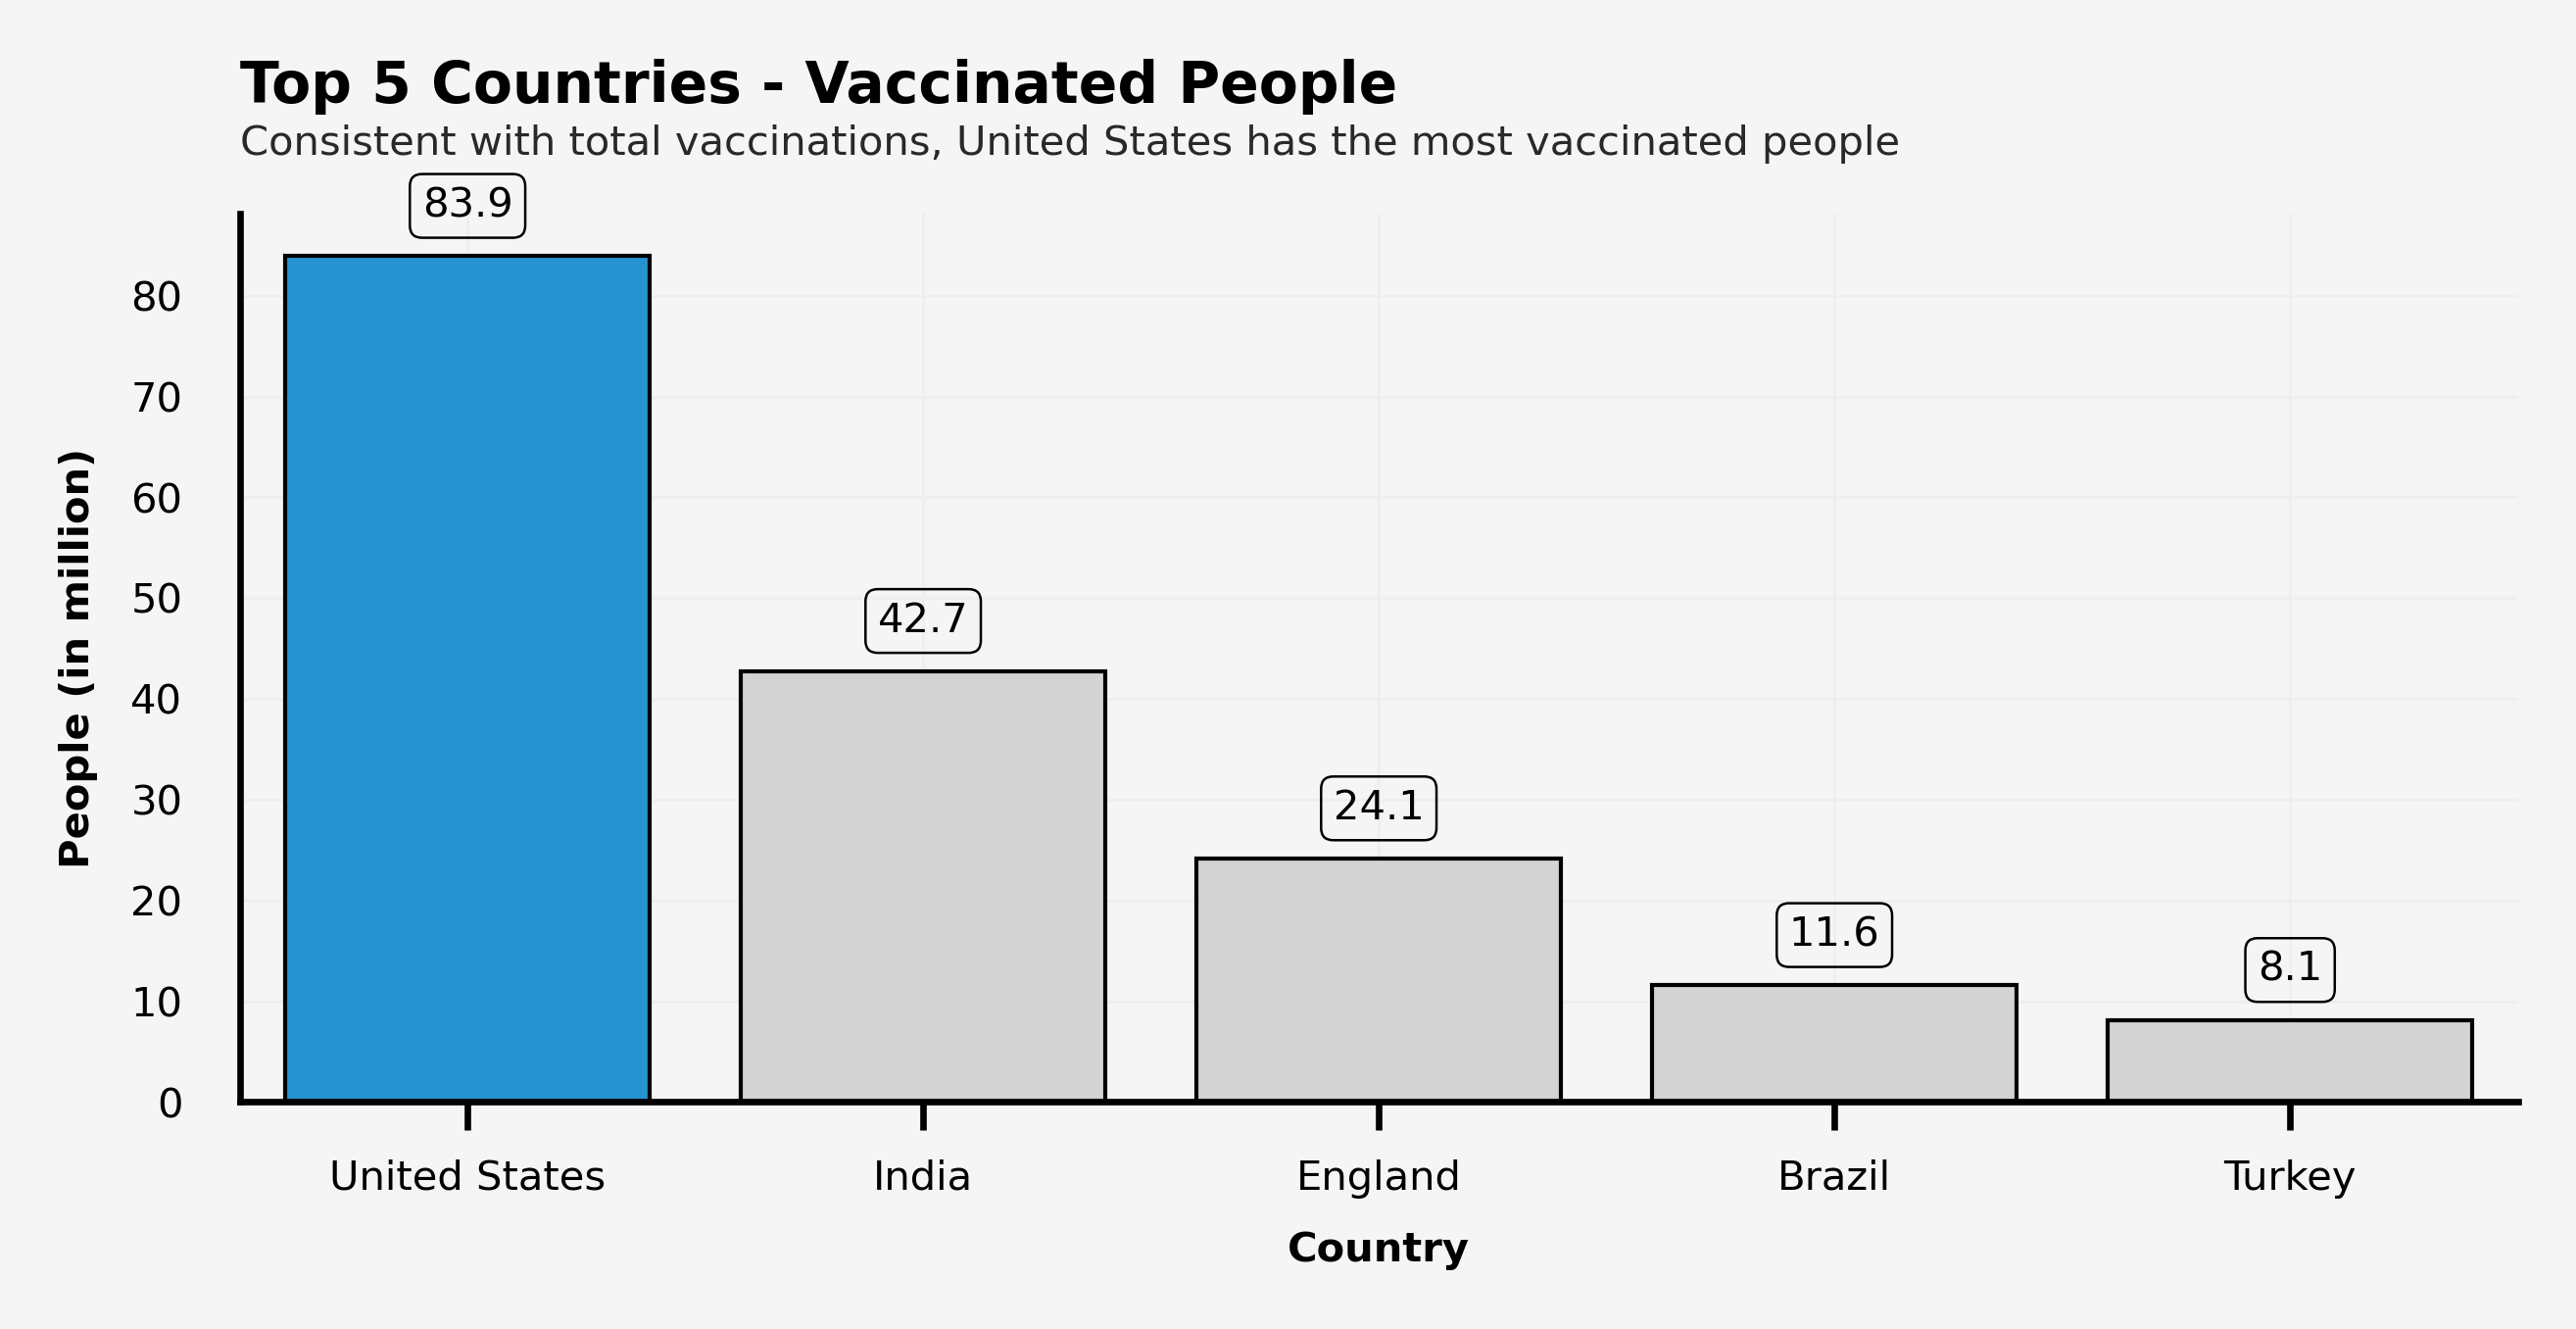

In [14]:
top5_countries_vaccinated = data_ld.sort_values('people_vaccinated', ascending=False)
top5_countries_vaccinated = top5_countries_vaccinated[:5]
top5_countries_vaccinated

background_color = "#f6f5f5"
color_map = ["lightgray" for _ in range(5)]
color_map[0] = "#2693d1"
sns.set_palette(sns.color_palette(color_map))

plt.rcParams['figure.dpi'] = 600
fig = plt.figure(figsize=(5, 2), facecolor='#f6f5f5')
gs = fig.add_gridspec(1, 1)
gs.update(wspace=0, hspace=0)
ax0 = fig.add_subplot(gs[0, 0])
ax0.set_facecolor(background_color)
for s in ["right", "top"]:
    ax0.spines[s].set_visible(False)
ax0.tick_params(axis = "y", which = "both", left = False)

ax0.text(-0.5, 98, 'Top 5 Countries - Vaccinated People', color='black', fontsize=7, ha='left', va='bottom', weight='bold')
ax0.text(-0.5, 97, 'Consistent with total vaccinations, United States has the most vaccinated people', 
         color='#292929', fontsize=5, ha='left', va='top')
ax0_sns = sns.barplot(ax=ax0, x=top5_countries_vaccinated['country'], y=top5_countries_vaccinated['people_vaccinated']/1000000, 
                      zorder=2, linewidth=0.5, edgecolor='black', saturation=1)
ax0_sns.set_xlabel("Country",fontsize=5, weight='bold')
ax0_sns.set_ylabel("People (in million)",fontsize=5, weight='bold')
ax0.grid(which='major', axis='x', zorder=0, color='#EEEEEE', lw=0.3)
ax0.grid(which='major', axis='y', zorder=0, color='#EEEEEE', lw=0.3)
ax0_sns.tick_params(labelsize=5)

for p in ax0.patches:
    value = f'{p.get_height():,.1f}'
    x = p.get_x() + p.get_width() / 2
    y = p.get_y() + p.get_height() + 5
    ax0.text(x, y, value, ha='center', va='center', fontsize=5, 
            bbox=dict(facecolor='none', edgecolor='black', boxstyle='round', linewidth=0.3))

plt.show()

`United States` is also the leader in vaccinated people followed by `India` in the second place. `China` may in the second place but due to unavailable data, it is taken out from the analysis as has been noted before. `England` in in the third place followed by `Brazil` and `Turkey` in fourth and fifth place, respectively. 

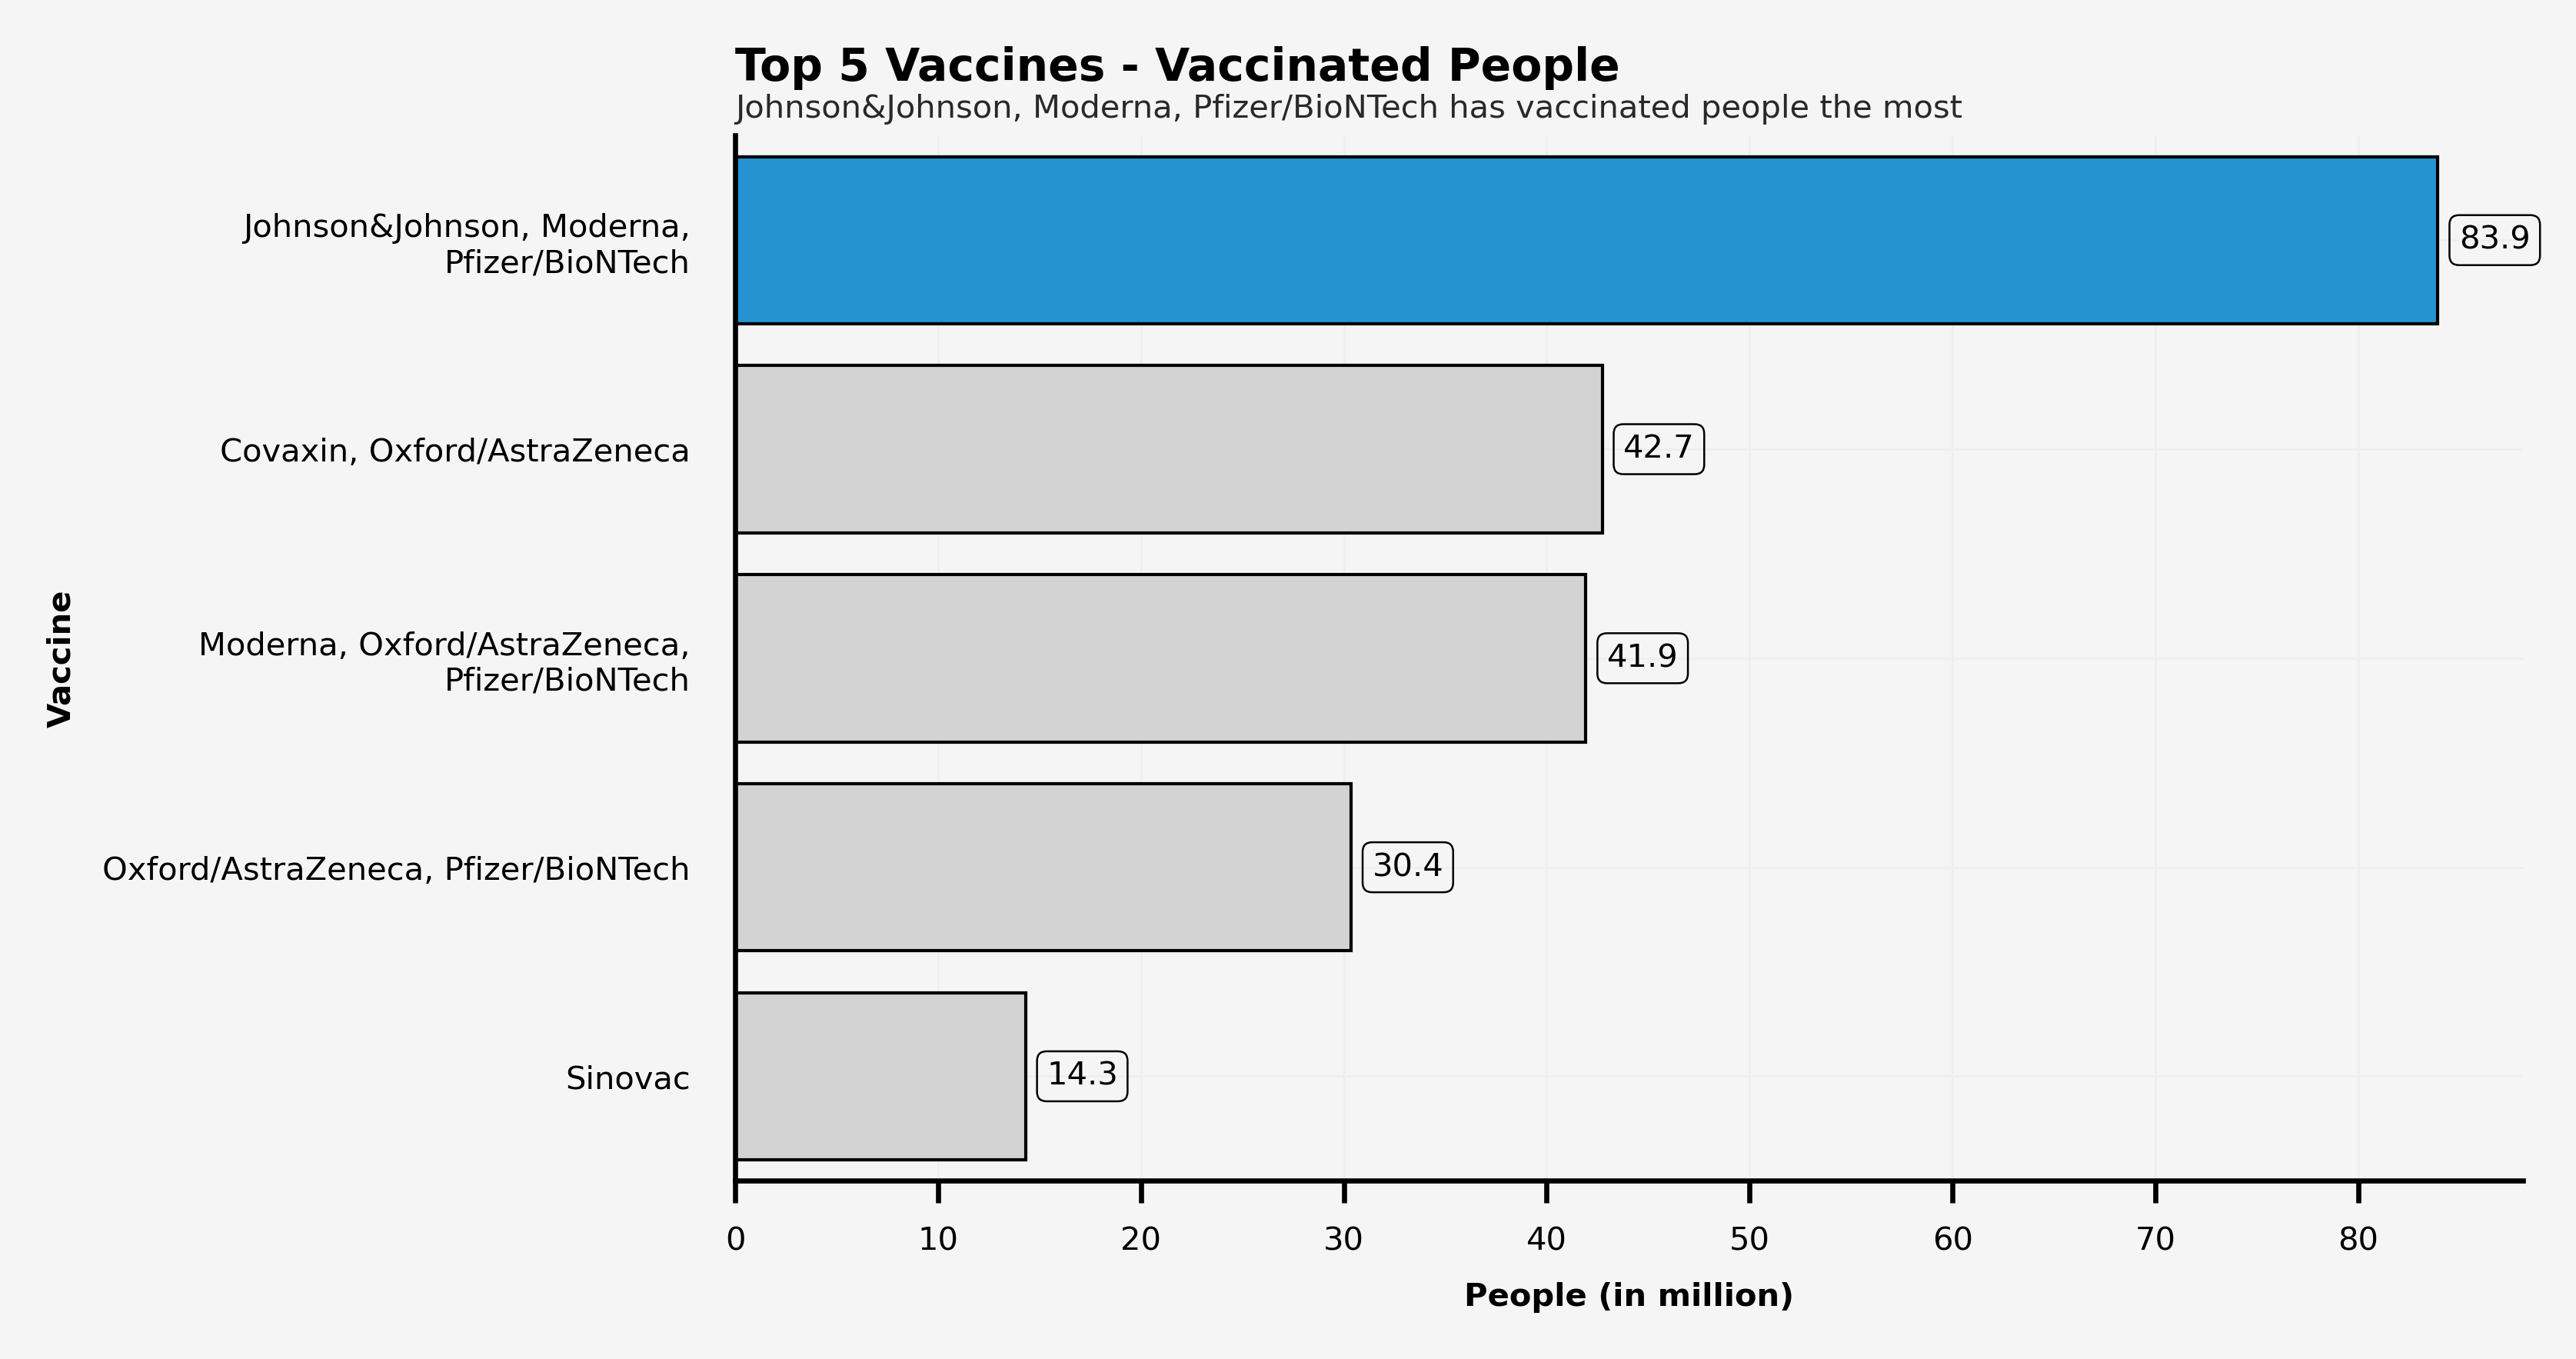

In [15]:
comb_vaccine = data_ld.groupby('vaccines')['people_vaccinated'].sum().sort_values(ascending=False)
comb_vaccine = comb_vaccine/1000000
comb_vaccine = comb_vaccine[:5]

background_color = "#f6f5f5"
color_map = ["lightgray" for _ in range(26)]
color_map[0] = "#2693d1"
sns.set_palette(sns.color_palette(color_map))

plt.rcParams['figure.dpi'] = 600
fig = plt.figure(figsize=(5, 3), facecolor='#f6f5f5')
gs = fig.add_gridspec(1, 1)
gs.update(wspace=0, hspace=0)
ax0 = fig.add_subplot(gs[0, 0])
ax0.set_facecolor(background_color)
for s in ["right", "top"]:
    ax0.spines[s].set_visible(False)
ax0.tick_params(axis = "y", which = "both", left = False)

ax0.text(0, -0.72, 'Top 5 Vaccines - Vaccinated People', color='black', fontsize=7, ha='left', va='bottom', weight='bold')
ax0.text(0, -0.7, 'Johnson&Johnson, Moderna, Pfizer/BioNTech has vaccinated people the most', 
         color='#292929', fontsize=5, ha='left', va='top')
ax0_sns = sns.barplot(ax=ax0, y=comb_vaccine.index, x=comb_vaccine, zorder=2, orient='h', 
                      linewidth=0.5, edgecolor='black', saturation=1)
ax0_sns.set_xlabel("People (in million)",fontsize=5, weight='bold')
ax0_sns.set_ylabel("Vaccine",fontsize=5, weight='bold')
ax0.grid(which='major', axis='x', zorder=0, color='#EEEEEE', lw=0.3)
ax0.grid(which='major', axis='y', zorder=0, color='#EEEEEE', lw=0.3)
ax0_sns.tick_params(labelsize=5)
ax0.set_yticklabels([textwrap.fill(e, 35) for e in comb_vaccine.index])

for p in ax0.patches:
    value = f'{p.get_width():,.1f}'
    x = p.get_x() + p.get_width() + 2.8
    y = p.get_y() + p.get_height() / 2 
    ax0.text(x, y, value, ha='center', va='center', fontsize=5, 
            bbox=dict(facecolor='none', edgecolor='black', boxstyle='round', linewidth=0.3))

plt.show()

Alligned with total vaccinations, vaccinated people using `Johnson&Johnson, Moderna, Pfizer/BioNTech` is the highest. `India` that use `Covaxin, Oxford/AstraZeneca` has more vaccinated people compared to several countries - mainly from `Europe` that use `Moderna, Oxford/AstraZeneca, Pfizer/BioNTech` multiple vaccine combinations though the differences are not far. `Sinovac` is emerged in the `5th` place as `Sinopharm/Beijing, Sinopharm/Wuhan, Sinovac` is taken out due to non-available data for vaccinated people. `Sinovac` is a single vaccine used by `Azerbaijan`, `Indonesia` and `Turkey`, this high number come from `Indonesia` high population of `275.7 million` (4th most populated country in the world).

<a id="3.4.3"></a>
## 3.4.3 Fully Vaccinated People

The first scenario may be the case for `England` and `India` as there is a sudden drop on the number of fully vacinated people. As a reminder the first scenario is  where many people get their first shoot leading to lower fully vaccinated (considering 2 vaccines needed) and higher vaccinated people.

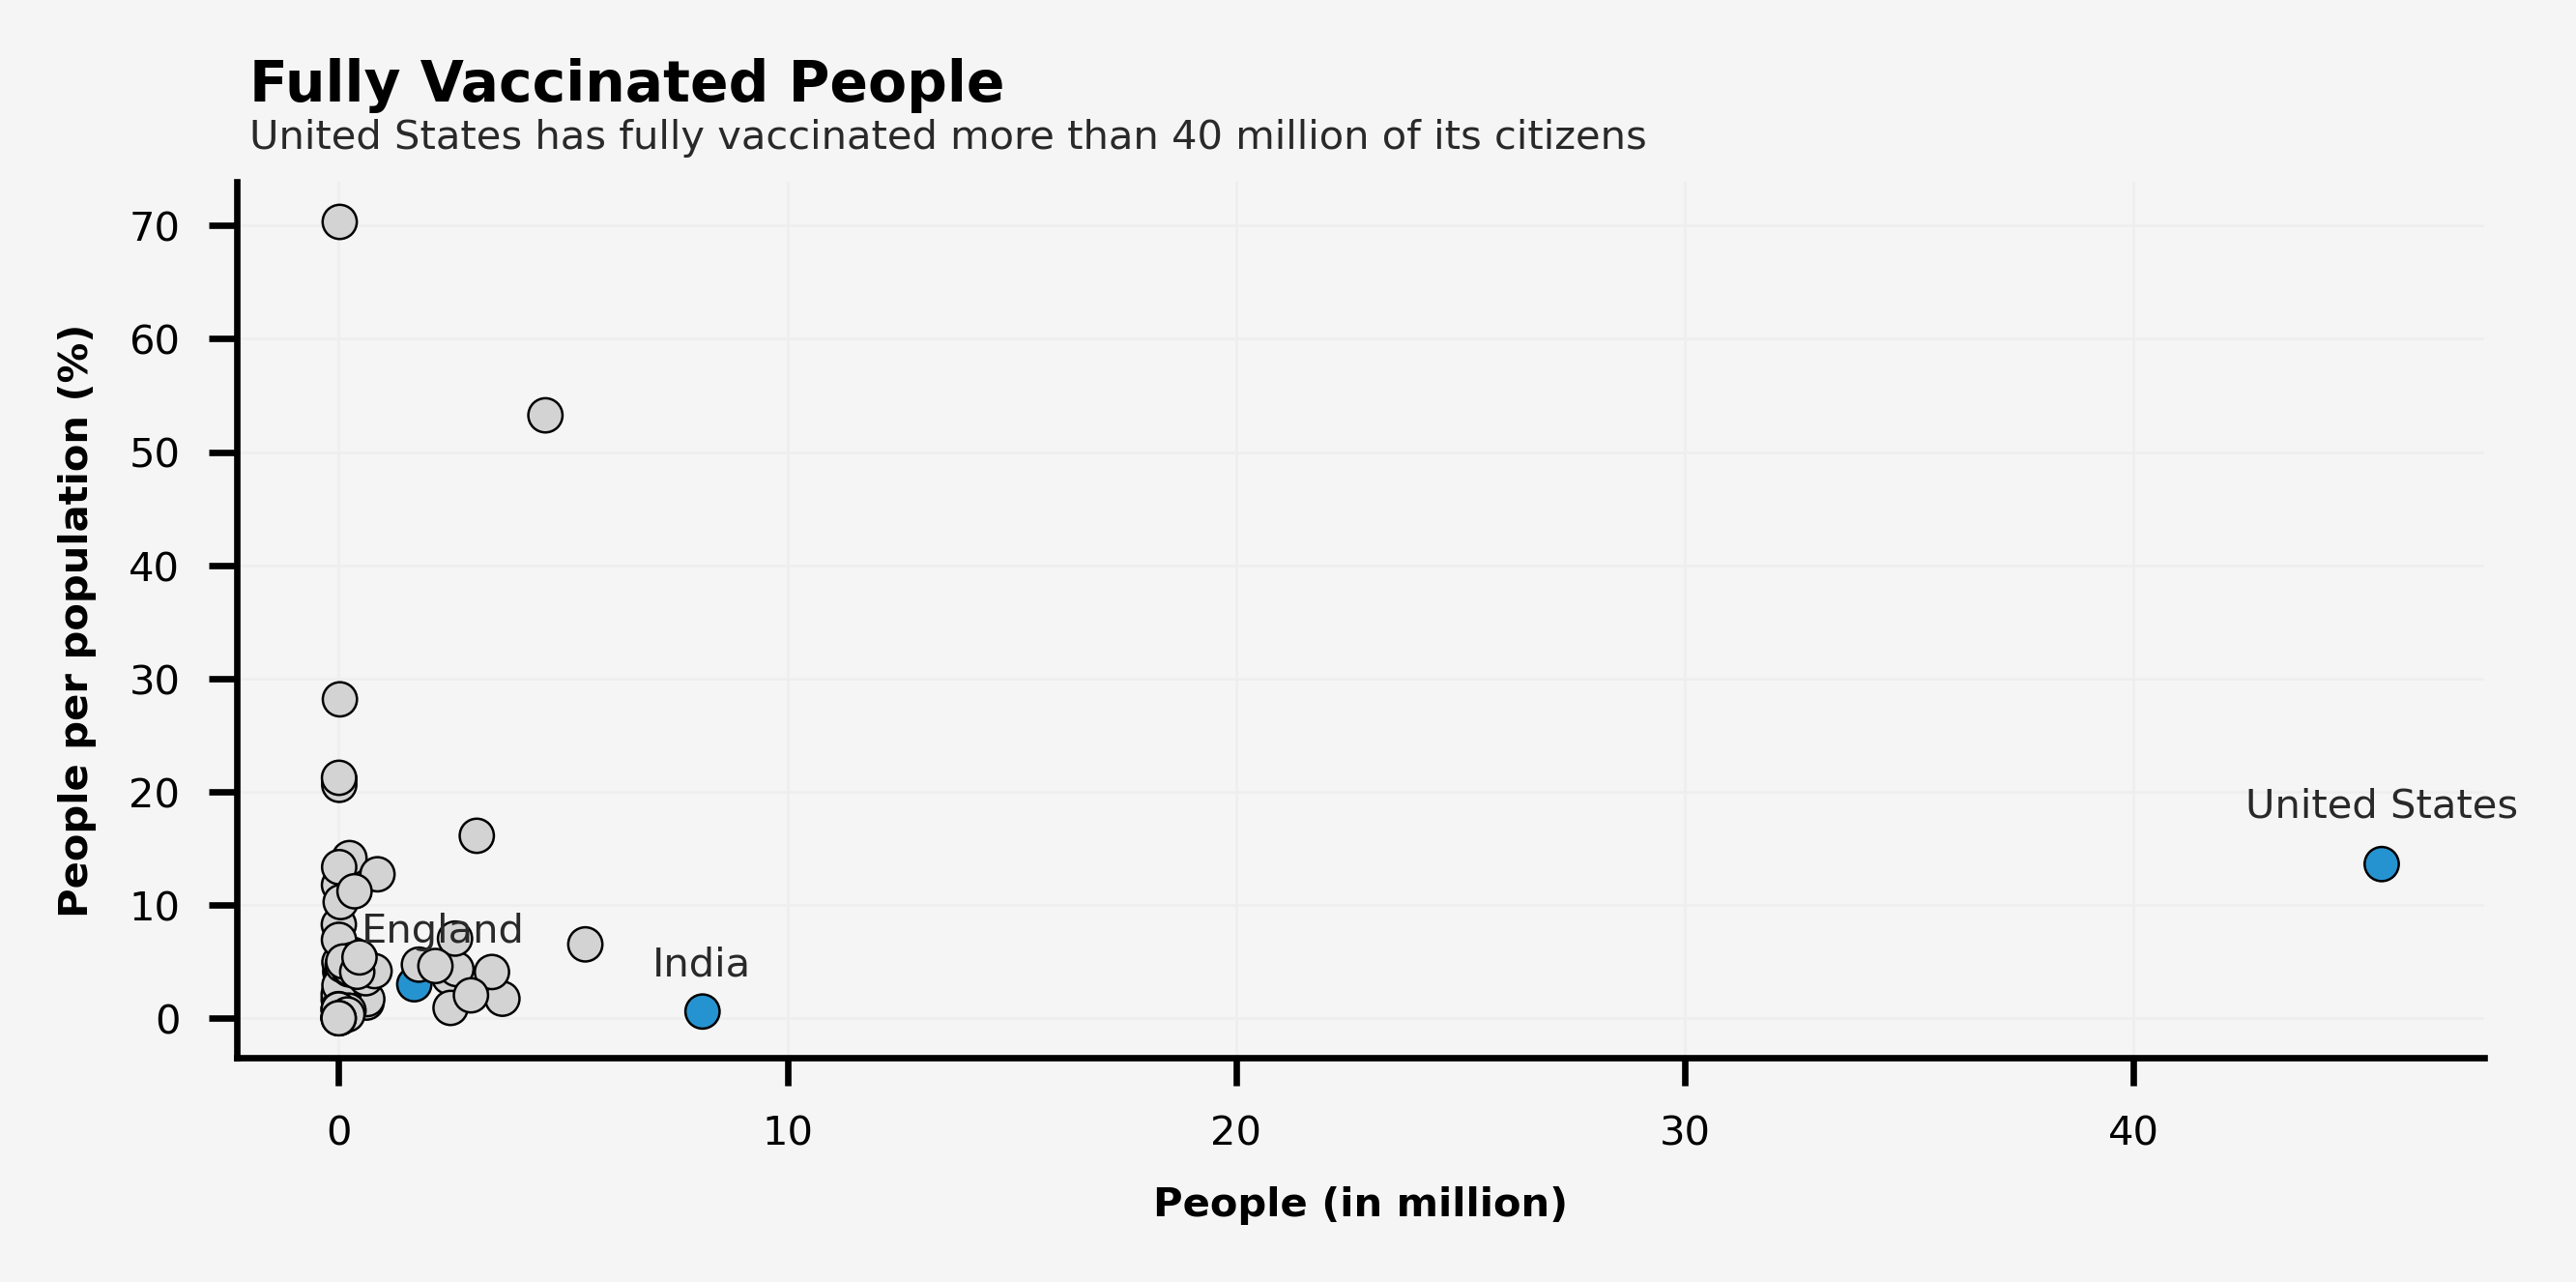

In [16]:
background_color = "#f6f5f5"

color_map = ["lightgray" for _ in range(2)]
color_map[1] = "#2693d1"
sns.set_palette(sns.color_palette(color_map))
value_list = ['United States', 'England', 'India']
boolean_series = data_ld.country.isin(value_list)
data_ld['color'] = boolean_series

plt.rcParams['figure.dpi'] = 600
fig = plt.figure(figsize=(5, 2), facecolor='#f6f5f5')
gs = fig.add_gridspec(1, 1)
gs.update(wspace=0, hspace=0)
ax0 = fig.add_subplot(gs[0, 0])
ax0.set_facecolor(background_color)
for s in ["right", "top"]:
    ax0.spines[s].set_visible(False)

ax0.text(-2, 80, 'Fully Vaccinated People', color='black', fontsize=7, ha='left', va='bottom', weight='bold')
ax0.text(-2, 79.5, 'United States has fully vaccinated more than 40 million of its citizens', color='#292929', fontsize=5, ha='left', va='top')
ax0.text(42.5, 17, 'United States', color='#292929', fontsize=5, ha='left', va='bottom')
ax0.text(7, 3, 'India', color='#292929', fontsize=5, ha='left', va='bottom')
ax0.text(0.5, 6, 'England', color='#292929', fontsize=5, ha='left', va='bottom')
ax0_sns = sns.scatterplot(ax=ax0, y=data_ld['people_fully_vaccinated_per_hundred'], x=data_ld['people_fully_vaccinated']/1000000, 
                          zorder=2, linewidth=0.3, edgecolor='black', hue=data_ld['color'], legend=False, size=1)
ax0_sns.set_xlabel("People (in million)",fontsize=5, weight='bold')
ax0_sns.set_ylabel("People per population (%)",fontsize=5, weight='bold')
ax0.grid(which='major', axis='x', zorder=0, color='#EEEEEE', lw=0.3)
ax0.grid(which='major', axis='y', zorder=0, color='#EEEEEE', lw=0.3)
ax0_sns.tick_params(labelsize=5)

plt.show()

People fully vaccinated in `India` has dropped to `8.1 million` from `42.7 million` of vaccinated people or a drop from `3.1%` to `0.59%` where `England` has a more bigger dropped from `24.1 million` to `1.7 million` or a drop from `42.8%` to `3%`, meaning there are many people getting their first shot vaccine in England compared to India.

There is also a drop in `United States` vaccinated people  from `83.9 million` to `45.5 million` or a drop from `25.1%` to `13.6%`. The drop is big but not as significant as India and England, as more `United States` citizens has been fully vaccinated than `India` and `England`. This consistent with the big drop from total vaccinated to vaccinated people as many of `United States` citizens get their second shot.

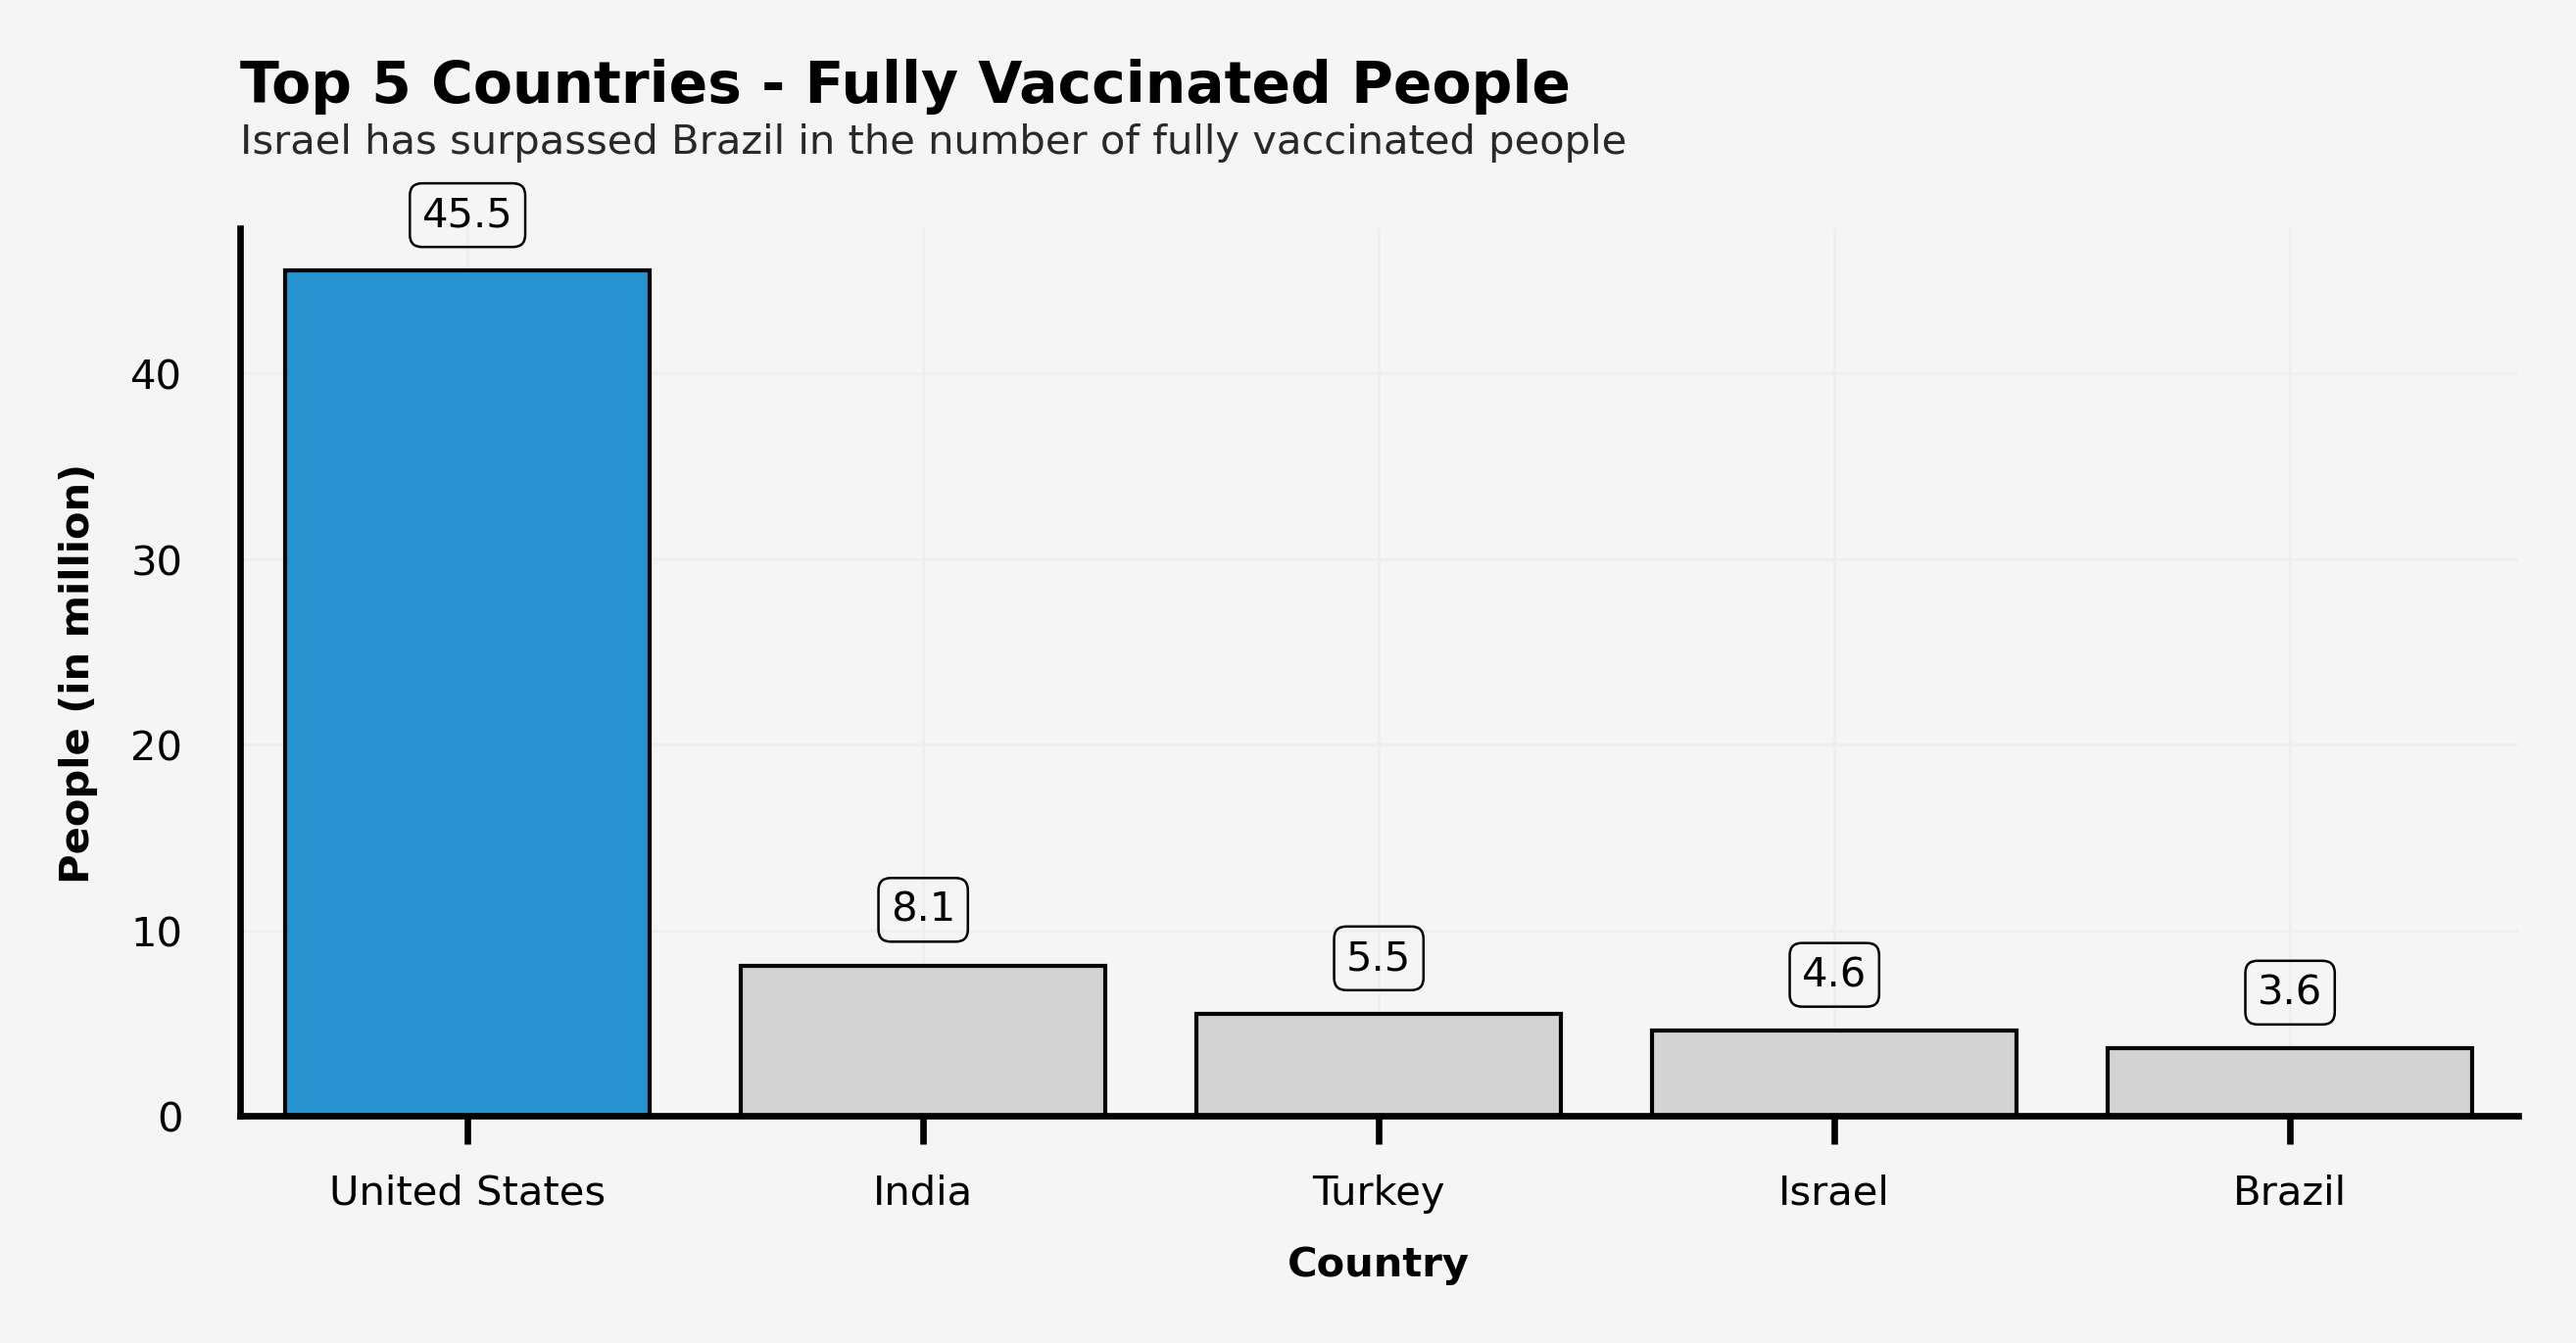

In [17]:
top5_countries_fully_vaccinated = data_ld.sort_values('people_fully_vaccinated', ascending=False)
top5_countries_fully_vaccinated = top5_countries_fully_vaccinated[:5]
top5_countries_fully_vaccinated

background_color = "#f6f5f5"
color_map = ["lightgray" for _ in range(5)]
color_map[0] = "#2693d1"
sns.set_palette(sns.color_palette(color_map))

plt.rcParams['figure.dpi'] = 600
fig = plt.figure(figsize=(5, 2), facecolor='#f6f5f5')
gs = fig.add_gridspec(1, 1)
gs.update(wspace=0, hspace=0)
ax0 = fig.add_subplot(gs[0, 0])
ax0.set_facecolor(background_color)
for s in ["right", "top"]:
    ax0.spines[s].set_visible(False)
ax0.tick_params(axis = "y", which = "both", left = False)

ax0.text(-0.5, 54, 'Top 5 Countries - Fully Vaccinated People', color='black', fontsize=7, ha='left', va='bottom', weight='bold')
ax0.text(-0.5, 53.5, 'Israel has surpassed Brazil in the number of fully vaccinated people ', 
         color='#292929', fontsize=5, ha='left', va='top')
ax0_sns = sns.barplot(ax=ax0, x=top5_countries_fully_vaccinated['country'], y=top5_countries_fully_vaccinated['people_fully_vaccinated']/1000000, 
                      zorder=2, linewidth=0.5, edgecolor='black', saturation=1)
ax0_sns.set_xlabel("Country",fontsize=5, weight='bold')
ax0_sns.set_ylabel("People (in million)",fontsize=5, weight='bold')
ax0.grid(which='major', axis='x', zorder=0, color='#EEEEEE', lw=0.3)
ax0.grid(which='major', axis='y', zorder=0, color='#EEEEEE', lw=0.3)
ax0_sns.tick_params(labelsize=5)

for p in ax0.patches:
    value = f'{p.get_height():,.1f}'
    x = p.get_x() + p.get_width() / 2
    y = p.get_y() + p.get_height() + 3
    ax0.text(x, y, value, ha='center', va='center', fontsize=5, 
            bbox=dict(facecolor='none', edgecolor='black', boxstyle='round', linewidth=0.3))

plt.show()

`United States` still the leader in fully vaccinated people followed by `India` in the second place. In the third and fourth position there are `Turkey` and `Israel` which have beaten `England` and `Brazil` which are higher in people vaccinated.

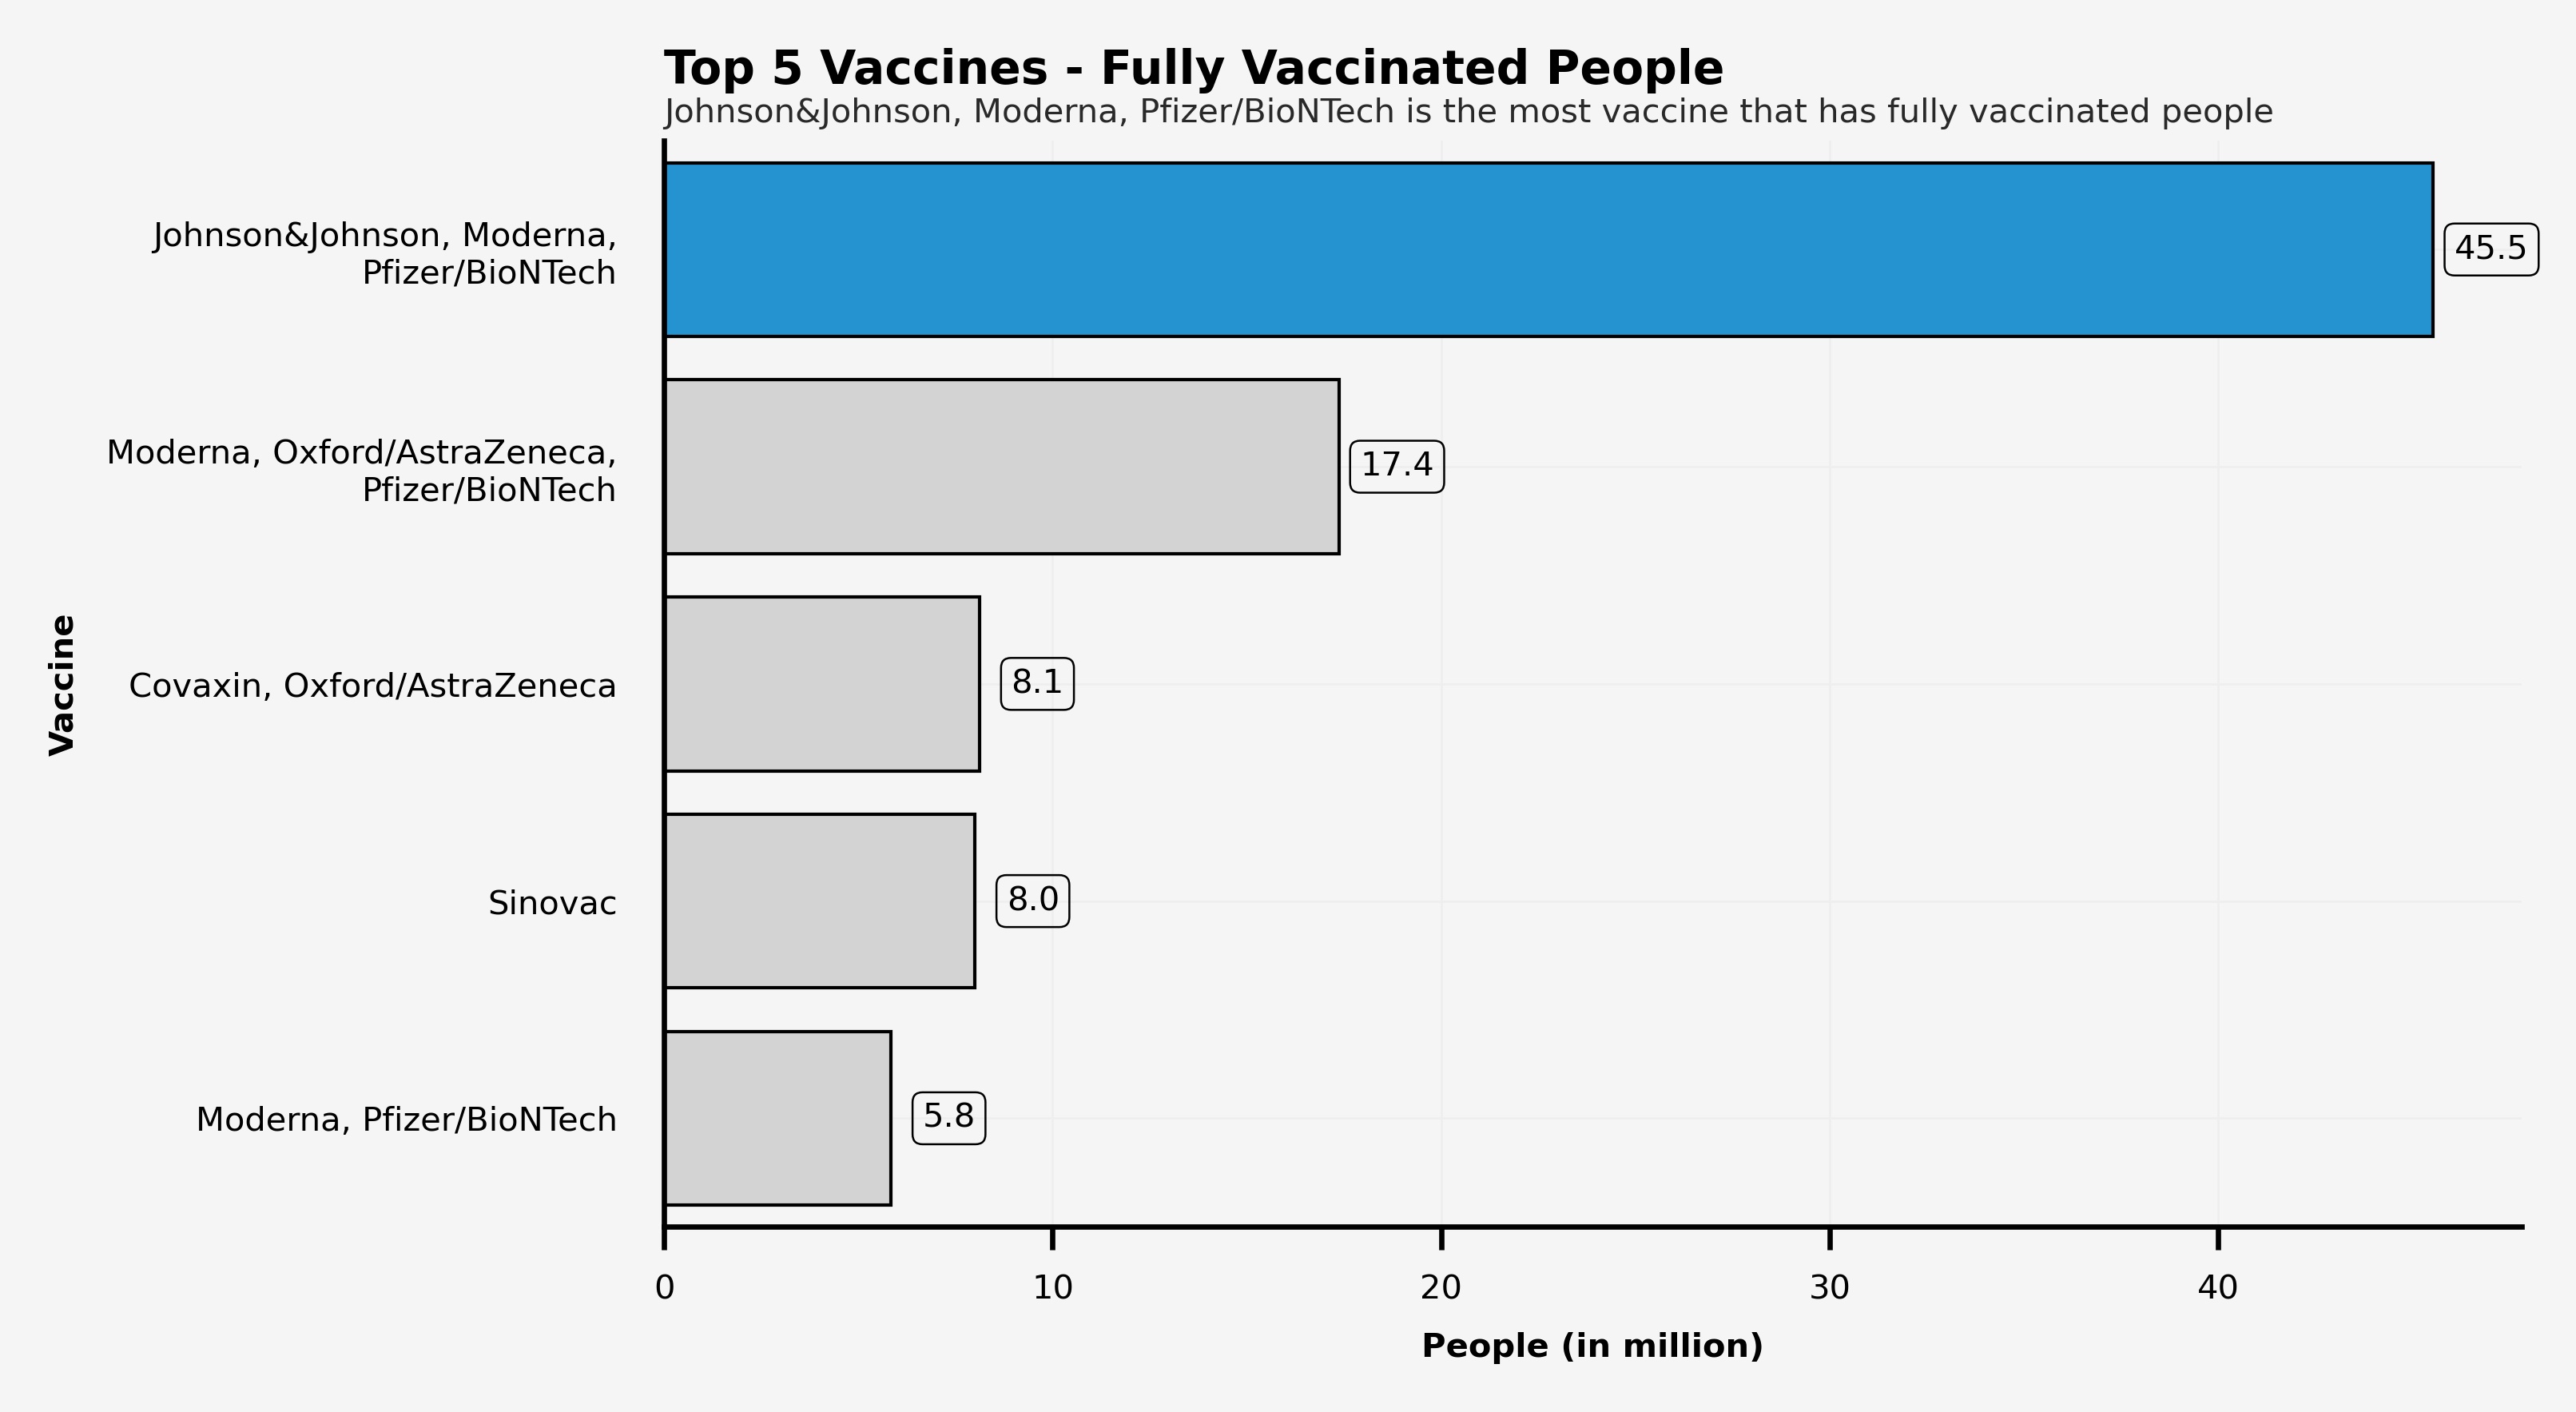

In [18]:
comb_vaccine = data_ld.groupby('vaccines')['people_fully_vaccinated'].sum().sort_values(ascending=False)
comb_vaccine = comb_vaccine/1000000
comb_vaccine = comb_vaccine[:5]

background_color = "#f6f5f5"
color_map = ["lightgray" for _ in range(26)]
color_map[0] = "#2693d1"
sns.set_palette(sns.color_palette(color_map))

plt.rcParams['figure.dpi'] = 600
fig = plt.figure(figsize=(5, 3), facecolor='#f6f5f5')
gs = fig.add_gridspec(1, 1)
gs.update(wspace=0, hspace=0)
ax0 = fig.add_subplot(gs[0, 0])
ax0.set_facecolor(background_color)
for s in ["right", "top"]:
    ax0.spines[s].set_visible(False)
ax0.tick_params(axis = "y", which = "both", left = False)

ax0.text(0, -0.72, 'Top 5 Vaccines - Fully Vaccinated People', color='black', fontsize=7, ha='left', va='bottom', weight='bold')
ax0.text(0, -0.7, 'Johnson&Johnson, Moderna, Pfizer/BioNTech is the most vaccine that has fully vaccinated people', 
         color='#292929', fontsize=5, ha='left', va='top')
ax0_sns = sns.barplot(ax=ax0, y=comb_vaccine.index, x=comb_vaccine, zorder=2, orient='h', 
                      linewidth=0.5, edgecolor='black', saturation=1)
ax0_sns.set_xlabel("People (in million)",fontsize=5, weight='bold')
ax0_sns.set_ylabel("Vaccine",fontsize=5, weight='bold')
ax0.grid(which='major', axis='x', zorder=0, color='#EEEEEE', lw=0.3)
ax0.grid(which='major', axis='y', zorder=0, color='#EEEEEE', lw=0.3)
ax0_sns.tick_params(labelsize=5)
ax0.set_yticklabels([textwrap.fill(e, 35) for e in comb_vaccine.index])

for p in ax0.patches:
    value = f'{p.get_width():,.1f}'
    x = p.get_x() + p.get_width() + 1.5
    y = p.get_y() + p.get_height() / 2 
    ax0.text(x, y, value, ha='center', va='center', fontsize=5, 
            bbox=dict(facecolor='none', edgecolor='black', boxstyle='round', linewidth=0.3))

plt.show()

`Johnson&Johnson, Moderna, Pfizer/BioNTech` is still consistent to be the highest multiple vaccines combination even for fully vaccinated people. Contrast from people vaccinated, fully vacinnated people for countries using `Moderna, Oxford/AstraZeneca, Pfizer/BioNTech` vaccines combination are a lot higher than `Covaxin, Oxford/AstraZeneca` that is used in `India`. `Moderna, Pfizer/BioNTech` emerged to the 4th position above `Sinovac`, this may the result of high fully vaccinated people in `Israel`. Six countries that use `Moderna, Pfizer/BioNTech` are `Foeroe Islands`, `Israel`, `Liechtenstein`, `Portugal`, `Singapore` and `Switzerland`.

[back to top](#table-of-contents)
<a id="4"></a>
## 4. Countries with High Fully Vaccinated People

Fully vaccinated people in a country can be seen in two categories:
* Vaccination amount *(table: People Fully Vaccinated)*
* Percentage of total population *(table: People Fully Vaccinated per hundred)*

<a id="4.1"></a>
### 4.1. Vaccination Amount
There are 3 countries that has passed 5 million of fully vaccinated people, they are `United States`, `India` and `Turkey`:
* `United States` is the country with the highest fully vaccinated people mentioned before. It has fully vaccinated `45.5 million` of its citizen but compared to  total population, it only has fully vaccinated `13.6%` of its citizen, is still far from 50% or even 100%. `United States` started their vaccination since December 2020, and show an increasing daily vaccination to its citizen and reaching the peak at `2.5 million` per day. New President `Joe Biden` announced a new goal of having 200 million Covid vaccination shots being distributed within his first 100 days in office. The `United States` government has a deal with Johnson & Johnson for delivery of 200 million doses and also with Pfizer and Moderna for a combined 600 million doses which is enough to inoculate 300 million Americans, since both the Pfizer and Moderna vaccines require two shots given three to four weeks apart.
* In the second place there is `India`, it has fully vaccinated `8.1 million` of its total population but it is still consider small when it compored with its total population of `1.4 billion`. It started its vaccination in mid January 2021 and reaching its peak on March 2021 at `2.2 million` per day. Numbers of vaccination is increased rapidly since the beginning of March 2021 due to the expanded eligibility criteria to include people over 60 and those who are between 45 and 59 but have other illnesses. The government has now announced that from 1 April, the jab will be available to anyone aged 45 years and above which will increased the number of vaccinations in the future.
* `Turkey` is in the third place with `5.5 million` people have been fully vaccinated. Compared to its total population, `Turkey` has fully vaccinated `6.5%` of its total  population. It started its vacination since mid January 2021 and reaching its peak at `0.4 million` per day. The country administers shots both at hospitals and through a nationwide network of neighborhood clinics, while elderly citizens who cannot leave home due to their old age are vaccinated at home by health care crews. Turkey boasts a successful vaccine logistics system that allows the fast and safe shipment to provinces.

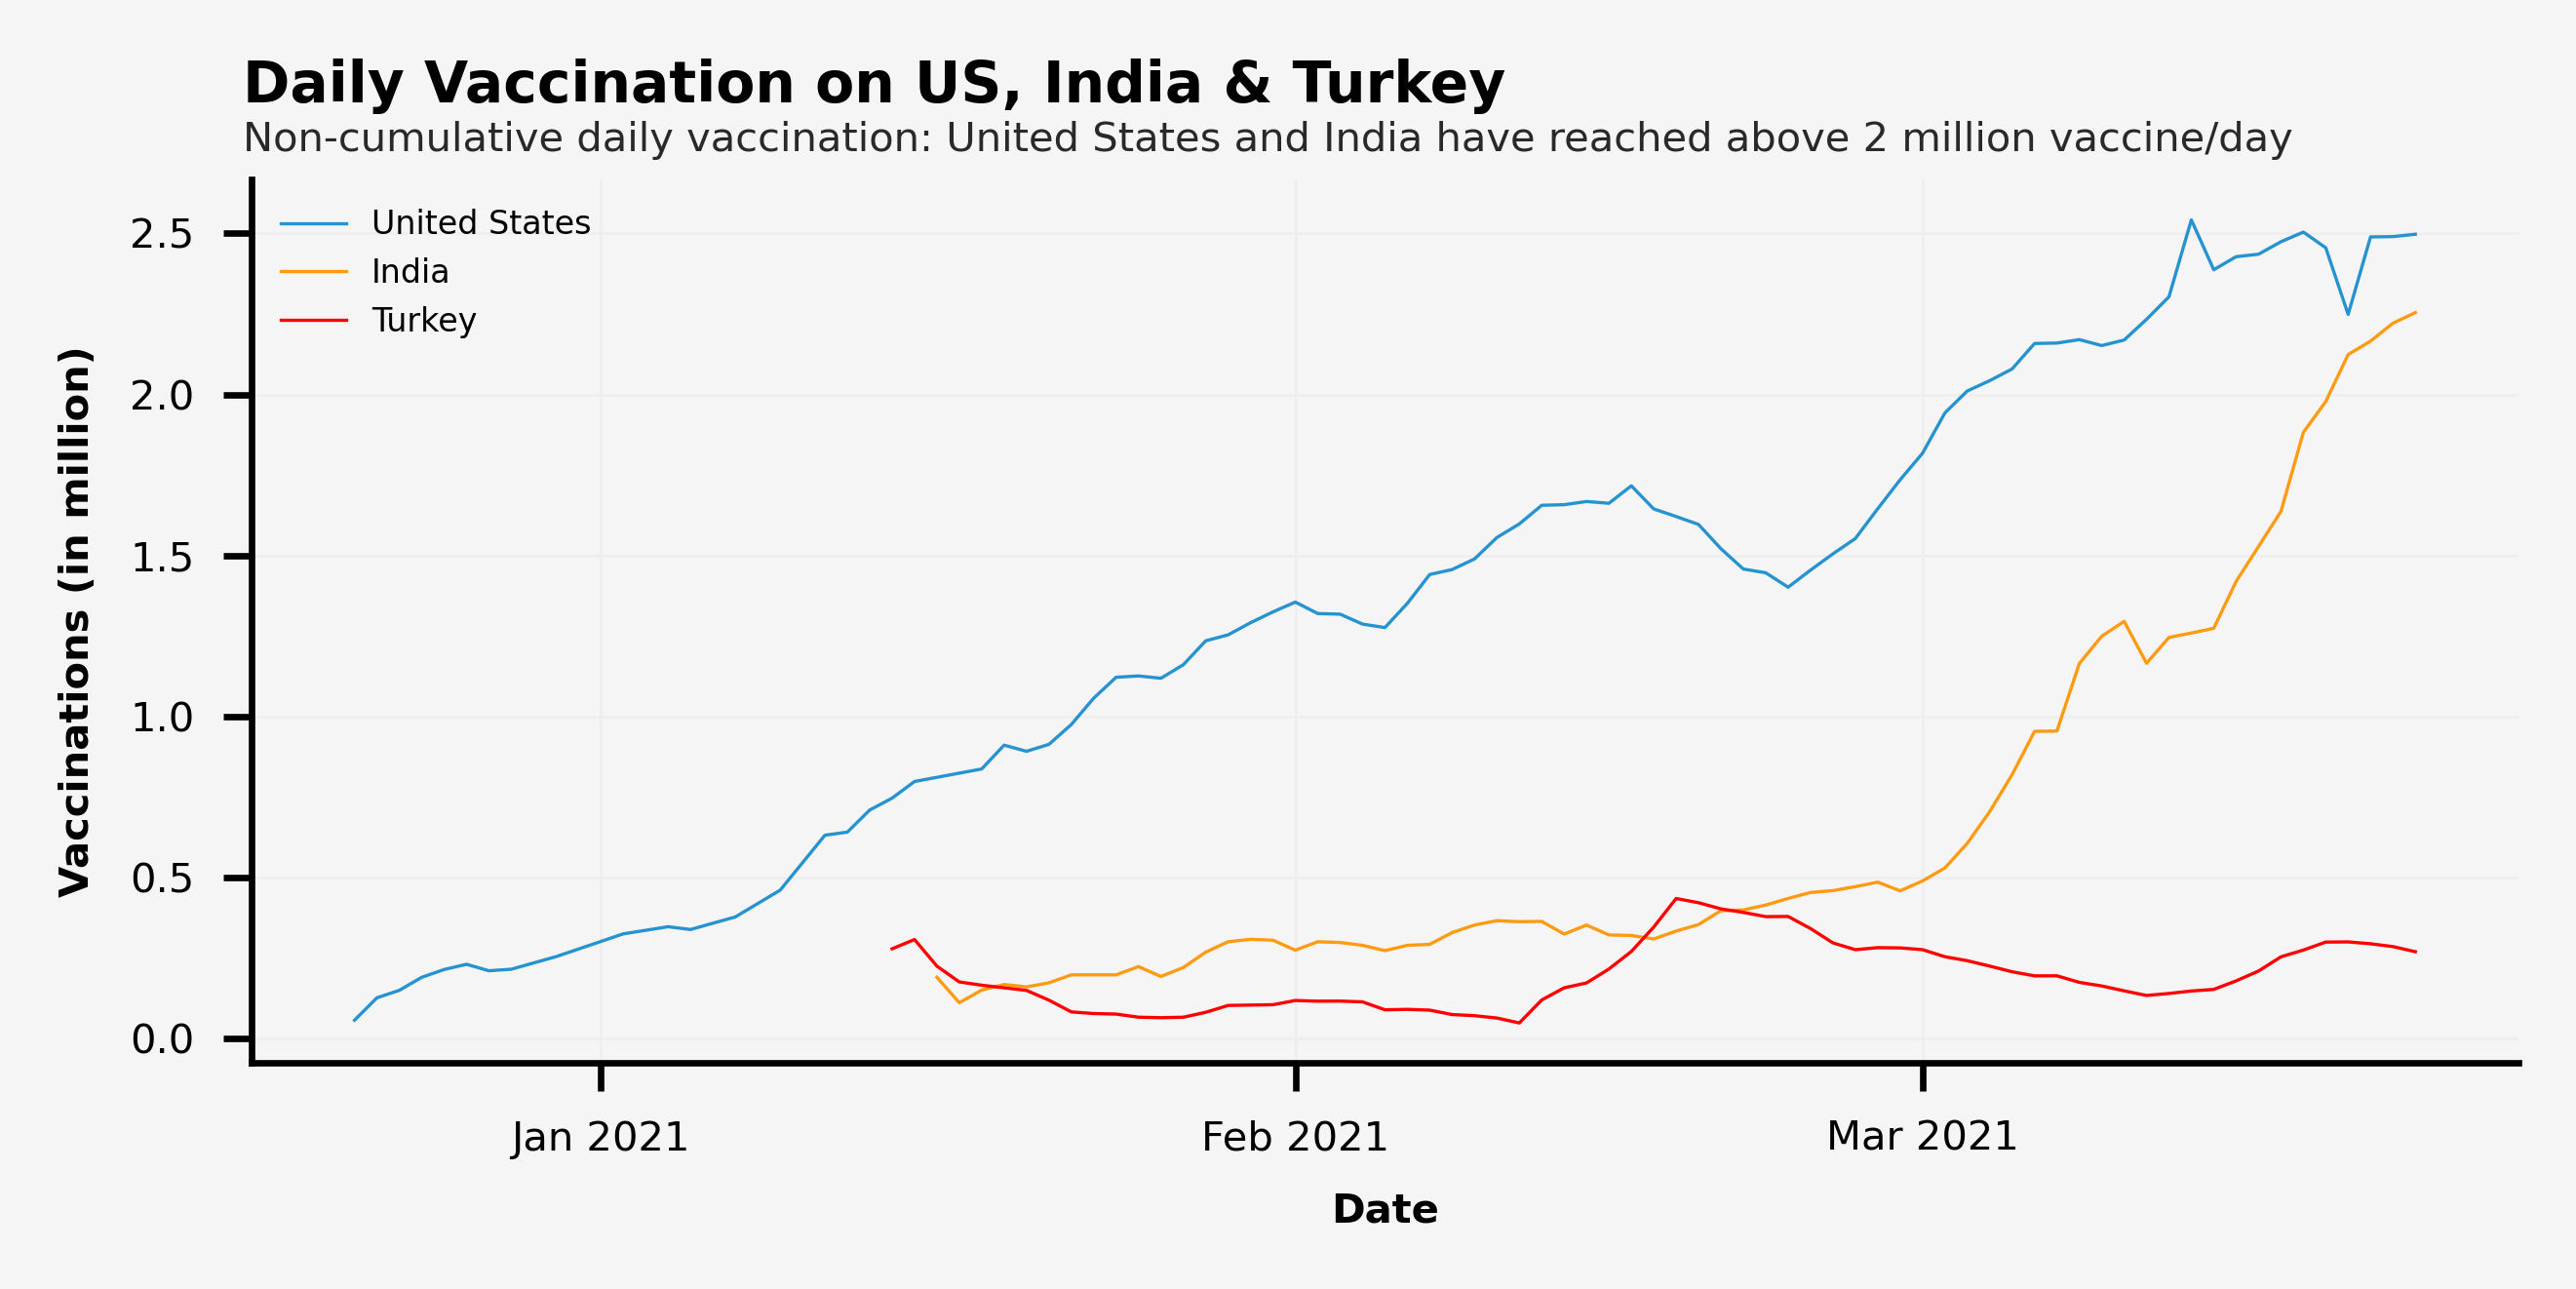

In [19]:
united_states = data[data['country']=='United States']
india = data[data['country']=='India']
turkey = data[data['country']=='Turkey']

background_color = "#f6f5f5"

years = mdates.YearLocator()
months = mdates.MonthLocator()
years_fmt = mdates.DateFormatter('%b %Y')

plt.rcParams['figure.dpi'] = 600
fig = plt.figure(figsize=(5, 2), facecolor='#f6f5f5')
gs = fig.add_gridspec(1, 1)
gs.update(wspace=0, hspace=0)
ax0 = fig.add_subplot(gs[0, 0])
ax0.set_facecolor(background_color)
for s in ["right", "top"]:
    ax0.spines[s].set_visible(False)
    
# format the ticks
ax0.xaxis.set_major_locator(months)
ax0.xaxis.set_major_formatter(years_fmt)

ax0.text(pd.Timestamp('2020-12-16'), 2.87, 'Daily Vaccination on US, India & Turkey', color='black', fontsize=7, ha='left', va='bottom', weight='bold')
ax0.text(pd.Timestamp('2020-12-16'), 2.85, 'Non-cumulative daily vaccination: United States and India have reached above 2 million vaccine/day', 
         color='#292929', fontsize=5, ha='left', va='top')
ax0_sns = sns.lineplot(ax=ax0, x=united_states['date'], y=united_states['daily_vaccinations']/1000000, color='#2693d1',zorder=2, linewidth=0.4)
ax0_sns = sns.lineplot(ax=ax0, x=india['date'], y=india['daily_vaccinations']/1000000, zorder=2, color='#ff9a13', linewidth=0.4)
ax0_sns = sns.lineplot(ax=ax0, x=turkey['date'], y=turkey['daily_vaccinations']/1000000, zorder=2, color='#FF0000', linewidth=0.4)
ax0_sns.set_xlabel("Date",fontsize=5, weight='bold')
ax0_sns.set_ylabel("Vaccinations (in million)",fontsize=5, weight='bold')
ax0.grid(which='major', axis='x', zorder=0, color='#EEEEEE', lw=0.3)
ax0.grid(which='major', axis='y', zorder=0, color='#EEEEEE', lw=0.3)
ax0_sns.tick_params(labelsize=5)
ax0.legend(['United States', 'India', 'Turkey'], prop={'size': 4}, frameon=False)

plt.show()

`United States` is leading the daily vaccination and showing an uptrend daily vaccination. `India` is catching up with `United States` though it is the last country that starts the vaccination program compared to `United States` and `Turkey`. `Turkey` daily vaccination is more flat compared to the others.

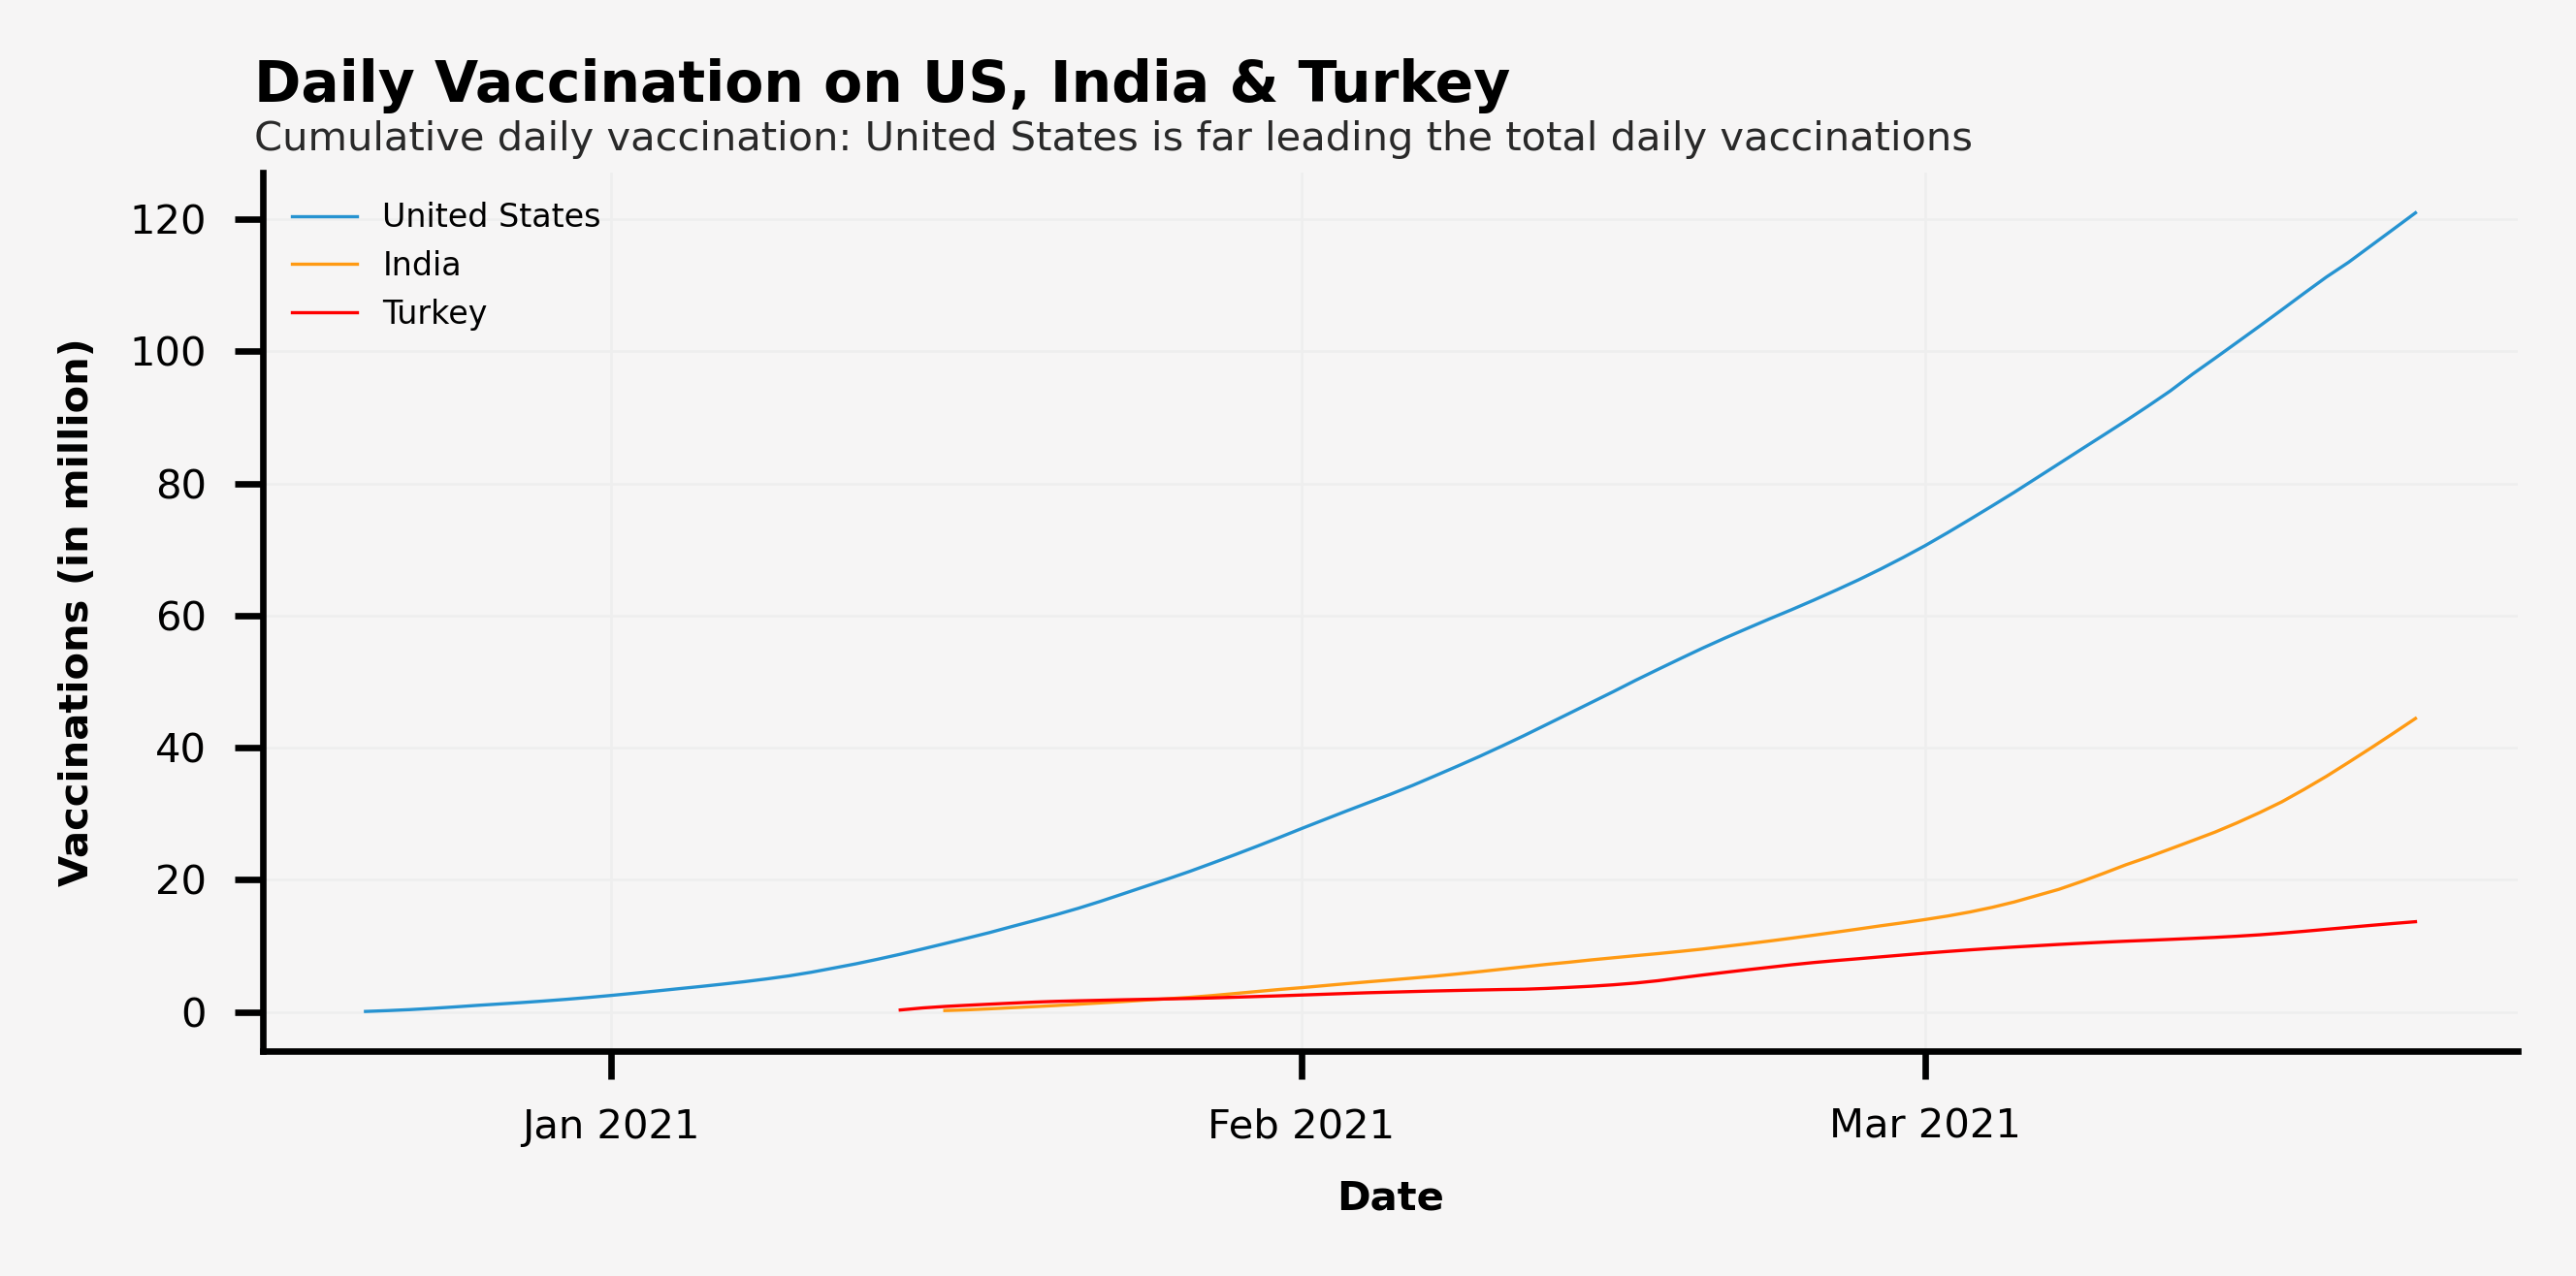

In [20]:
united_states = data[data['country']=='United States']
india = data[data['country']=='India']
turkey = data[data['country']=='Turkey']

background_color = "#f6f5f5"

years = mdates.YearLocator()
months = mdates.MonthLocator()
years_fmt = mdates.DateFormatter('%b %Y')

plt.rcParams['figure.dpi'] = 600
fig = plt.figure(figsize=(5, 2), facecolor='#f6f5f5')
gs = fig.add_gridspec(1, 1)
gs.update(wspace=0, hspace=0)
ax0 = fig.add_subplot(gs[0, 0])
ax0.set_facecolor(background_color)
for s in ["right", "top"]:
    ax0.spines[s].set_visible(False)
    
# format the ticks
ax0.xaxis.set_major_locator(months)
ax0.xaxis.set_major_formatter(years_fmt)

ax0.text(pd.Timestamp('2020-12-16'), 136, 'Daily Vaccination on US, India & Turkey', color='black', fontsize=7, ha='left', va='bottom', weight='bold')
ax0.text(pd.Timestamp('2020-12-16'), 135, 'Cumulative daily vaccination: United States is far leading the total daily vaccinations', 
         color='#292929', fontsize=5, ha='left', va='top')
ax0_sns = sns.lineplot(ax=ax0, x=united_states['date'], y=united_states['daily_vaccinations'].cumsum()/1000000, color='#2693d1',zorder=2, linewidth=0.4)
ax0_sns = sns.lineplot(ax=ax0, x=india['date'], y=india['daily_vaccinations'].cumsum()/1000000, zorder=2, color='#ff9a13', linewidth=0.4)
ax0_sns = sns.lineplot(ax=ax0, x=turkey['date'], y=turkey['daily_vaccinations'].cumsum()/1000000, zorder=2, color='#FF0000', linewidth=0.4)
ax0_sns.set_xlabel("Date",fontsize=5, weight='bold')
ax0_sns.set_ylabel("Vaccinations (in million)",fontsize=5, weight='bold')
ax0.grid(which='major', axis='x', zorder=0, color='#EEEEEE', lw=0.3)
ax0.grid(which='major', axis='y', zorder=0, color='#EEEEEE', lw=0.3)
ax0_sns.tick_params(labelsize=5)
ax0.legend(['United States', 'India', 'Turkey'], prop={'size': 4}, frameon=False)

plt.show()

As `United States` has started the vaccination program earlier and has an increased daily vaccination, it makes a big gap on cumulative daily vaccination. In March, `India` is showing a significant increased in cumulative daily vaccination as its daily vaccination is cathing up to the `United States`. `Turkey` shows a more flat cumulative daily vaccinations in line with its flat daily vaccination. 

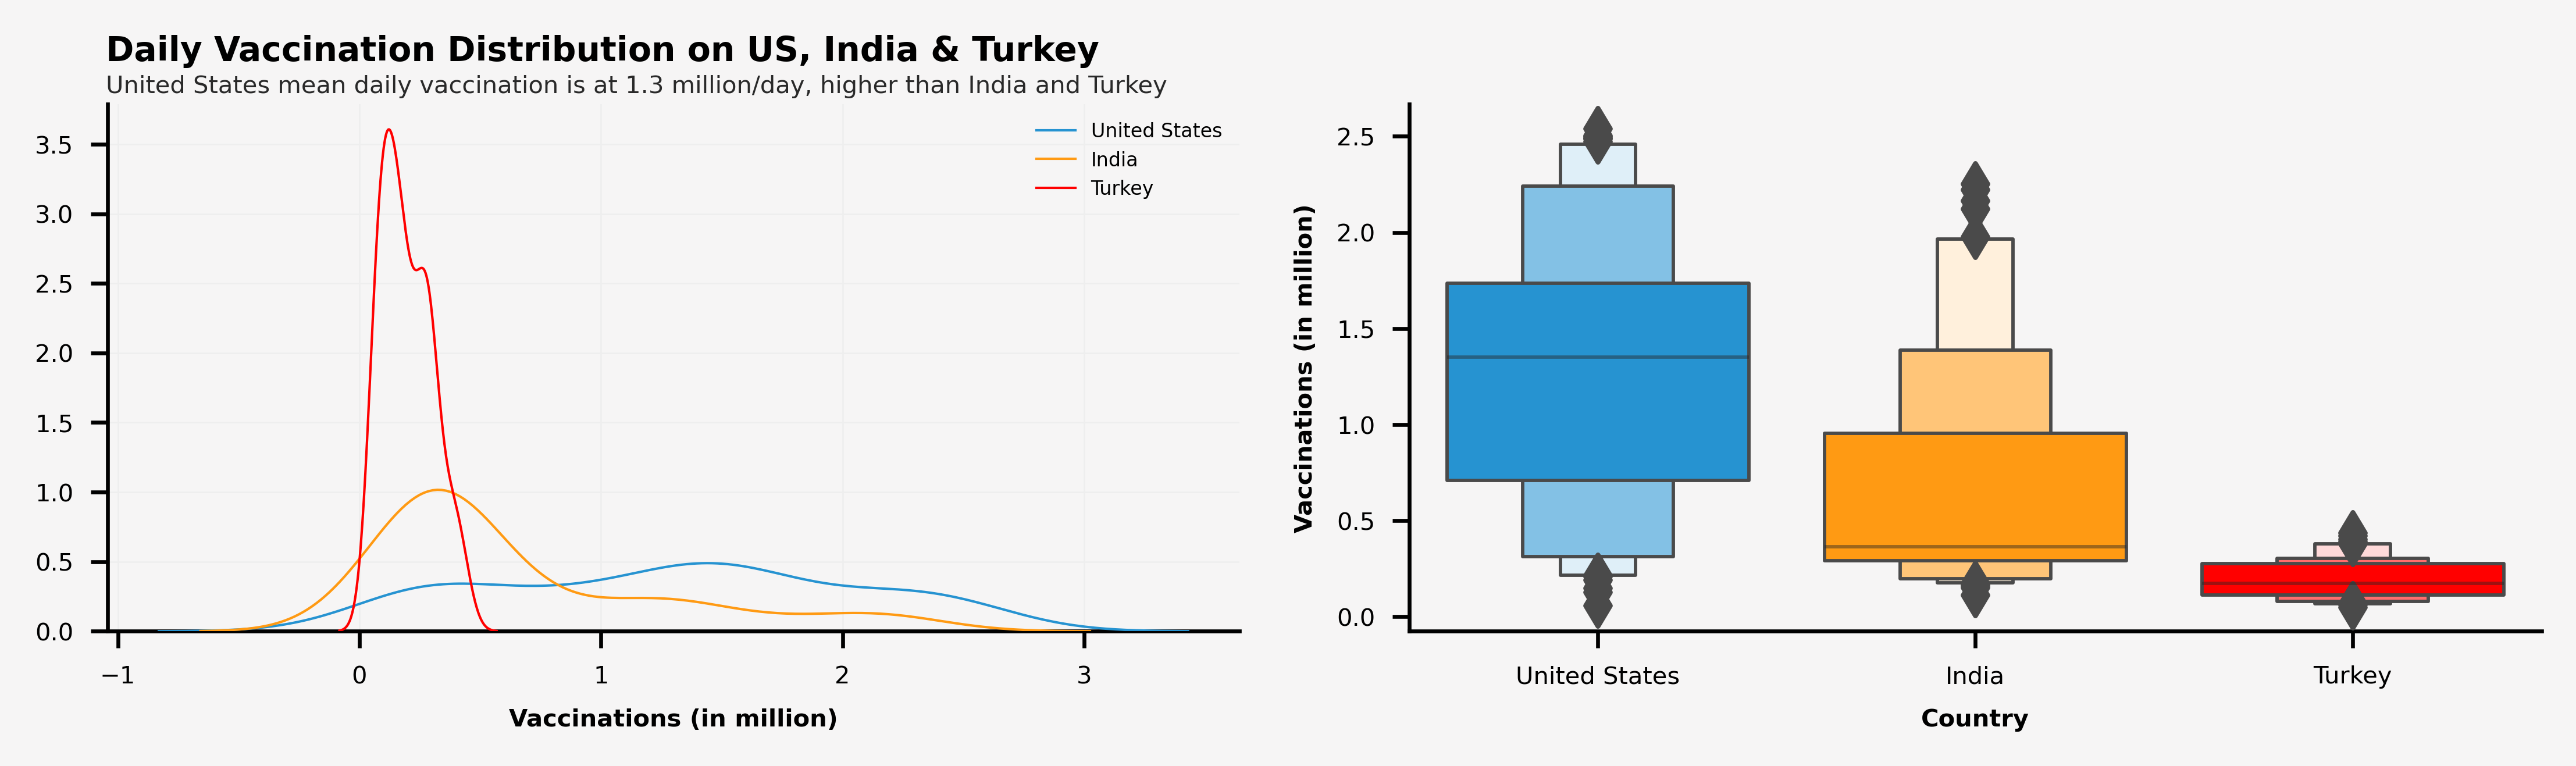

In [21]:
united_states = data[data['country']=='United States']
india = data[data['country']=='India']
turkey = data[data['country']=='Turkey']

background_color = "#f6f5f5"

color_map = ['#2693d1','#ff9a13','#FF0000']
sns.set_palette(sns.color_palette(color_map))

plt.rcParams['figure.dpi'] = 600
fig = plt.figure(figsize=(9, 2), facecolor='#f6f5f5')
gs = fig.add_gridspec(1, 2)
gs.update(wspace=0.15, hspace=0)
ax0 = fig.add_subplot(gs[0, 0])
ax0.set_facecolor(background_color)
for s in ["right", "top"]:
    ax0.spines[s].set_visible(False)

ax0.text(-1.05, 4.05, 'Daily Vaccination Distribution on US, India & Turkey', color='black', fontsize=7, ha='left', va='bottom', weight='bold')
ax0.text(-1.05, 4, 'United States mean daily vaccination is at 1.3 million/day, higher than India and Turkey', 
         color='#292929', fontsize=5, ha='left', va='top')
ax0_sns = sns.kdeplot(ax=ax0, x=united_states['daily_vaccinations']/1000000, zorder=3, linewidth=0.5)
ax0_sns = sns.kdeplot(ax=ax0, x=india['daily_vaccinations']/1000000, zorder=3, linewidth=0.5)
ax0_sns = sns.kdeplot(ax=ax0, x=turkey['daily_vaccinations']/1000000, zorder=3, linewidth=0.5)
ax0_sns.set_xlabel("Vaccinations (in million)",fontsize=5, weight='bold')
ax0_sns.set_ylabel("")
ax0_sns.tick_params(labelsize=5)
ax0.grid(which='major', axis='x', zorder=0, color='#EEEEEE', lw=0.3)
ax0.grid(which='major', axis='y', zorder=0, color='#EEEEEE', lw=0.3)
ax0.legend(['United States', 'India', 'Turkey'], prop={'size': 4}, frameon=False)

united_states = data[data['country']=='United States']
india = data[data['country']=='India']
turkey = data[data['country']=='Turkey']
combine = pd.concat([united_states, india, turkey], axis=0)

ax1 = fig.add_subplot(gs[0, 1])
ax1.set_facecolor(background_color)
for s in ["right", "top"]:
    ax1.spines[s].set_visible(False)
ax1_sns = sns.boxenplot(ax=ax1, x=combine['country'], y=combine['daily_vaccinations']/1000000, 
                        zorder=3, linewidth=0.7, saturation=1)
ax1_sns.set_xlabel("Country",fontsize=5, weight='bold')
ax1_sns.set_ylabel("Vaccinations (in million)",fontsize=5, weight='bold')
ax1_sns.tick_params(labelsize=5)
plt.show()

`United States` has a more flat distribution as it rapidly increased its daily vaccination. `India` recent increased on daily vaccination is reflected in the right tail on its distribution. `Turkey` has a more spike on daily vaccinations between 0 - 0.5 million as it has a flat daily vaccination. `United States` has the highest daily vaccinations median at `1.4` million/day followed by `India` with `0.36` million/day and `Turkey` with `0.17` million/day.

<a id="4.2"></a>
### 4.2. Percentage of Total Population
Right now, there are only 2 countries that have more than 50% in fully vaccinated their citizen, they are `Gibraltar` and `Israel`.

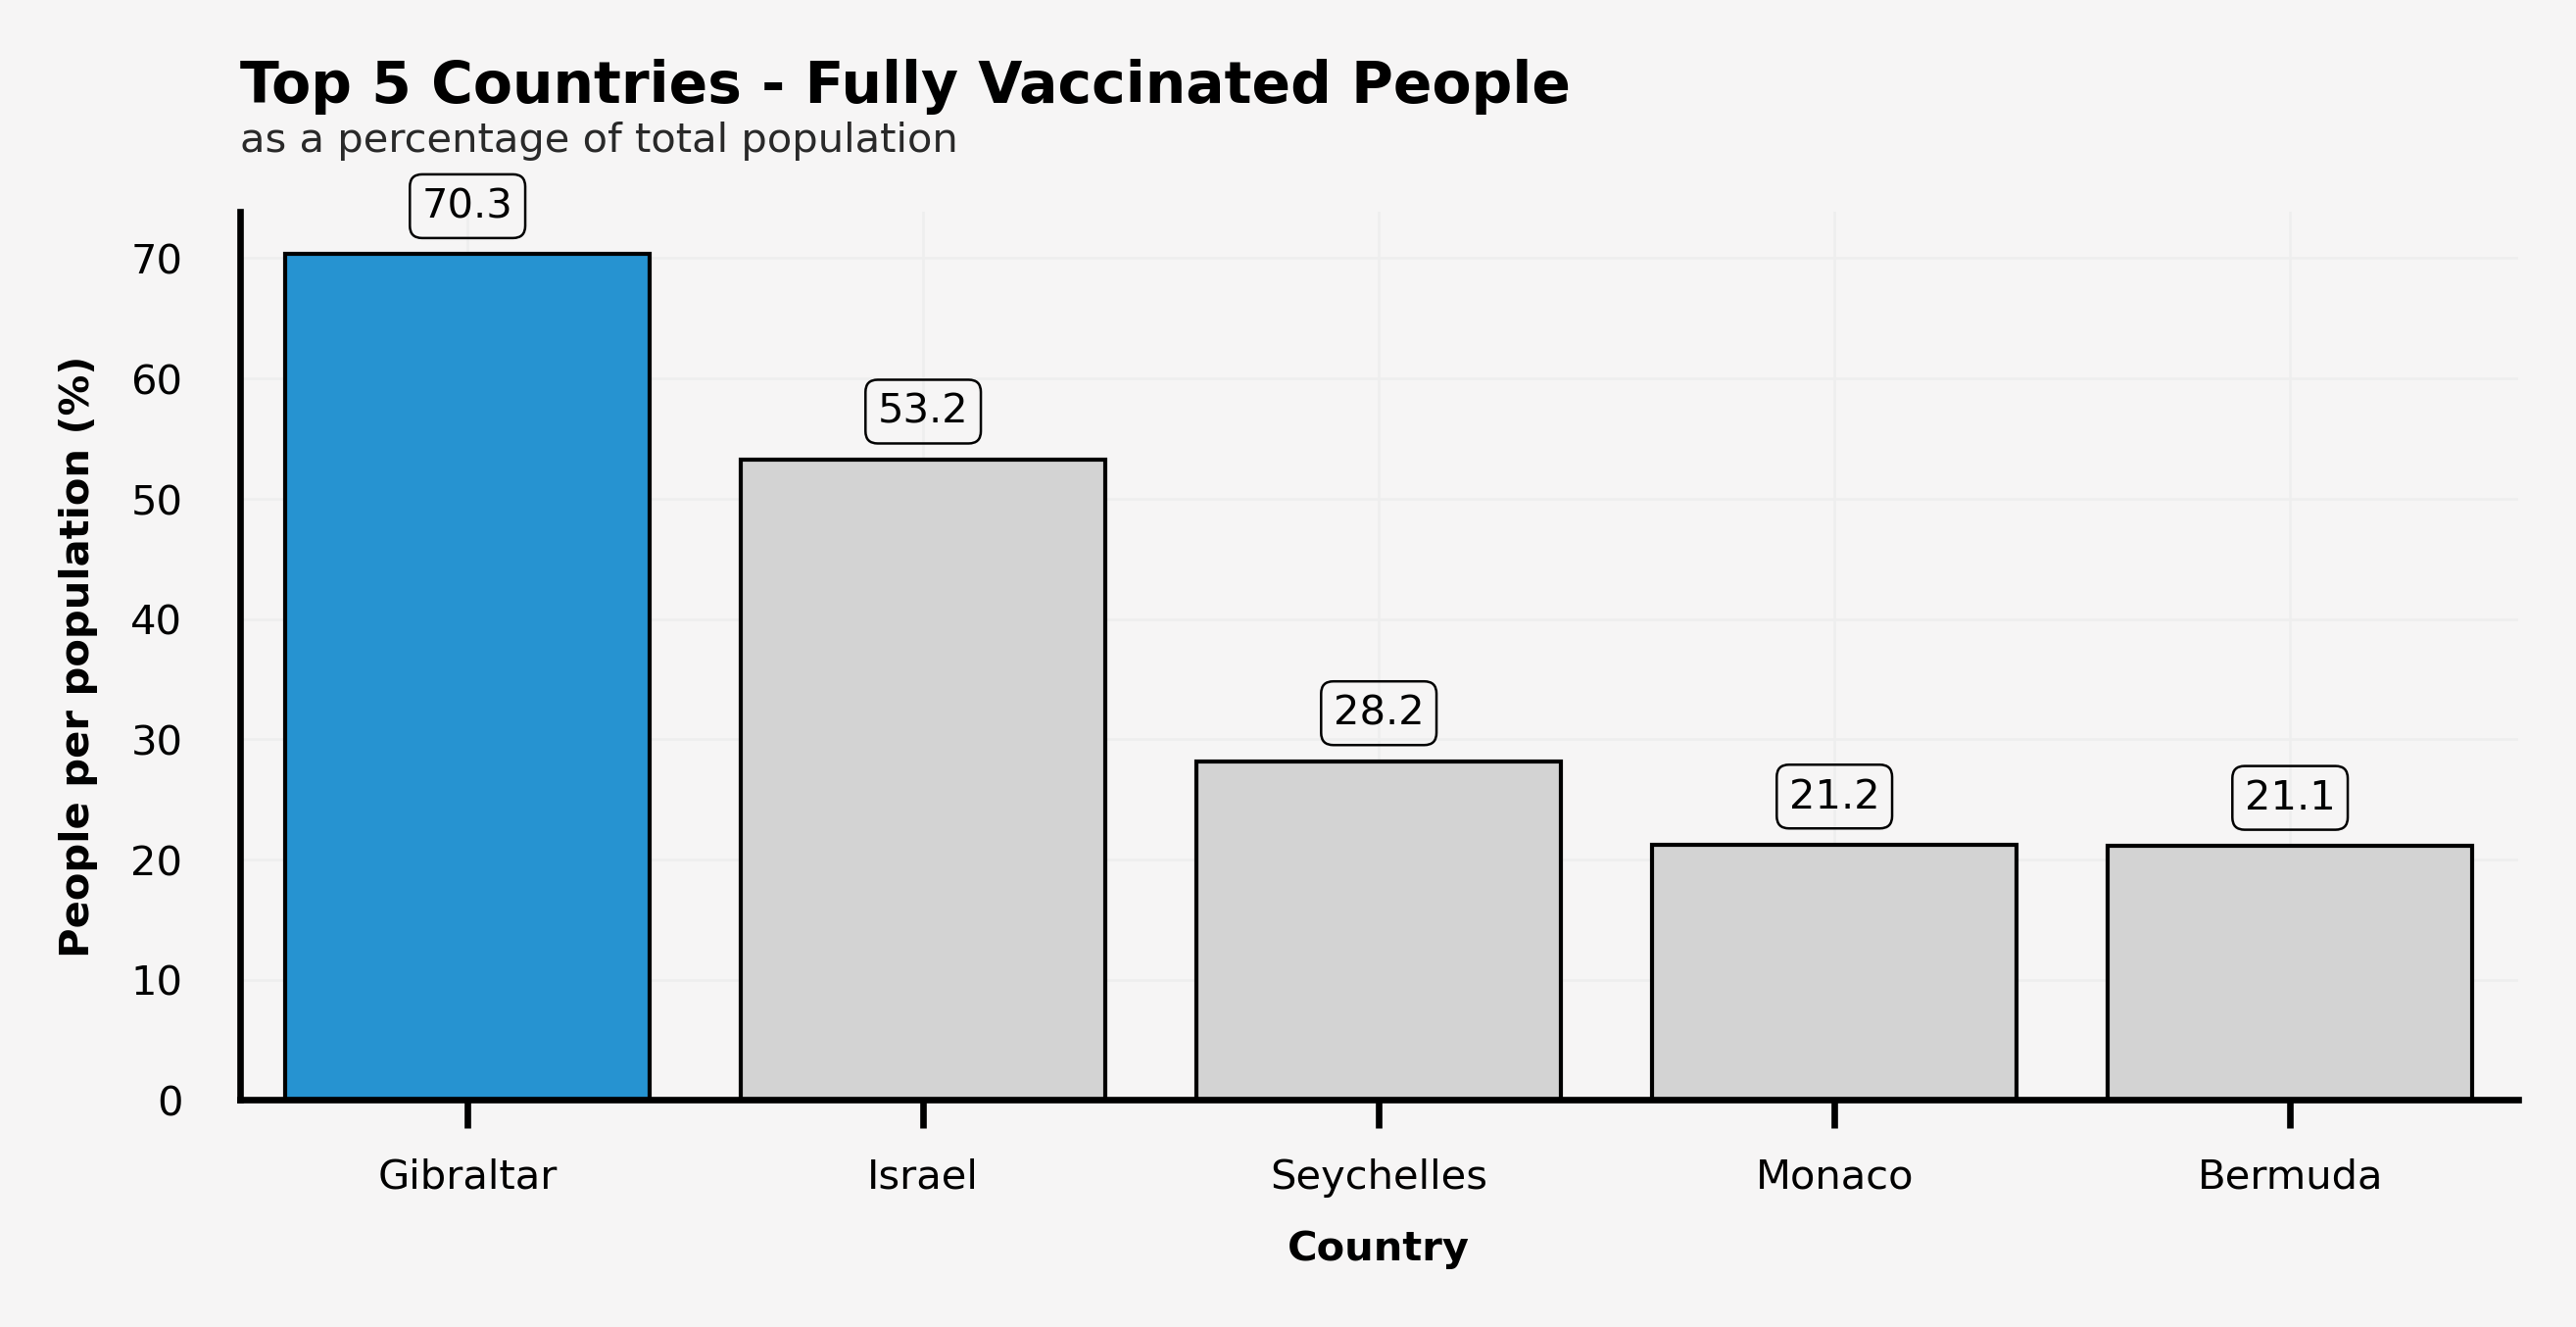

In [22]:
fully_vaccinated_5 = data_ld.sort_values('people_fully_vaccinated_per_hundred', ascending=False).reset_index(drop=True).loc[:4, :]

background_color = "#f6f5f5"
color_map = ["lightgray" for _ in range(5)]
color_map[0] = "#2693d1"
sns.set_palette(sns.color_palette(color_map))

plt.rcParams['figure.dpi'] = 600
fig = plt.figure(figsize=(5, 2), facecolor='#f6f5f5')
gs = fig.add_gridspec(1, 1)
gs.update(wspace=0, hspace=0)
ax0 = fig.add_subplot(gs[0, 0])
ax0.set_facecolor(background_color)
for s in ["right", "top"]:
    ax0.spines[s].set_visible(False)
ax0.tick_params(axis = "y", which = "both", left = False)

ax0.text(-0.5, 82, 'Top 5 Countries - Fully Vaccinated People', color='black', fontsize=7, ha='left', va='bottom', weight='bold')
ax0.text(-0.5, 81.4, 'as a percentage of total population', 
         color='#292929', fontsize=5, ha='left', va='top')
ax0_sns = sns.barplot(ax=ax0, x=fully_vaccinated_5['country'], y=fully_vaccinated_5['people_fully_vaccinated_per_hundred'], 
                      zorder=2, linewidth=0.5, edgecolor='black', saturation=1)
ax0_sns.set_xlabel("Country",fontsize=5, weight='bold')
ax0_sns.set_ylabel("People per population (%)",fontsize=5, weight='bold')
ax0.grid(which='major', axis='x', zorder=0, color='#EEEEEE', lw=0.3)
ax0.grid(which='major', axis='y', zorder=0, color='#EEEEEE', lw=0.3)
ax0_sns.tick_params(labelsize=5)

for p in ax0.patches:
    value = f'{p.get_height():,.1f}'
    x = p.get_x() + p.get_width() / 2
    y = p.get_y() + p.get_height() + 4
    ax0.text(x, y, value, ha='center', va='center', fontsize=5, 
            bbox=dict(facecolor='none', edgecolor='black', boxstyle='round', linewidth=0.3))

plt.show()

Except for `Israel`, top 5 fully vaccinated people countries have population below `100,000` people. `Gibraltar` has the highest percentage of fully vaccinated people with `70%` followed by `Israel` with `53.2%`. In the third place, there is `Seychelles` with `28.2%` followed by `Monaco` and `Bermuda` which both have a `21%` of its population have been fully vaccinated.

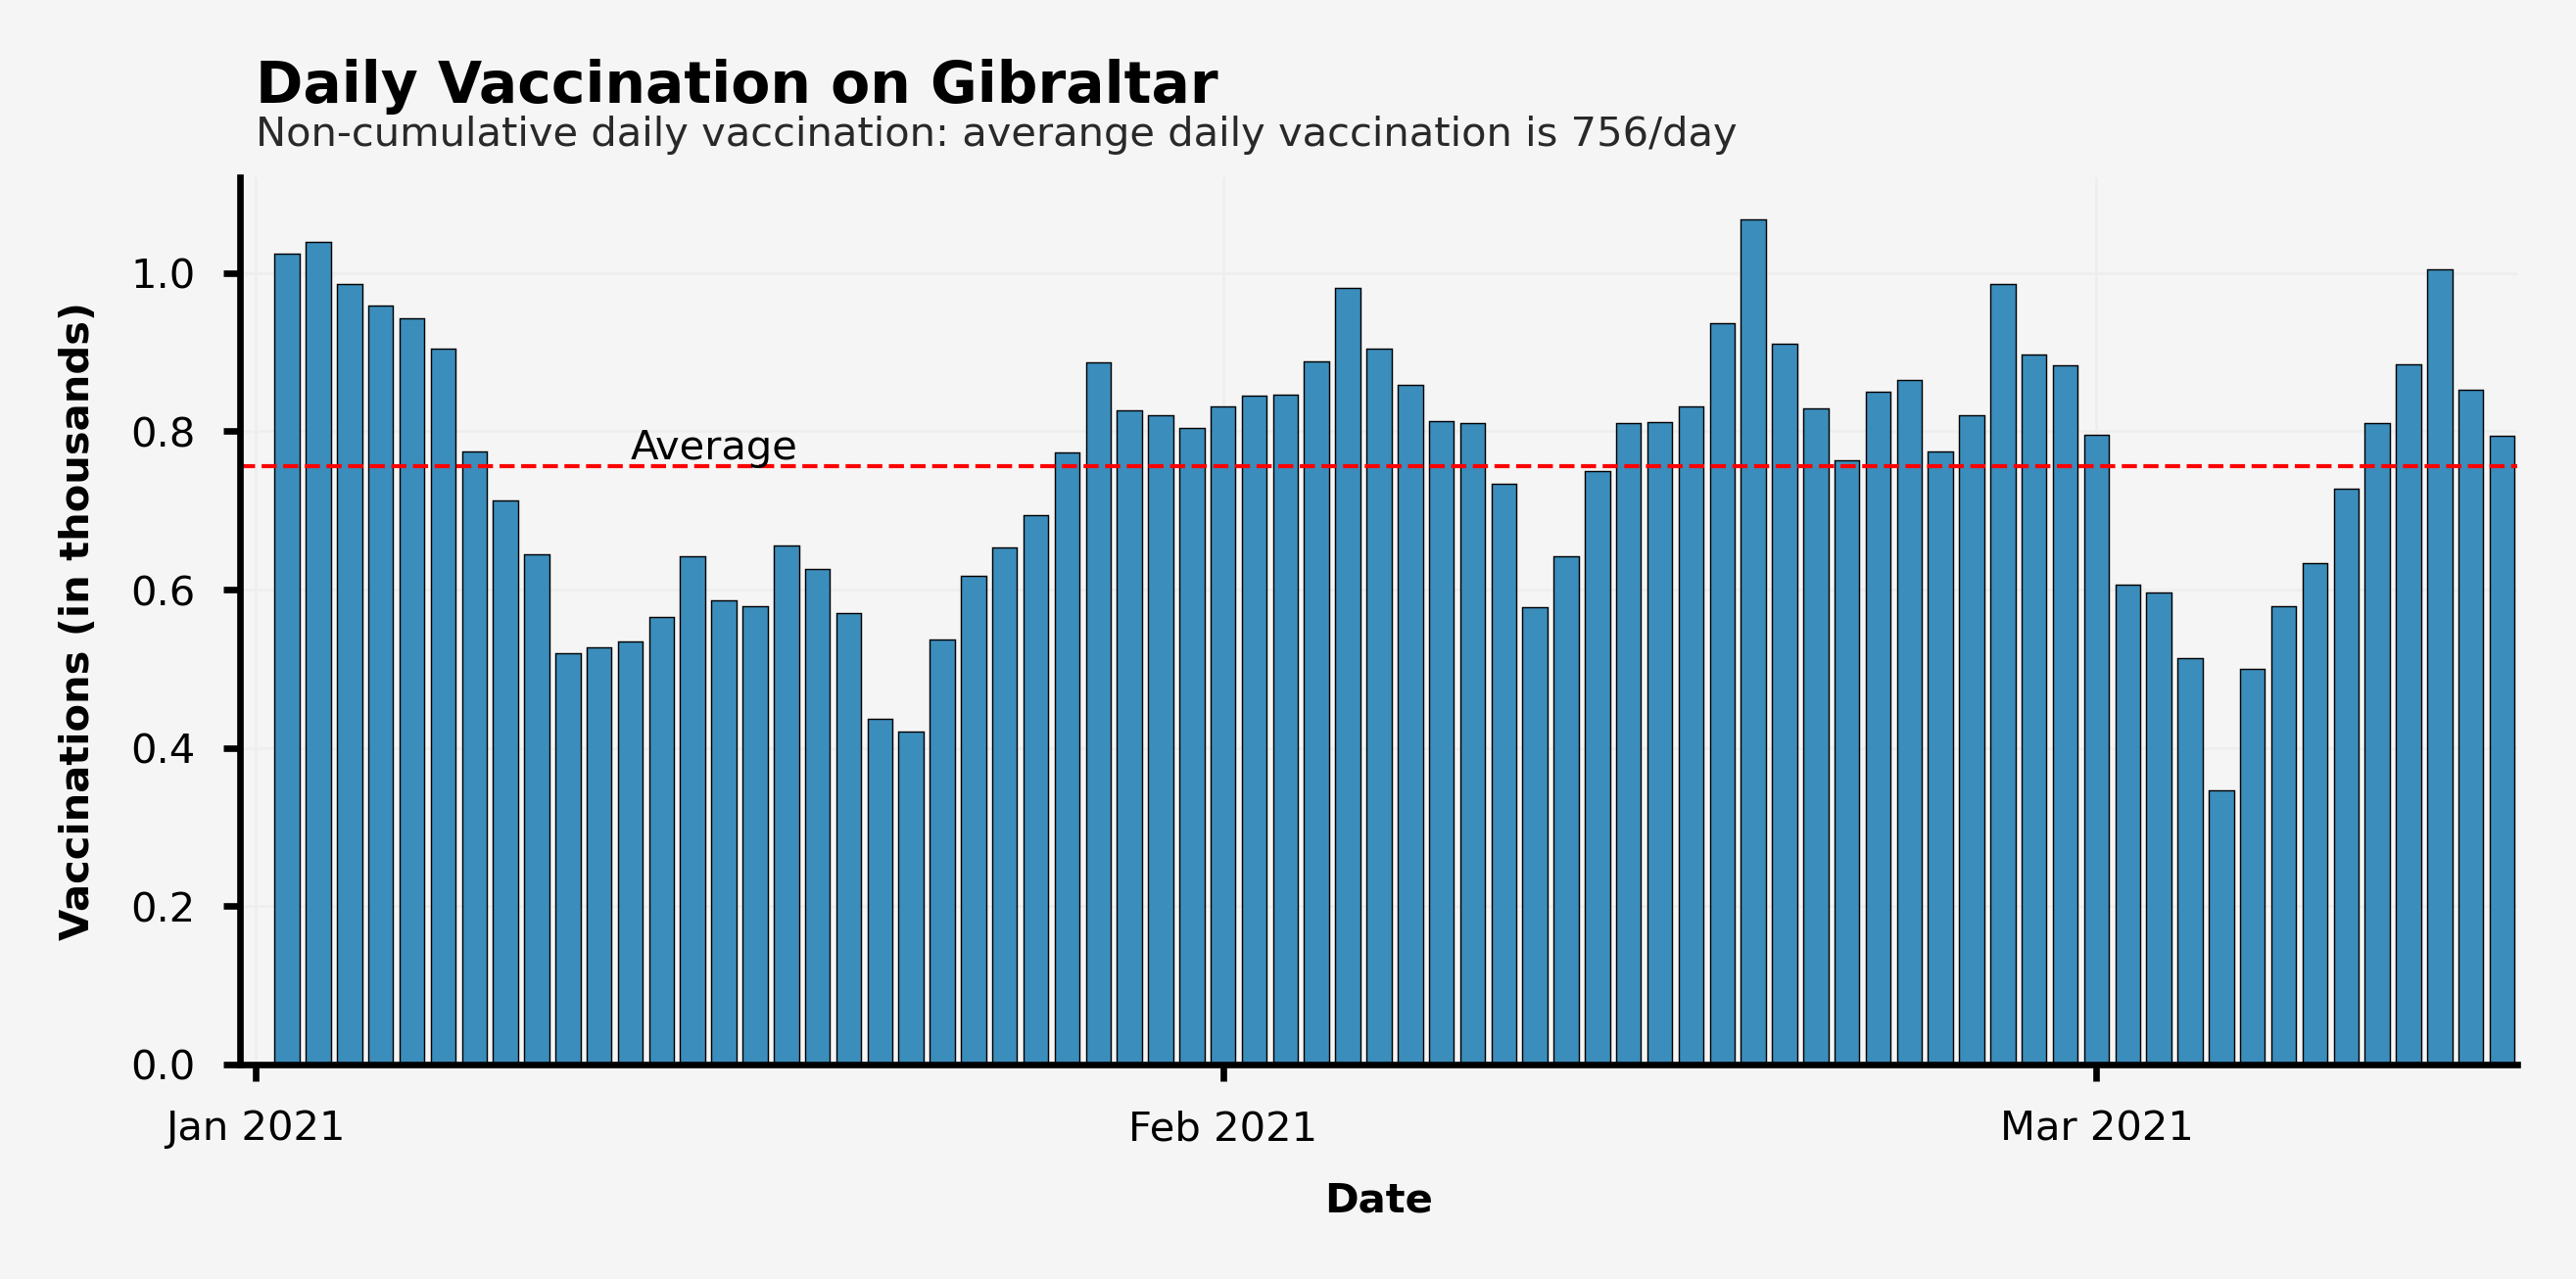

In [23]:
gibraltar = data[data['country']=='Gibraltar']
israel = data[data['country']=='Israel']

background_color = "#f6f5f5"

years = mdates.YearLocator()
months = mdates.MonthLocator()
years_fmt = mdates.DateFormatter('%b %Y')

plt.rcParams['figure.dpi'] = 600
fig = plt.figure(figsize=(5, 2), facecolor='#f6f5f5')
gs = fig.add_gridspec(1, 1)
gs.update(wspace=0, hspace=0)
ax0 = fig.add_subplot(gs[0, 0])
ax0.set_facecolor(background_color)
for s in ["right", "top"]:
    ax0.spines[s].set_visible(False)
    
# format the ticks
ax0.xaxis.set_major_locator(months)
ax0.xaxis.set_major_formatter(years_fmt)

ax0.text(pd.Timestamp('1970-1-1'), 1.201, 'Daily Vaccination on Gibraltar', color='black', fontsize=7, ha='left', va='bottom', weight='bold')
ax0.text(pd.Timestamp('1970-1-1'), 1.200, 'Non-cumulative daily vaccination: averange daily vaccination is 756/day', 
         color='#292929', fontsize=5, ha='left', va='top')
ax0_sns = sns.barplot(ax=ax0, x=gibraltar['date'], y=gibraltar['daily_vaccinations']/1000, zorder=2, color='#2693d1', linewidth=0.17, edgecolor='black')
plt.axhline(np.mean(gibraltar['daily_vaccinations']/1000), color='red', linewidth=0.5, linestyle="--")
ax0_sns.set_xlabel("Date",fontsize=5, weight='bold')
ax0_sns.set_ylabel("Vaccinations (in thousands)",fontsize=5, weight='bold')
ax0.grid(which='major', axis='x', zorder=0, color='#EEEEEE', lw=0.3)
ax0.grid(which='major', axis='y', zorder=0, color='#EEEEEE', lw=0.3)
ax0_sns.tick_params(labelsize=5)

ax0.tick_params('both', length=2, which='major', labelsize=5)
months = mdates.MonthLocator()
ax0.xaxis.set_major_locator(months)
ax0.set_xticklabels(['Jan 2021', 'Feb 2021', 'Mar 2021'])

ax0.annotate("Average", 
             xy=(np.datetime64("1970-01-13"), 0.765), 
             xytext=(np.datetime64("1970-01-13"), 0.765), 
             fontsize=5)

plt.show()

`Gibraltar` is a British Overseas Territory located at the southern tip of the Iberian Peninsula. It home to over 35,000 people, primarily Gibraltarians. It has successfully fully vaccinated `70.3%` of its citizens. Dubbed “Operation Freedom”, Gibraltar’s vaccination campaign is among the fastest in Europe, and its success is due to a combination of factors: the uninterrupted supply of vaccines from the U.K., its small population and its tiny geography. Highest daily vaccination is at `1,068 people/day` with average of `756 people/day`. The vast majority of vaccines being administered in Gibraltar are manufactured by Pfizer/BioNTech, with a small number of jabs produced by AstraZeneca which are reserved for people who can’t get Pfizer’s jab for medical reasons. Gibraltar is not only vaccinating its own residents. About 10,000 Spanish nationals who are registered as frontier workers are eligible for a jab too.

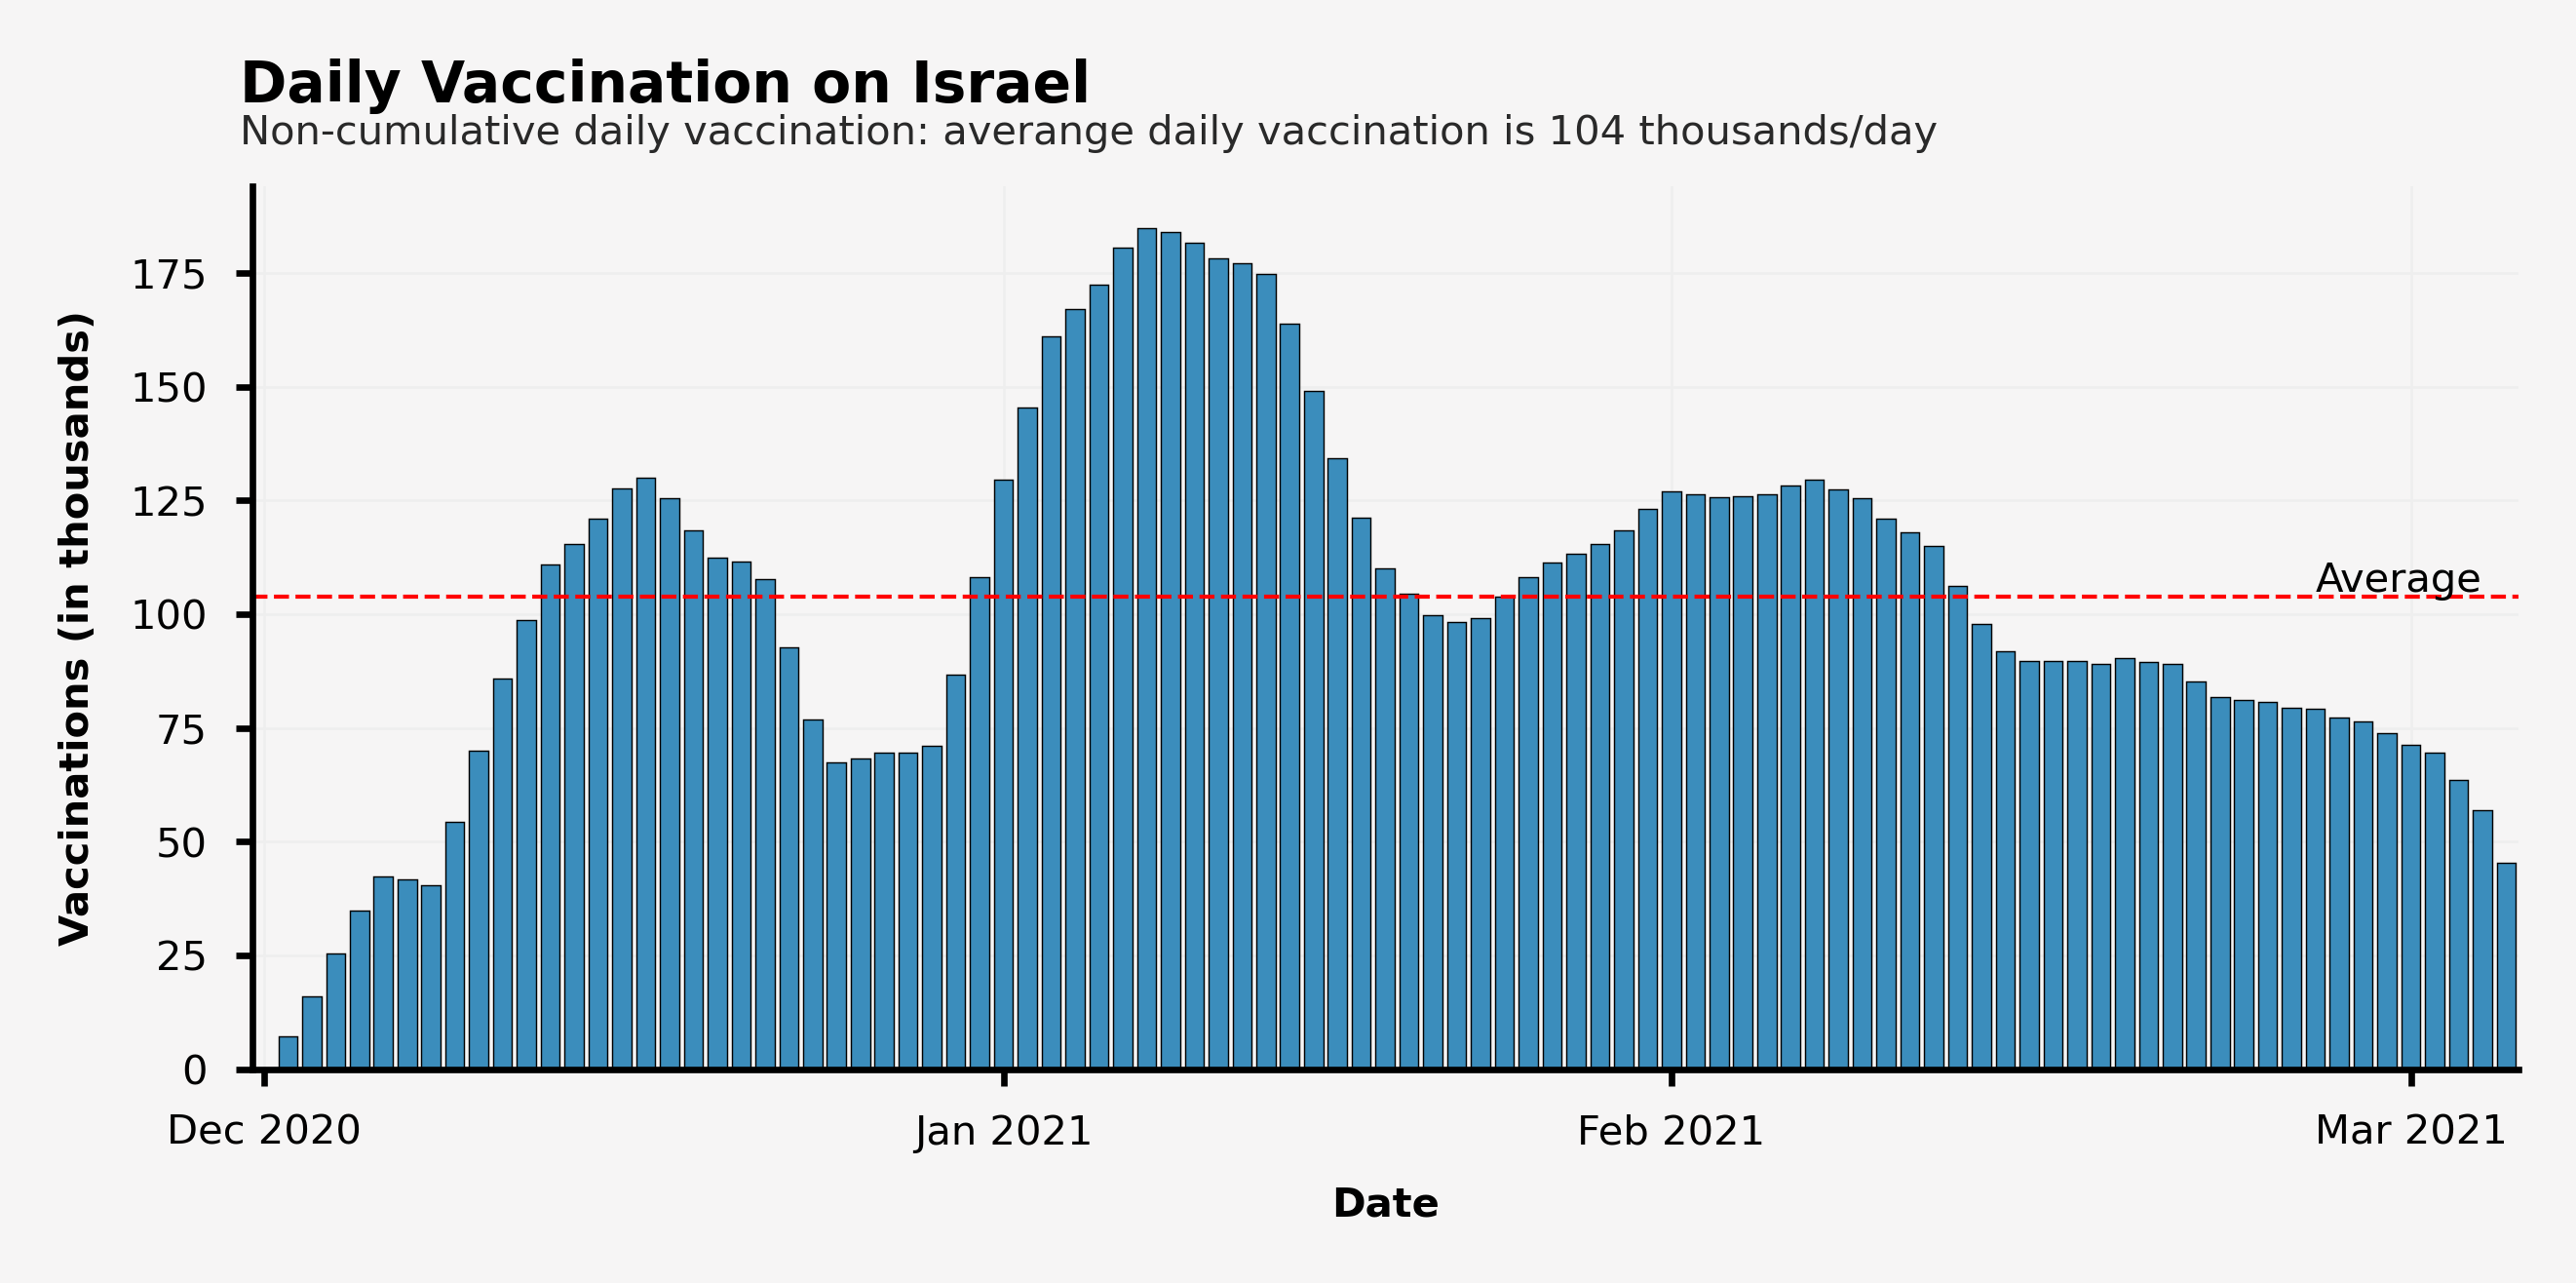

In [24]:
israel = data[data['country']=='Israel']

background_color = "#f6f5f5"

years = mdates.YearLocator()
months = mdates.MonthLocator()
years_fmt = mdates.DateFormatter('%b %Y')

plt.rcParams['figure.dpi'] = 600
fig = plt.figure(figsize=(5, 2), facecolor='#f6f5f5')
gs = fig.add_gridspec(1, 1)
gs.update(wspace=0, hspace=0)
ax0 = fig.add_subplot(gs[0, 0])
ax0.set_facecolor(background_color)
for s in ["right", "top"]:
    ax0.spines[s].set_visible(False)
    
# format the ticks
ax0.xaxis.set_major_locator(months)
ax0.xaxis.set_major_formatter(years_fmt)

ax0.text(pd.Timestamp('1969-12-31'), 210, 'Daily Vaccination on Israel', color='black', fontsize=7, ha='left', va='bottom', weight='bold')
ax0.text(pd.Timestamp('1969-12-31'), 210, 'Non-cumulative daily vaccination: averange daily vaccination is 104 thousands/day', 
         color='#292929', fontsize=5, ha='left', va='top')
ax0_sns = sns.barplot(ax=ax0, x=israel['date'], y=israel['daily_vaccinations']/1000, zorder=2, color='#2693d1', linewidth=0.17, edgecolor='black')
plt.axhline(np.mean(israel['daily_vaccinations'])/1000, color='red', linewidth=0.5, linestyle="--")
ax0_sns.set_xlabel("Date",fontsize=5, weight='bold')
ax0_sns.set_ylabel("Vaccinations (in thousands)",fontsize=5, weight='bold')
ax0.grid(which='major', axis='x', zorder=0, color='#EEEEEE', lw=0.3)
ax0.grid(which='major', axis='y', zorder=0, color='#EEEEEE', lw=0.3)
ax0_sns.tick_params(labelsize=5)

ax0.tick_params('both', length=2, which='major', labelsize=5)
months = mdates.MonthLocator()
ax0.xaxis.set_major_locator(months)
ax0.set_xticklabels(['Dec 2020', 'Jan 2021', 'Feb 2021', 'Mar 2021'])

ax0.annotate("Average", 
             xy=(np.datetime64("1970-03-28"), 105), 
             xytext=(np.datetime64("1970-03-28"), 105), 
             fontsize=5)

plt.show()

`Israel` home to over `8.6 million` people which contribute around `0.11%` of world population. It has fully vaccinated `53.2%` and reached its highest daily vaccination at `185 thousands/day`. Its success come from: a well-run universal health-care system, a geographically small country and their emphasises being fast rather than sticking strictly to a priority order of who gets the vaccine first. There is a downturn in daily vaccination since February 2021 and starting even lower again since March 2021. Israeli public health officials have been working to address two major problems: vaccine hesitancy and a failure to reach some residents who live in remote areas with less access to vaccination facilities and trustworthy information.

[back to top](#table-of-contents)
<a id="5"></a>
# 5. China & India

There are 2 countries in the world that have population above 1 billion, they are `China` & `India`. `China` has a population of `1.443 billion` and `India` has a population of `1.390 billion`. Due to limitation on available information for `China`, the analysis will view more in the total vaccination and daily total vaccination.

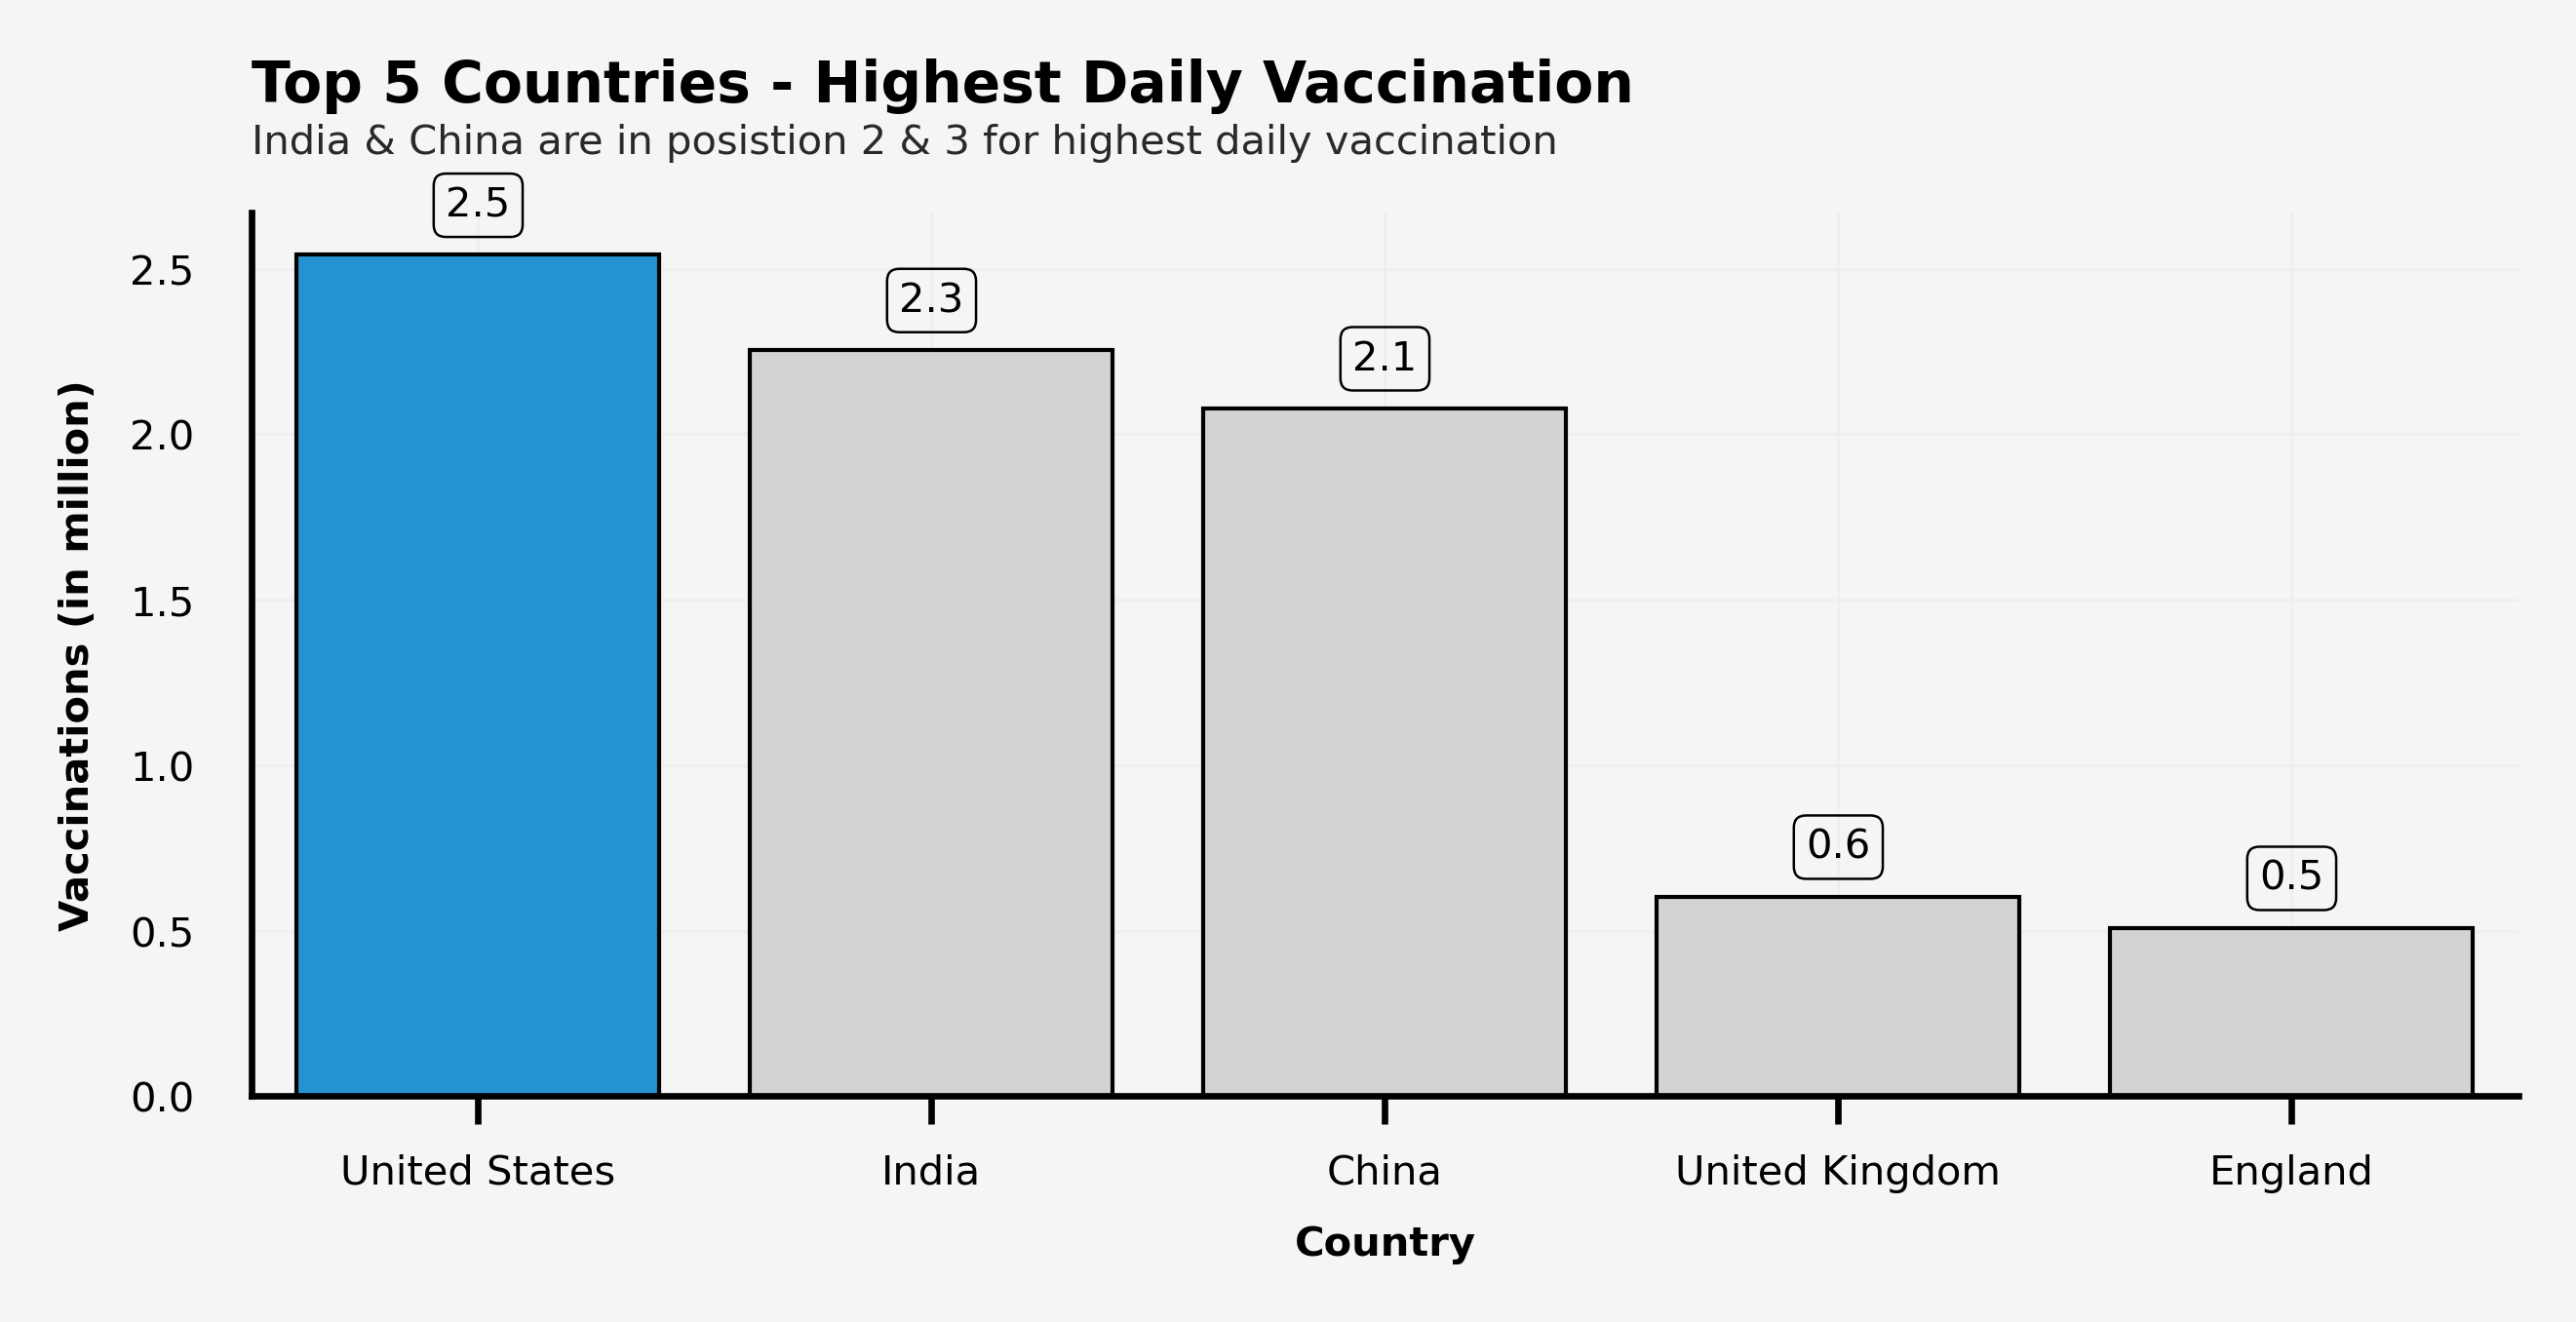

In [25]:
top5_countries_daily_vaccination = data.groupby('country')['daily_vaccinations'].max().sort_values(ascending=False)
top5_countries_daily_vaccination = top5_countries_daily_vaccination[:5]
top5_countries_daily_vaccination

background_color = "#f6f5f5"
color_map = ["lightgray" for _ in range(5)]
color_map[0] = "#2693d1"
sns.set_palette(sns.color_palette(color_map))

plt.rcParams['figure.dpi'] = 600
fig = plt.figure(figsize=(5, 2), facecolor='#f6f5f5')
gs = fig.add_gridspec(1, 1)
gs.update(wspace=0, hspace=0)
ax0 = fig.add_subplot(gs[0, 0])
ax0.set_facecolor(background_color)
for s in ["right", "top"]:
    ax0.spines[s].set_visible(False)
ax0.tick_params(axis = "y", which = "both", left = False)

ax0.text(-0.5, 2.97, 'Top 5 Countries - Highest Daily Vaccination', color='black', fontsize=7, ha='left', va='bottom', weight='bold')
ax0.text(-0.5, 2.94, 'India & China are in posistion 2 & 3 for highest daily vaccination', 
         color='#292929', fontsize=5, ha='left', va='top')
ax0_sns = sns.barplot(ax=ax0, x=top5_countries_daily_vaccination.index, y=top5_countries_daily_vaccination/1000000, 
                      zorder=2, linewidth=0.5, edgecolor='black', saturation=1)
ax0_sns.set_xlabel("Country",fontsize=5, weight='bold')
ax0_sns.set_ylabel("Vaccinations (in million)",fontsize=5, weight='bold')
ax0.grid(which='major', axis='x', zorder=0, color='#EEEEEE', lw=0.3)
ax0.grid(which='major', axis='y', zorder=0, color='#EEEEEE', lw=0.3)
ax0_sns.tick_params(labelsize=5)

for p in ax0.patches:
    value = f'{p.get_height():,.1f}'
    x = p.get_x() + p.get_width() / 2
    y = p.get_y() + p.get_height() + 0.15
    ax0.text(x, y, value, ha='center', va='center', fontsize=5, 
            bbox=dict(facecolor='none', edgecolor='black', boxstyle='round', linewidth=0.3))

plt.show()

Though `China` and `India` are 2 most populated countries in the world, their highest daily vaccination is still below `United States` and `China` highest daily vaccinations is below `India` considering `China's` population is higher than `India`. `United States` highest daily vaccination at `2.5 million` per day while `India` and `China` at `2.3 million` and `2.1 million`, respectively.

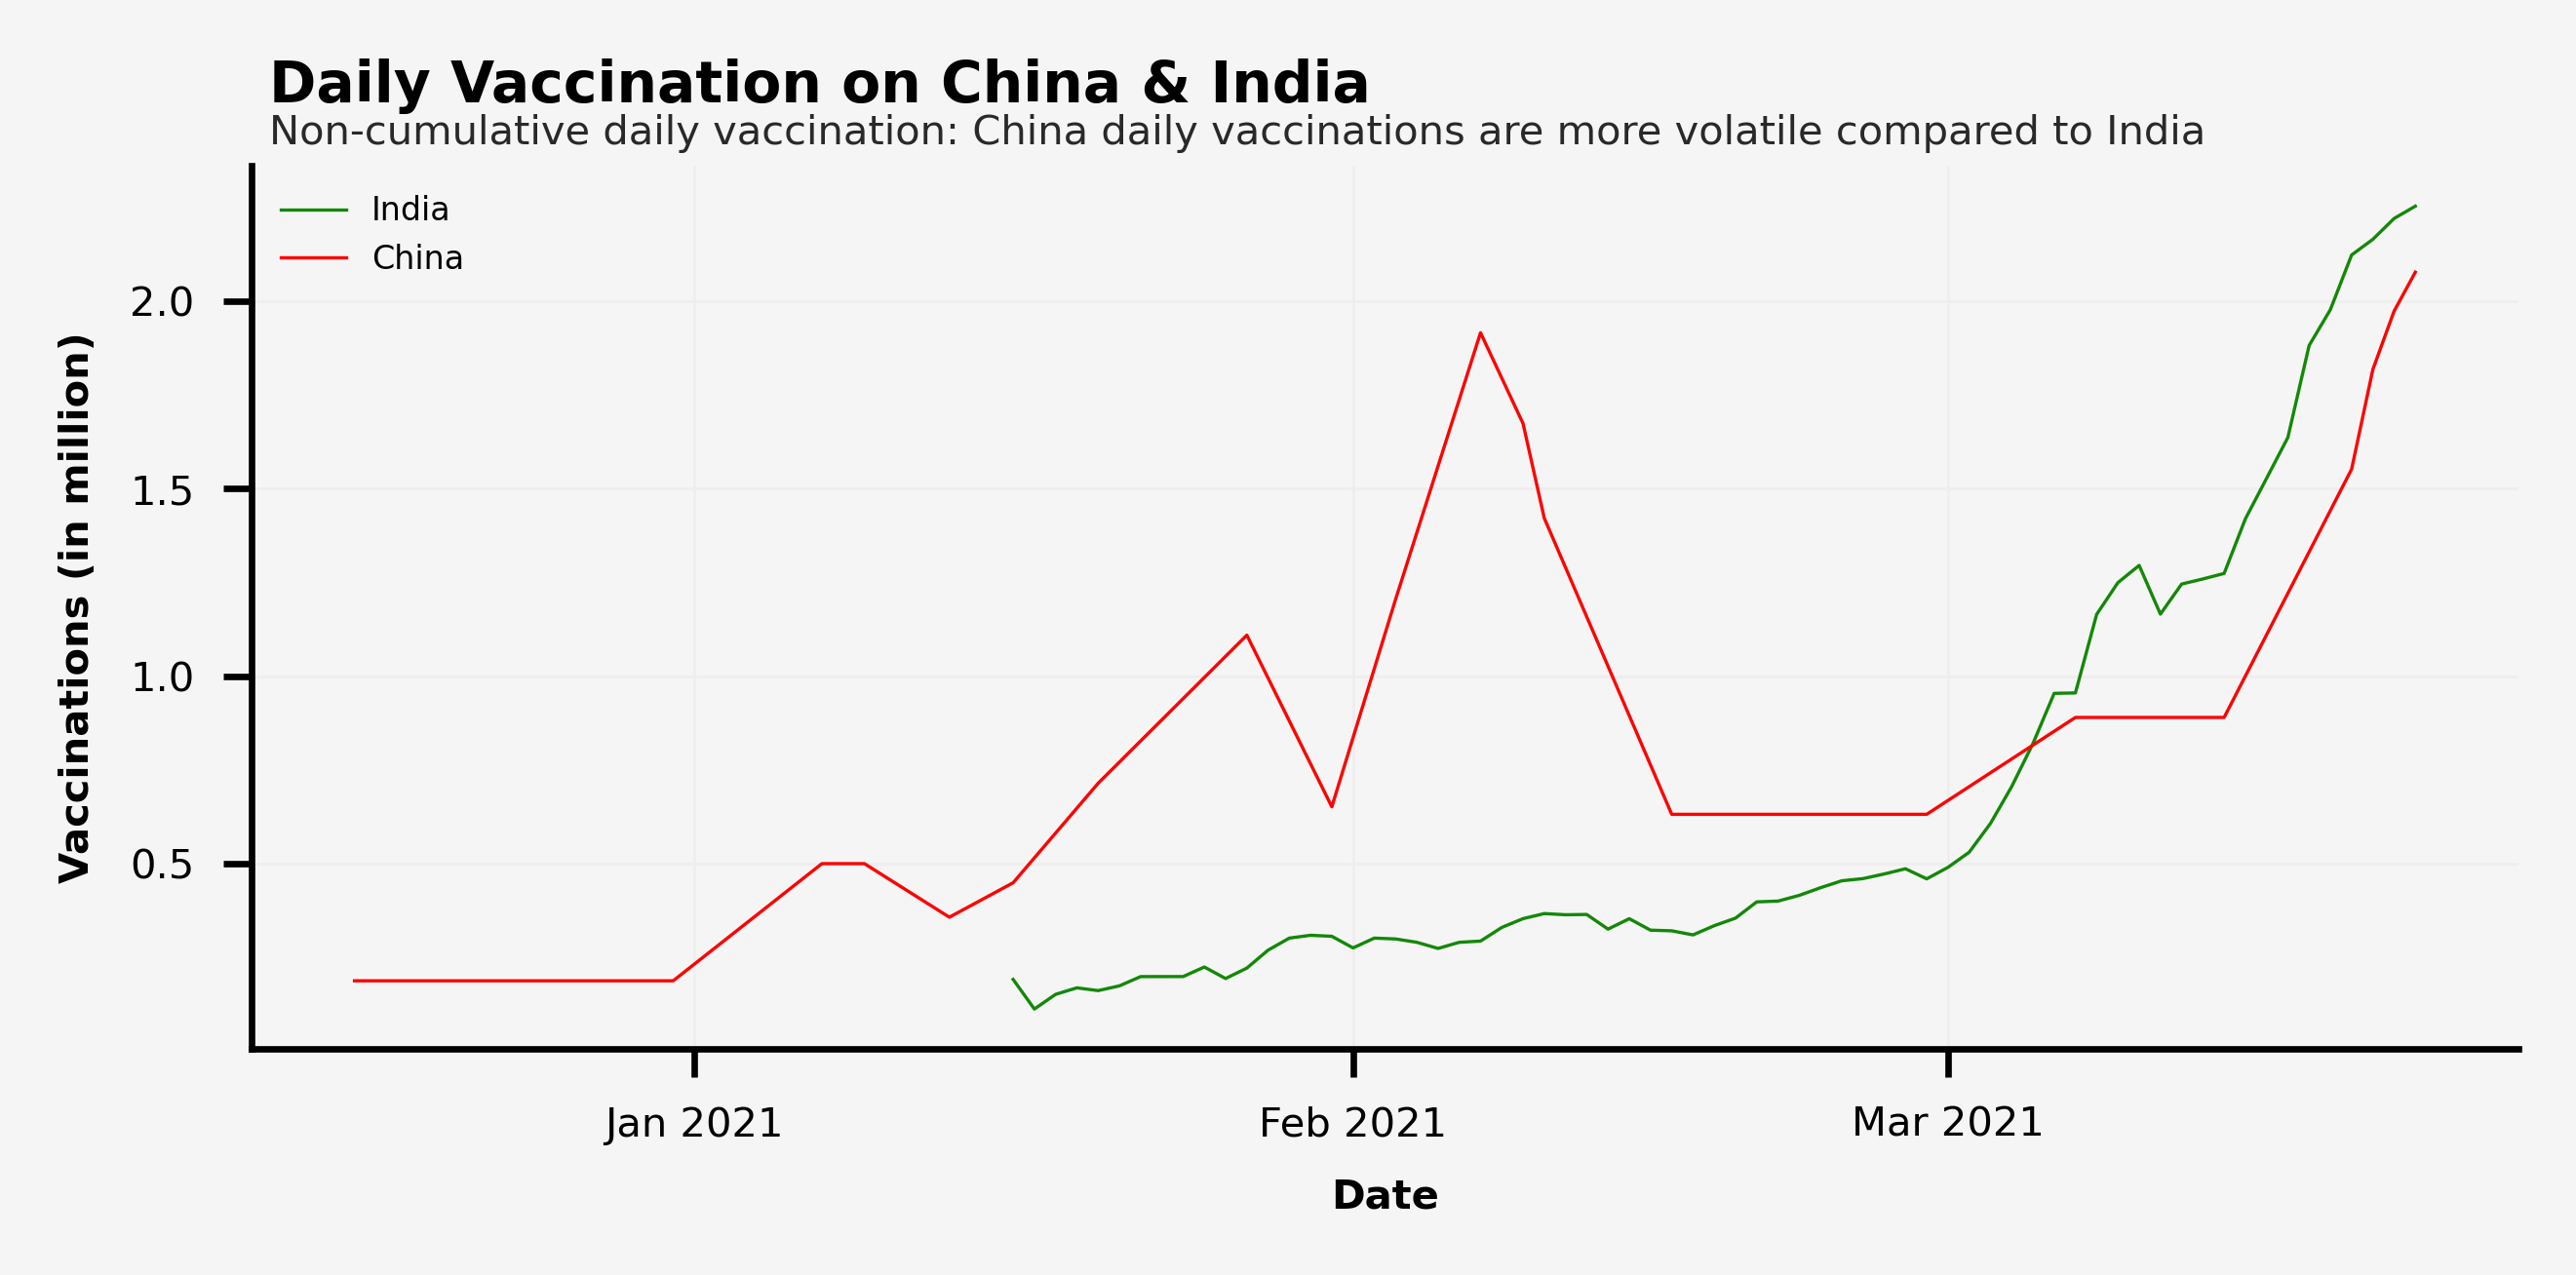

In [26]:
india = data[data['country']=='India']
china = data[data['country']=='China']

background_color = "#f6f5f5"

years = mdates.YearLocator()
months = mdates.MonthLocator()
years_fmt = mdates.DateFormatter('%b %Y')

plt.rcParams['figure.dpi'] = 600
fig = plt.figure(figsize=(5, 2), facecolor='#f6f5f5')
gs = fig.add_gridspec(1, 1)
gs.update(wspace=0, hspace=0)
ax0 = fig.add_subplot(gs[0, 0])
ax0.set_facecolor(background_color)
for s in ["right", "top"]:
    ax0.spines[s].set_visible(False)
    
# format the ticks
ax0.xaxis.set_major_locator(months)
ax0.xaxis.set_major_formatter(years_fmt)

ax0.text(pd.Timestamp('2020-12-12'), 2.5, 'Daily Vaccination on China & India', color='black', fontsize=7, ha='left', va='bottom', weight='bold')
ax0.text(pd.Timestamp('2020-12-12'), 2.5, 'Non-cumulative daily vaccination: China daily vaccinations are more volatile compared to India', 
         color='#292929', fontsize=5, ha='left', va='top')
ax0_sns = sns.lineplot(ax=ax0, x=india['date'], y=india['daily_vaccinations']/1000000, zorder=2, color='#138808', linewidth=0.4)
ax0_sns = sns.lineplot(ax=ax0, x=china['date'], y=china['daily_vaccinations']/1000000, zorder=2, color='#FF0000', linewidth=0.4)
ax0_sns.set_xlabel("Date",fontsize=5, weight='bold')
ax0_sns.set_ylabel("Vaccinations (in million)",fontsize=5, weight='bold')
ax0.grid(which='major', axis='x', zorder=0, color='#EEEEEE', lw=0.3)
ax0.grid(which='major', axis='y', zorder=0, color='#EEEEEE', lw=0.3)
ax0_sns.tick_params(labelsize=5)
ax0.legend(['India', 'China'], prop={'size': 4}, frameon=False)

plt.show()

`China` has started their vaccination prgoram earlier than `India`. In February 2021, `China` has passed `1.5 million` vaccinations/day before it drop below `1 million` in the same month until the end of February 2021. Contrary with `China`, `India` has a more consistent increment since the start of the vaccination program. Rapid increased in daily vaccinations can be seen in the start of March 2021 for `China` and `India`, both countries have above `2 million` daily vaccinations and is expected to continue rising up.

`China's` has a goal of getting 40% of the population inoculated by June 2021 which required a `10 million` vaccinations/day. To meet China's vaccination timeline, many regions have sought methods to increase the public's willingness to get jabs. Daxing, a district of Beijing, is offering supermarket coupons to those who get injected while Haidan, another area of the capital, is publicly listing the take-up rate at businesses and industrial areas in an effort to shame those lagging behind. Some  communities in East China's Hangzhou are arranging community workers paying door-to-door to encourage local residents to get vaccinated against COVID-19. They also hold sharing sessions to boost public willingness for the vaccines.

`China` has also shifted its focus, after inoculating members of high-risk groups last year, and is now targeting working people ages 18 to 59. The over-60s and those with underlying health conditions such as high blood pressure and diabetes will follow.

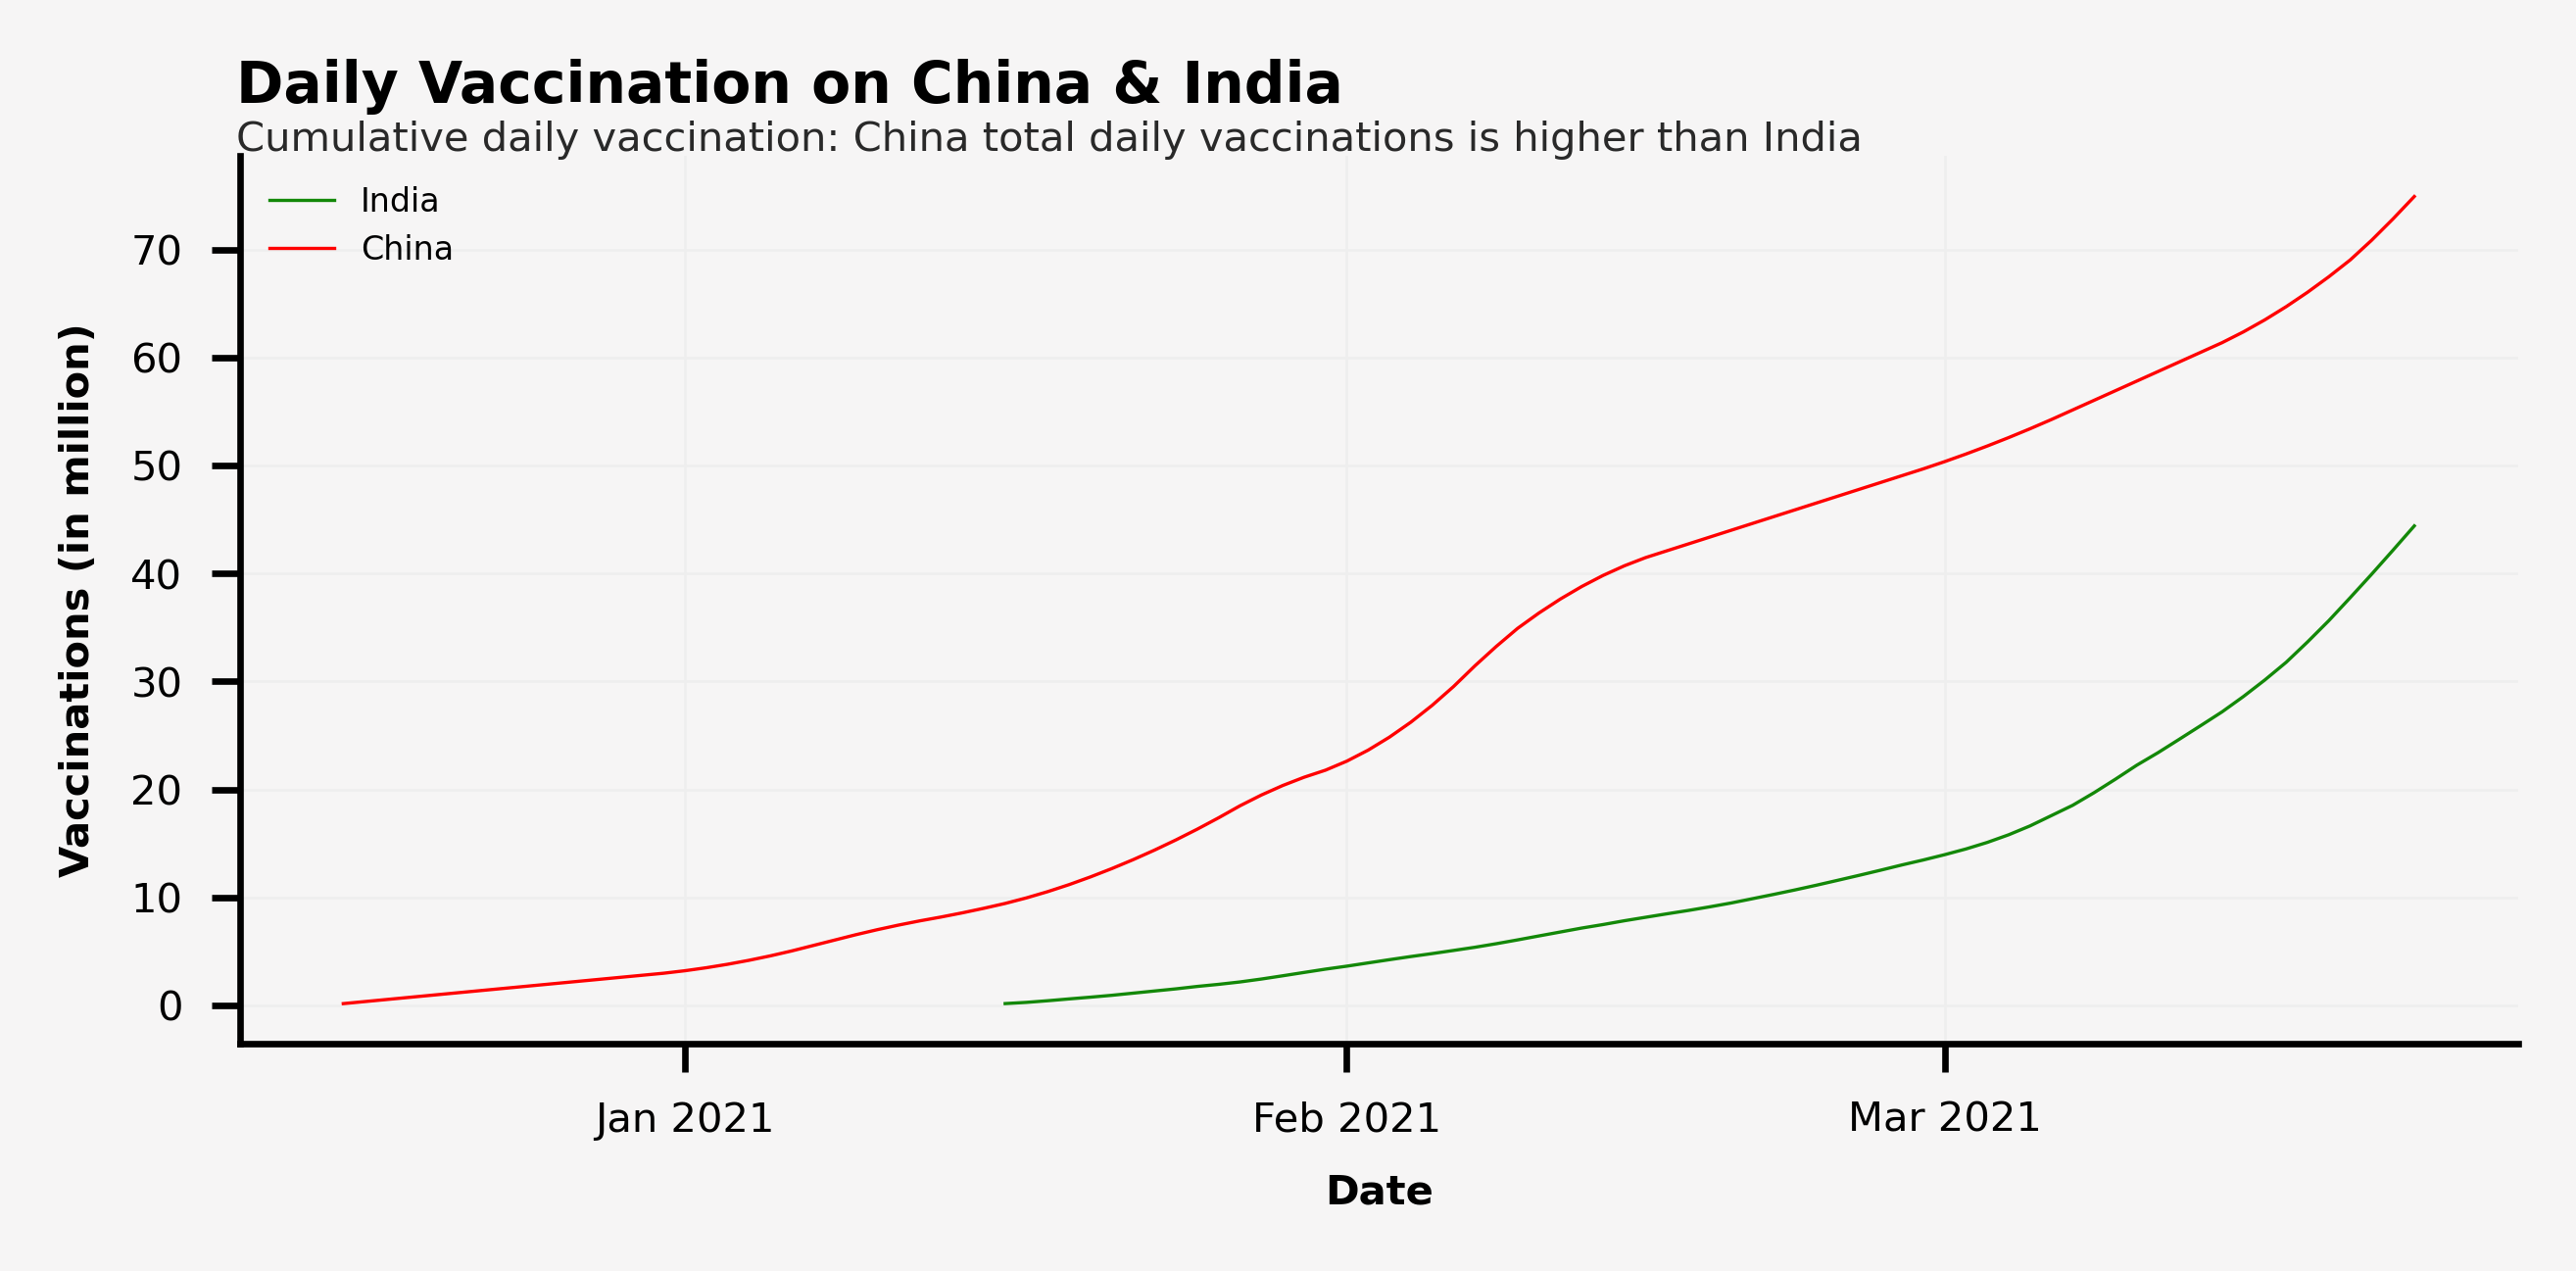

In [27]:
india = data[data['country']=='India']
china = data[data['country']=='China']

background_color = "#f6f5f5"

years = mdates.YearLocator()
months = mdates.MonthLocator()
years_fmt = mdates.DateFormatter('%b %Y')

plt.rcParams['figure.dpi'] = 600
fig = plt.figure(figsize=(5, 2), facecolor='#f6f5f5')
gs = fig.add_gridspec(1, 1)
gs.update(wspace=0, hspace=0)
ax0 = fig.add_subplot(gs[0, 0])
ax0.set_facecolor(background_color)
for s in ["right", "top"]:
    ax0.spines[s].set_visible(False)
    
# format the ticks
ax0.xaxis.set_major_locator(months)
ax0.xaxis.set_major_formatter(years_fmt)

ax0.text(pd.Timestamp('2020-12-11'), 82.5, 'Daily Vaccination on China & India', color='black', fontsize=7, ha='left', va='bottom', weight='bold')
ax0.text(pd.Timestamp('2020-12-11'), 82, 'Cumulative daily vaccination: China total daily vaccinations is higher than India', 
         color='#292929', fontsize=5, ha='left', va='top')
ax0_sns = sns.lineplot(ax=ax0, x=india['date'], y=india['daily_vaccinations'].cumsum()/1000000, zorder=2, color='#138808', linewidth=0.4)
ax0_sns = sns.lineplot(ax=ax0, x=china['date'], y=china['daily_vaccinations'].cumsum()/1000000, zorder=2, color='#FF0000', linewidth=0.4)
ax0_sns.set_xlabel("Date",fontsize=5, weight='bold')
ax0_sns.set_ylabel("Vaccinations (in million)",fontsize=5, weight='bold')
ax0.grid(which='major', axis='x', zorder=0, color='#EEEEEE', lw=0.3)
ax0.grid(which='major', axis='y', zorder=0, color='#EEEEEE', lw=0.3)
ax0_sns.tick_params(labelsize=5)
ax0.legend(['India', 'China'], prop={'size': 4}, frameon=False)

plt.show()

`China` is still leading the cumulative daily vaccination. It has started its vaccination program a month earlier than `India` which makes its cumulative daily vaccination higher than `China`. Starting in March, there is a high increased in `India` daily vaccination and is catching up with the `China` cumulative daily vaccination.

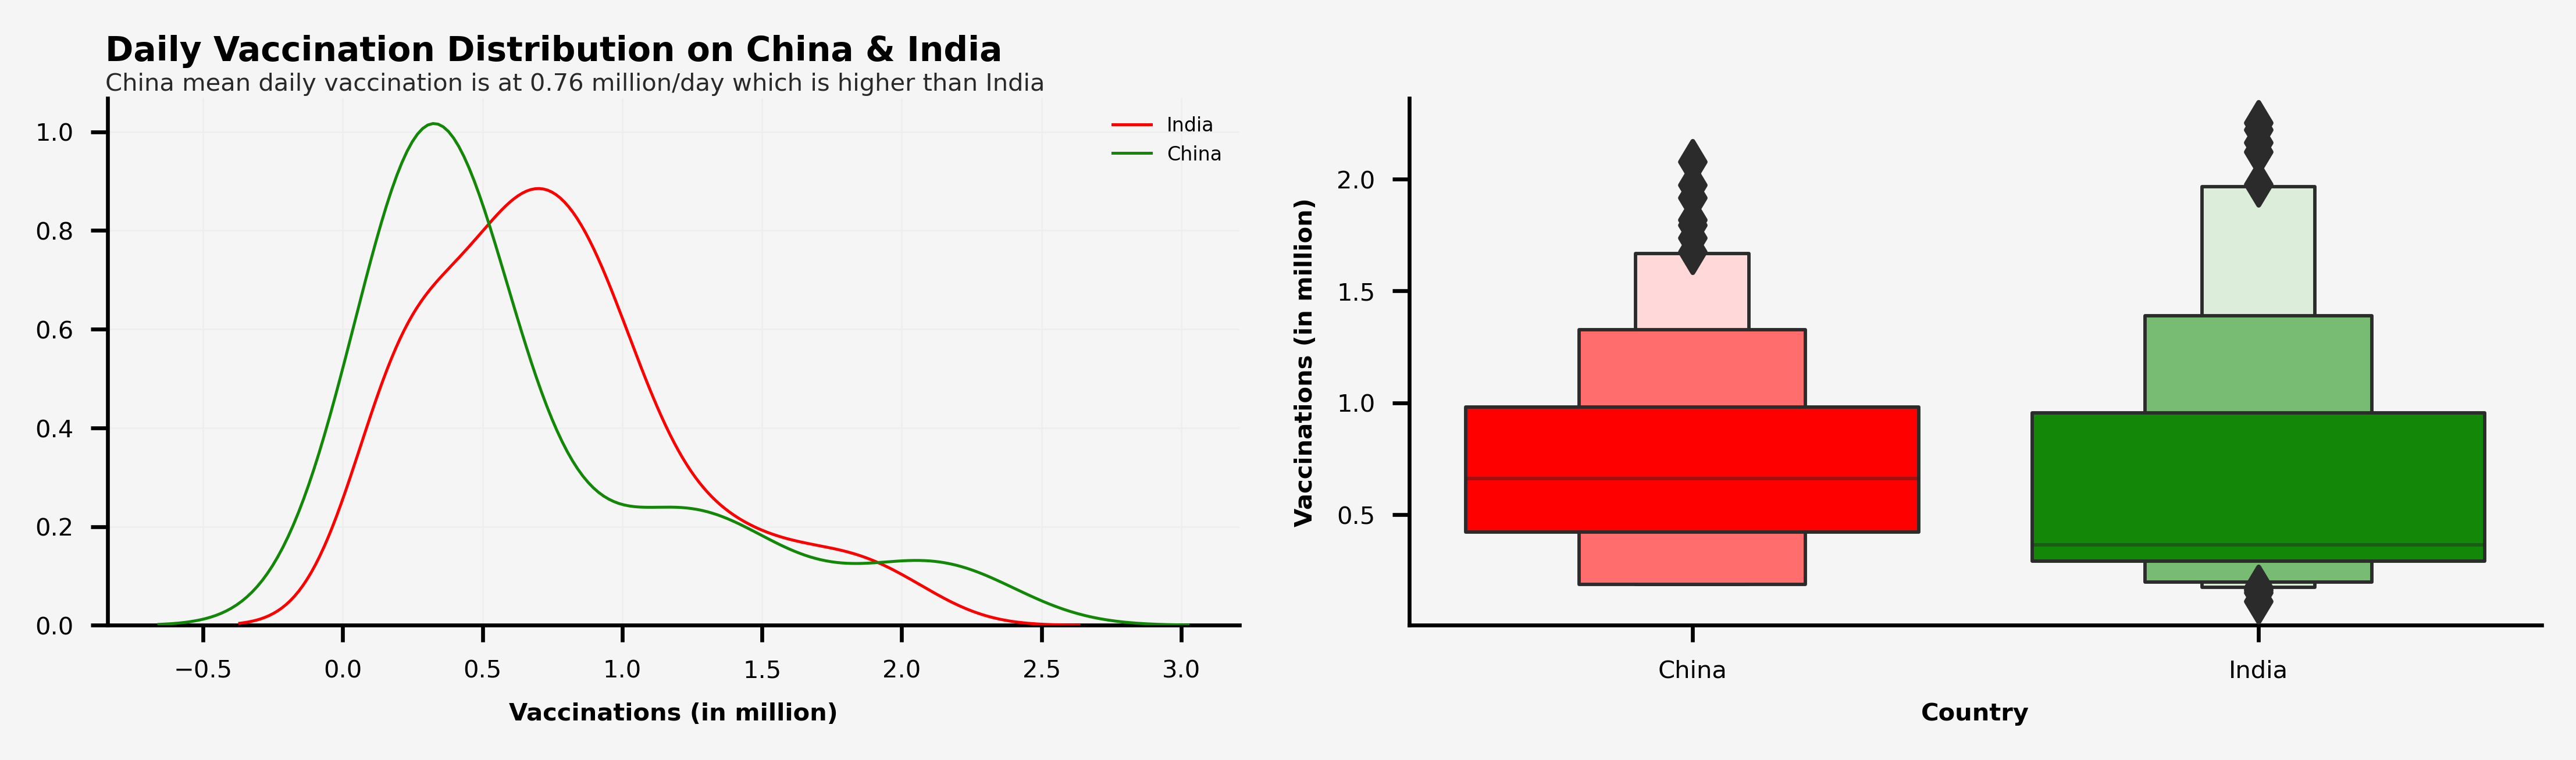

In [28]:
india = data[data['country']=='India']
china = data[data['country']=='China']
combine = pd.concat([china, india], axis=0)

background_color = "#f6f5f5"

color_map = ['#FF0000', '#138808']
sns.set_palette(sns.color_palette(color_map))

plt.rcParams['figure.dpi'] = 600
fig = plt.figure(figsize=(9, 2), facecolor='#f6f5f5')
gs = fig.add_gridspec(1, 2)
gs.update(wspace=0.15, hspace=0)
ax0 = fig.add_subplot(gs[0, 0])
ax0.set_facecolor(background_color)
for s in ["right", "top"]:
    ax0.spines[s].set_visible(False)

ax0.text(-0.85, 1.13, 'Daily Vaccination Distribution on China & India', color='black', fontsize=7, ha='left', va='bottom', weight='bold')
ax0.text(-0.85, 1.12, 'China mean daily vaccination is at 0.76 million/day which is higher than India', 
         color='#292929', fontsize=5, ha='left', va='top')
ax0_sns = sns.kdeplot(ax=ax0, x=china['daily_vaccinations']/1000000, zorder=3, linewidth=0.6)
ax0_sns = sns.kdeplot(ax=ax0, x=india['daily_vaccinations']/1000000, zorder=3, linewidth=0.6)
ax0_sns.set_xlabel("Vaccinations (in million)",fontsize=5, weight='bold')
ax0_sns.set_ylabel("")
ax0_sns.tick_params(labelsize=5)
ax0.grid(which='major', axis='x', zorder=0, color='#EEEEEE', lw=0.3)
ax0.grid(which='major', axis='y', zorder=0, color='#EEEEEE', lw=0.3)
ax0.legend(['India', 'China'], prop={'size': 4}, frameon=False)

india = data[data['country']=='India']
china = data[data['country']=='China']
combine = pd.concat([china, india], axis=0)

ax1 = fig.add_subplot(gs[0, 1])
ax1.set_facecolor(background_color)
for s in ["right", "top"]:
    ax1.spines[s].set_visible(False)
ax1_sns = sns.boxenplot(ax=ax1, x=combine['country'], y=combine['daily_vaccinations']/1000000, 
                        zorder=5, linewidth=0.7, saturation=1)
ax1_sns.set_xlabel("Country",fontsize=5, weight='bold')
ax1_sns.set_ylabel("Vaccinations (in million)",fontsize=5, weight='bold')
ax1_sns.tick_params(labelsize=5)
plt.show()

`China` and `India` have quite a same shape of distribution, though `China` has a higher frequency on higher daily vaccination. `China` has a higher daily vaccination mean compared to `India` with `0.76` million/day for `China` and `0.66` million/day for `India`. `China` daily vaccination median is `0.66` million/day which is also higher than `India` with `0.36` million/day.

[back to top](#table-of-contents)
<a id="ref"></a>
# References

Below are references for this notebook
* https://en.wikipedia.org/wiki/COVID-19
* https://en.wikipedia.org/wiki/Pfizer%E2%80%93BioNTech_COVID-19_vaccine
* https://en.wikipedia.org/wiki/Sputnik_V_COVID-19_vaccine
* https://en.wikipedia.org/wiki/Gibraltar
* https://www.worldometers.info/coronavirus/
* https://www.worldometers.info/world-population/population-by-country/
* https://www.who.int/health-topics/coronavirus#tab=tab_1
* https://www.cnbc.com/2021/03/16/europes-suspension-of-astrazenecas-covid-vaccine-is-damaging.html
* https://www.cnbc.com/2021/03/25/biden-will-announce-new-covid-vaccine-goal-200-million-shots-within-his-first-100-days.html
* https://www.bbc.com/news/world-asia-india-56345591
* https://www.dailysabah.com/turkey/turkey-surpasses-european-countries-in-covid-19-vaccinations/news
* https://www.politico.eu/article/vaccine-victory-within-gibraltars-reach/
* https://theconversation.com/vital-signs-israel-shows-how-to-do-vaccinations-right-its-a-race-and-were-behind-157242
* https://time.com/5947967/israel-covid-vaccine-rollout/
* https://www.scmp.com/news/china/science/article/3127166/coronavirus-china-piles-pressure-get-vaccinated-country-targets
* https://www.globaltimes.cn/page/202103/1219309.shtml